# Dataset 1

## Trainning

### Step 1: Import thư viện và đọc dữ liệu thô

In [23]:
# ============================================================
# Step 1: Import thư viện và đọc dữ liệu thô
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, precision_recall_curve, auc, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import joblib

try:
    import caas_jupyter_tools as cjt
    display_tables = True
except Exception:
    display_tables = False

### Step 2: EDA và xử lý outliers

In [24]:
# ============================================================
# Step 2: EDA và xử lý outliers
# ============================================================

DATA_DIR = Path("data")
DS1_PATH = DATA_DIR / "heart.csv"
DS2_PATH = DATA_DIR / "heart_failure_clinical_records_dataset.csv"
OUT_DIR = DATA_DIR / "output_figs"
MODEL_DIR = DATA_DIR / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df1 = pd.read_csv(DS1_PATH)
df2 = pd.read_csv(DS2_PATH)

print("Dataset1 shape:", df1.shape)
print("Dataset2 shape:", df2.shape)

def show_df(name, df):
    if display_tables:
        cjt.display_dataframe_to_user(name, df.head(10))
    else:
        print(f"Preview {name}:")
        print(df.head(3).to_string(index=False))

show_df("Dataset1_preview", df1)
show_df("Dataset2_preview", df2)

Dataset1 shape: (918, 12)
Dataset2 shape: (299, 13)
Preview Dataset1_preview:
 Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
  40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0
  49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1
  37   M           ATA        130          283          0         ST     98              N      0.0       Up             0
Preview Dataset2_preview:
 age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  smoking  time  DEATH_EVENT
75.0        0                       582         0                 20                    1  265000.00               1.9           130    1        0     4            1
55.0        0                      7861         0                 38    

Tổng quan dữ liệu Dataset 1:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000



Phân bố nhãn:


HeartDisease
1    508
0    410
Name: count, dtype: int64

HeartDisease
1    55.34
0    44.66
Name: proportion, dtype: float64

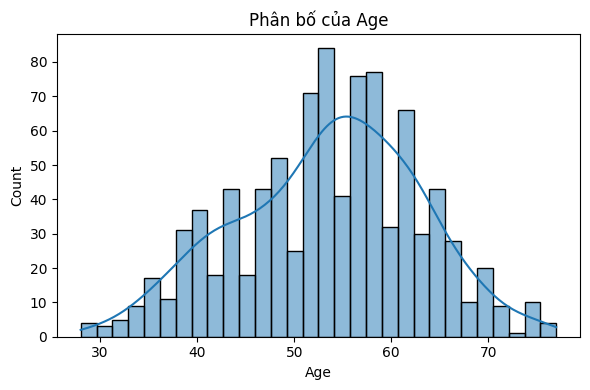

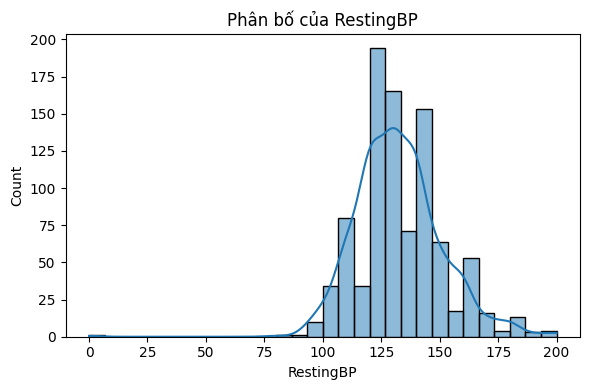

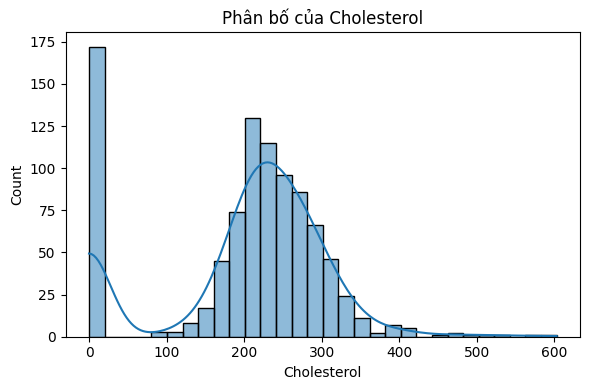

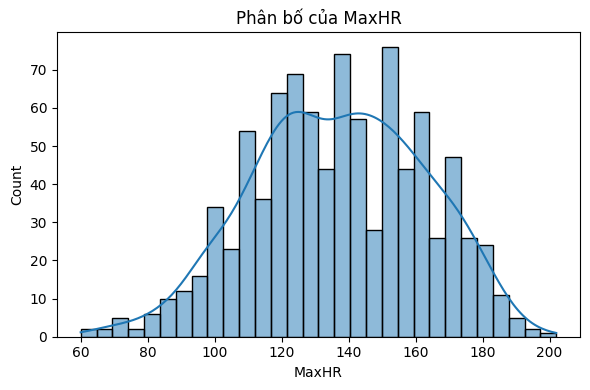

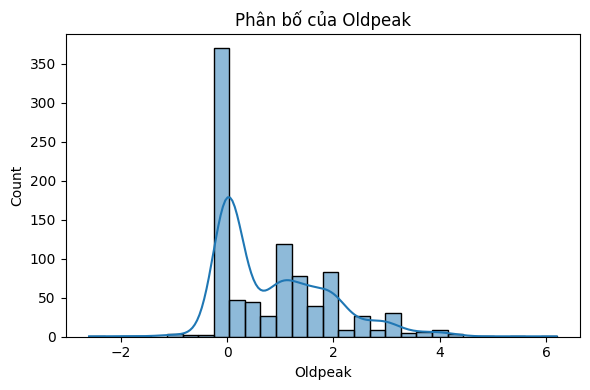

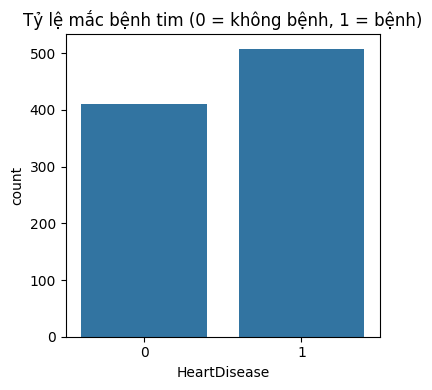

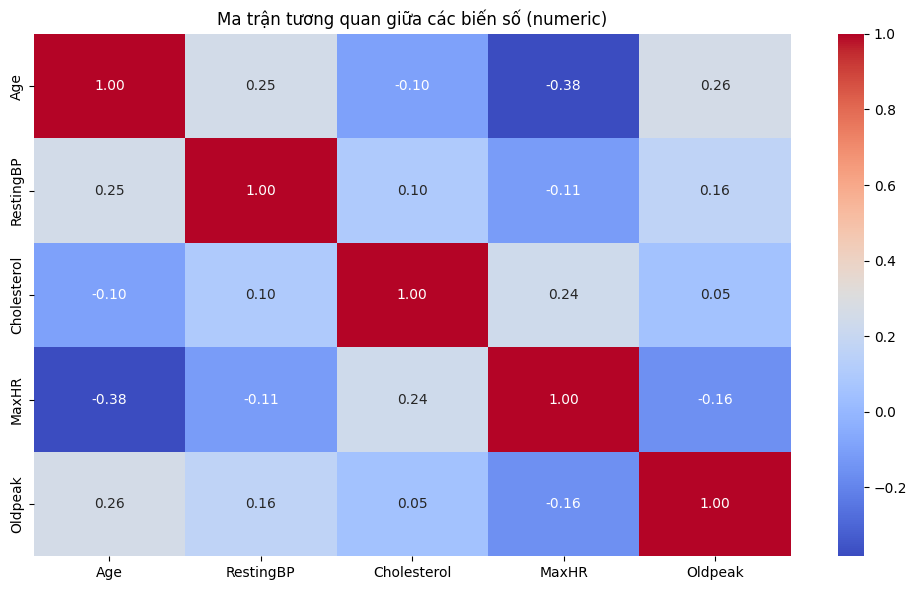

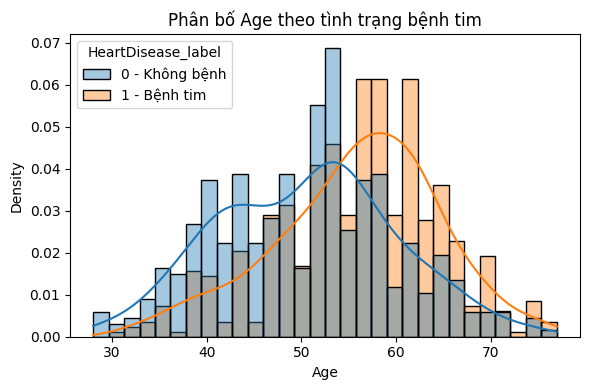

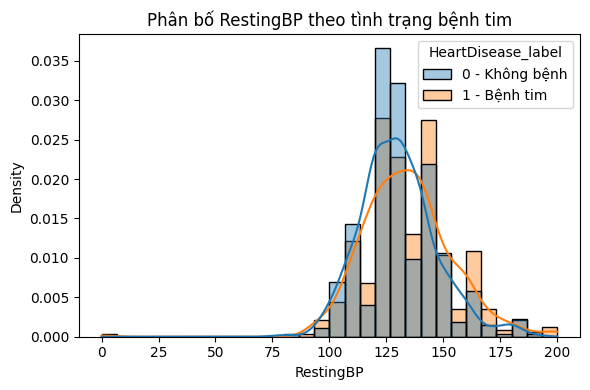

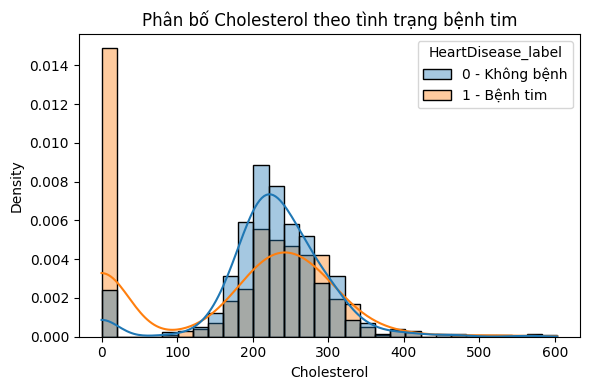

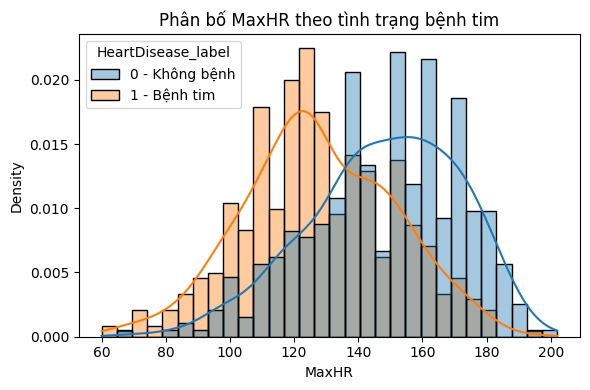

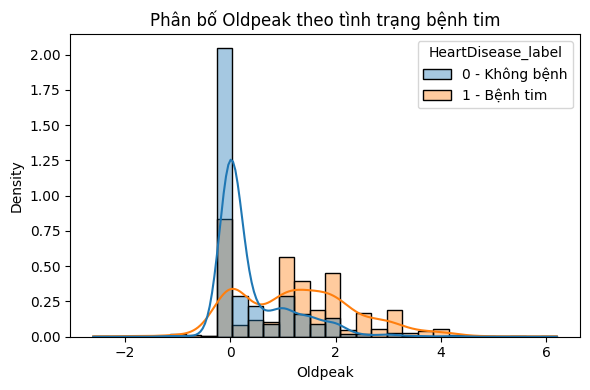

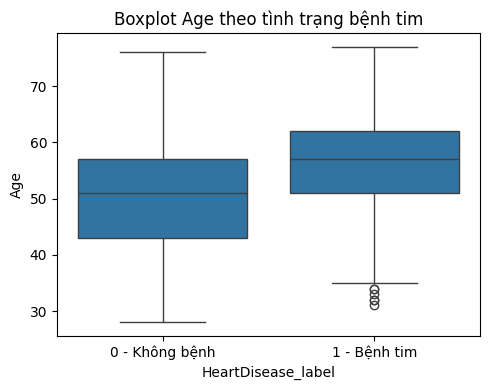

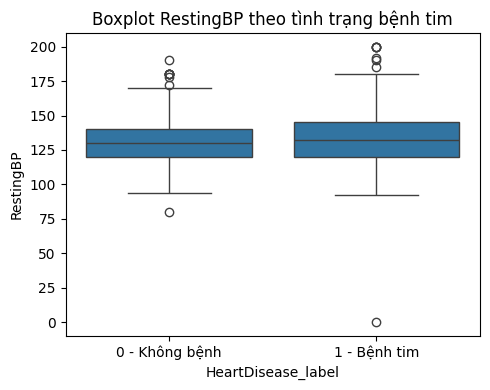

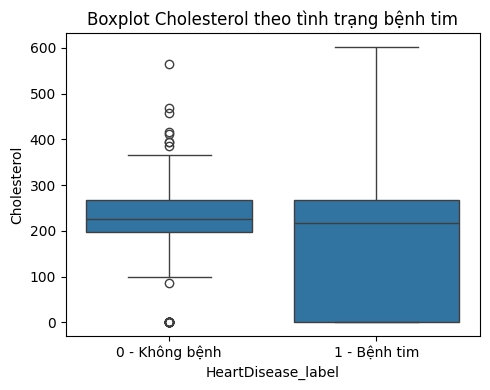

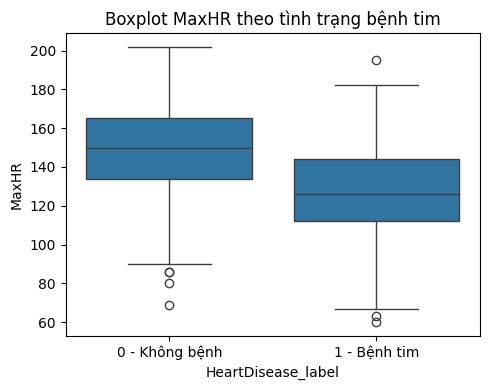

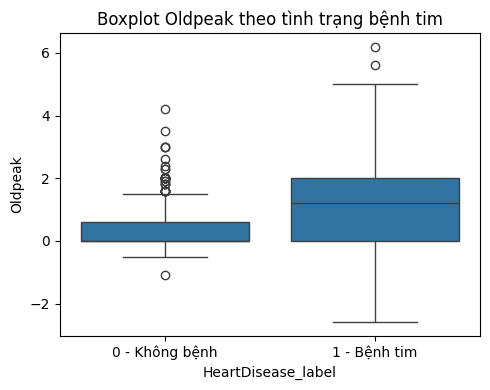

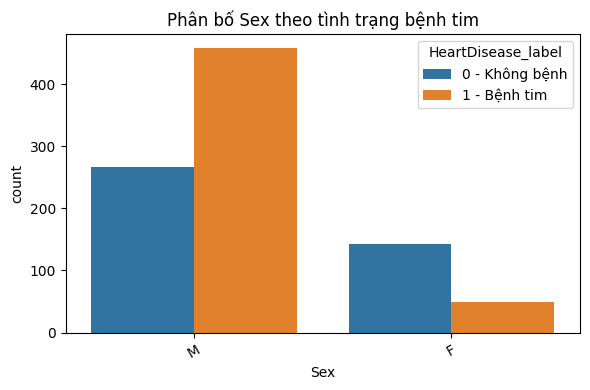

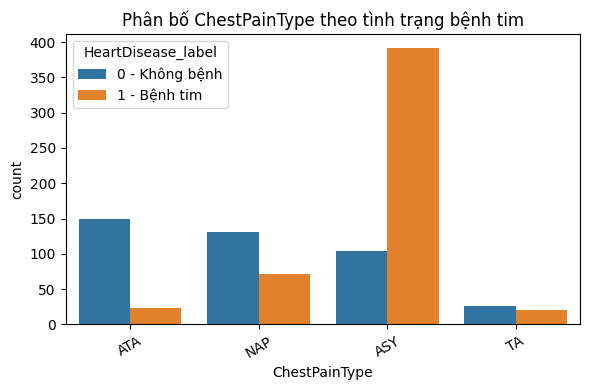

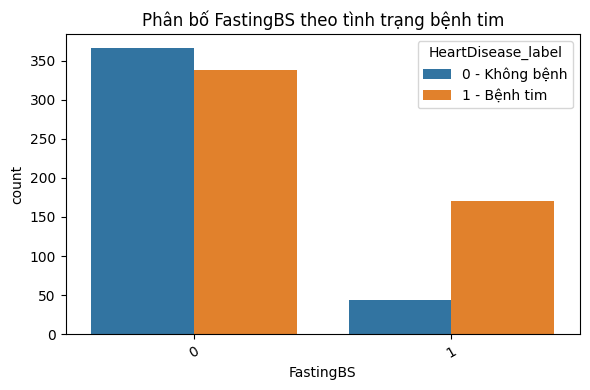

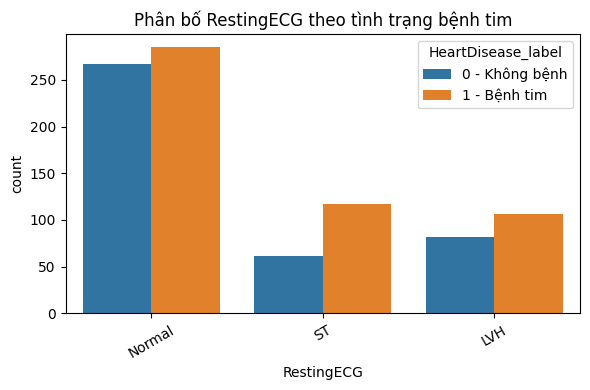

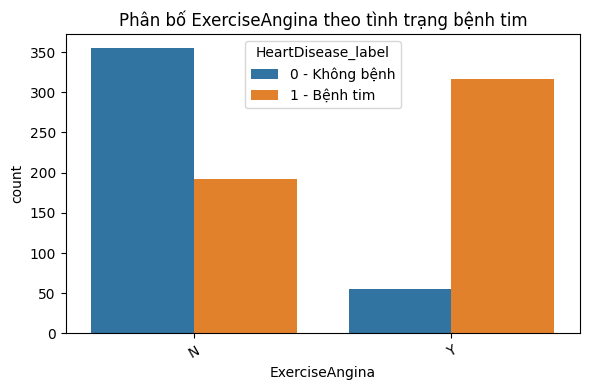

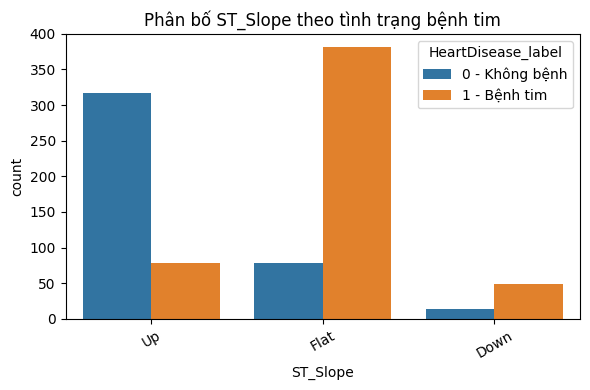


Tỉ lệ HeartDisease theo Sex:


,P(không bệnh),P(bệnh tim)
Sex,,
F,0.74,0.26
M,0.37,0.63



Tỉ lệ HeartDisease theo ChestPainType:


,P(không bệnh),P(bệnh tim)
ChestPainType,,
ASY,0.21,0.79
ATA,0.86,0.14
NAP,0.65,0.35
TA,0.57,0.43



Tỉ lệ HeartDisease theo FastingBS:


,P(không bệnh),P(bệnh tim)
FastingBS,,
0,0.52,0.48
1,0.21,0.79



Tỉ lệ HeartDisease theo RestingECG:


,P(không bệnh),P(bệnh tim)
RestingECG,,
LVH,0.44,0.56
Normal,0.48,0.52
ST,0.34,0.66



Tỉ lệ HeartDisease theo ExerciseAngina:


,P(không bệnh),P(bệnh tim)
ExerciseAngina,,
N,0.65,0.35
Y,0.15,0.85



Tỉ lệ HeartDisease theo ST_Slope:


,P(không bệnh),P(bệnh tim)
ST_Slope,,
Down,0.22,0.78
Flat,0.17,0.83
Up,0.80,0.20


In [6]:
# ============================================================
# STEP 1 (DS1): EDA (KHÔNG mutate dữ liệu train)
#   - Mục tiêu: hiểu phân bố, imbalance, mối liên hệ
#   - Không nên "clip outlier" vào df1 ở step này để đem đi train
# ============================================================


import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df1.copy()

print("Tổng quan dữ liệu Dataset 1:")
display(df_eda.head())
display(df_eda.describe(include="all"))

label1 = "HeartDisease" if "HeartDisease" in df_eda.columns else df_eda.columns[-1]
print("\nPhân bố nhãn:")
display(df_eda[label1].value_counts())
display(df_eda[label1].value_counts(normalize=True).mul(100).round(2))

# Các numeric chính (lọc theo tồn tại)
num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
num_features = [c for c in num_features if c in df_eda.columns]

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_eda[col], kde=True, bins=30)
    plt.title(f"Phân bố của {col}")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(4, 4))
sns.countplot(x=df_eda[label1])
plt.title("Tỷ lệ mắc bệnh tim (0 = không bệnh, 1 = bệnh)")
plt.xlabel(label1)
plt.tight_layout()
plt.show()

# Corr heatmap cho numeric
if len(num_features) >= 2:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_eda[num_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Ma trận tương quan giữa các biến số (numeric)")
    plt.tight_layout()
    plt.show()

# EDA theo nhãn (label dạng chữ)
df_eda["HeartDisease_label"] = df_eda[label1].map({0: "0 - Không bệnh", 1: "1 - Bệnh tim"})

# Histogram theo nhãn
for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df_eda,
        x=col,
        hue="HeartDisease_label",
        kde=True,
        bins=30,
        stat="density",
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Phân bố {col} theo tình trạng bệnh tim")
    plt.tight_layout()
    plt.show()

# Boxplot theo nhãn
for col in num_features:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df_eda, x="HeartDisease_label", y=col)
    plt.title(f"Boxplot {col} theo tình trạng bệnh tim")
    plt.tight_layout()
    plt.show()

# Categorical theo nhãn
categorical_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
categorical_cols = [c for c in categorical_cols if c in df_eda.columns]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_eda, x=col, hue="HeartDisease_label")
    plt.title(f"Phân bố {col} theo tình trạng bệnh tim")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

for col in categorical_cols:
    print(f"\nTỉ lệ HeartDisease theo {col}:")
    ct = pd.crosstab(df_eda[col], df_eda[label1], normalize="index").round(2)
    ct.columns = ["P(không bệnh)", "P(bệnh tim)"]
    display(ct)


### Step 3: Tiền xử lý & chia train/val/test cho Dataset 1 (Screening)

In [25]:
# ============================================================
# STEP 2 (DS1): Preprocess + Split train/val/test (CHUẨN, tránh leakage)
#   - Tách X/y
#   - Split stratify
#   - Preprocessor gồm:
#       + Numeric: Impute -> (Optional OutlierClipper) -> Scale
#       + Categorical: Impute -> OneHot
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ---------- 0) Chọn label ----------
label1 = "HeartDisease" if "HeartDisease" in df1.columns else df1.columns[-1]

# Drop các cột phụ EDA nếu có
drop_cols = [label1] + [c for c in df1.columns if c.endswith("_label")]
X1 = df1.drop(columns=drop_cols, errors="ignore").copy()
y1 = df1[label1].astype(int)

# ---------- 1) Split train/val/test ----------
X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1,
    test_size=0.30,
    stratify=y1,
    random_state=42
)

X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp,
    test_size=0.50,
    stratify=y1_temp,
    random_state=42
)

def show_split_info(name, y):
    y = np.asarray(y)
    print(f"{name}: n={len(y)} | pos_rate={y.mean():.3f}")

print("Phân bố nhãn theo split:")
show_split_info("TRAIN", y1_train)
show_split_info("VAL  ", y1_val)
show_split_info("TEST ", y1_test)

# ---------- 2) Chọn numeric/cat columns (từ TRAIN để ổn định) ----------
numeric_cols1 = X1_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols1 = [c for c in X1_train.columns if c not in numeric_cols1]

print(f"\nSố feature numeric: {len(numeric_cols1)}")
print(f"Số feature categorical: {len(cat_cols1)}")

# ---------- 3) (Optional) OutlierClipper theo IQR: FIT trên TRAIN ----------
class IQRClipper(BaseEstimator, TransformerMixin):
    """
    Clip outliers theo IQR (fit trên TRAIN, transform trên VAL/TEST).
    Dùng cho numeric features.
    """
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_ = None
        self.upper_ = None

    def fit(self, X, y=None):
        X = np.asarray(X)
        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.clip(X, self.lower_, self.upper_)

USE_OUTLIER_CLIP = True  # nếu muốn bật clipping (khuyến nghị nếu bạn đã EDA thấy outlier mạnh)

numeric_steps = [
    ("imputer", SimpleImputer(strategy="median")),
]
if USE_OUTLIER_CLIP:
    numeric_steps.append(("clipper", IQRClipper(factor=1.5)))
numeric_steps.append(("scaler", StandardScaler()))

numeric_transformer = Pipeline(steps=numeric_steps)

# OneHotEncoder tương thích version sklearn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocessor1 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols1),
        ("cat", categorical_transformer, cat_cols1),
    ],
    remainder="drop"
)

print(f"\n[OK] Build preprocessor1 xong. USE_OUTLIER_CLIP={USE_OUTLIER_CLIP}")


Phân bố nhãn theo split:
TRAIN: n=642 | pos_rate=0.553
VAL  : n=138 | pos_rate=0.558
TEST : n=138 | pos_rate=0.551

Số feature numeric: 6
Số feature categorical: 5

[OK] Build preprocessor1 xong. USE_OUTLIER_CLIP=True


### Step 4: Huấn luyện & đánh giá mô hình Screening 

In [26]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# ============================================================
# Step 4: Huấn luyện & so sánh mô hình Screening DS1
#   - LogisticRegression, RandomForest, CatBoost, XGBoost
#   - So sánh bằng AUC-CV mean ± std (5-fold Stratified CV)
#   - RF/CatBoost/XGB: GridSearchCV trên TRAIN
#   - Tính lại CV mean±std cho best estimator để so sánh công bằng
#   - Chọn mô hình có AUC-CV mean cao nhất, rồi fit trên TRAIN
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

from catboost import CatBoostClassifier

# XGBoost
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1) Chuẩn bị: gộp train + val để dùng sau (train+val) khi finalize model
# ------------------------------------------------------------
X1_train_full = pd.concat([X1_train, X1_val], axis=0)
y1_train_full = pd.concat([y1_train, y1_val], axis=0)

cv_ds1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------
# 2) Logistic Regression – CV AUC mean±std trên TRAIN
# ------------------------------------------------------------
pipe_lr1 = Pipeline([
    ("pre", preprocessor1),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_scores = cross_val_score(pipe_lr1, X1_train, y1_train, cv=cv_ds1, scoring="roc_auc", n_jobs=-1)
lr_auc_mean, lr_auc_std = lr_scores.mean(), lr_scores.std()

print(f">>> LogisticRegression – DS1 – CV AUC (mean ± std): {lr_auc_mean:.4f} ± {lr_auc_std:.4f}")

# ------------------------------------------------------------
# 3) RandomForest – GridSearchCV trên TRAIN (tối ưu AUC)
# ------------------------------------------------------------
pipe_rf1_base = Pipeline([
    ("pre", preprocessor1),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_rf1 = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.8],
}

grid_rf1 = GridSearchCV(
    estimator=pipe_rf1_base,
    param_grid=param_grid_rf1,
    cv=cv_ds1,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1
)

print(">>> Bắt đầu GridSearchCV cho RandomForest – DS1 (chỉ TRAIN)...")
grid_rf1.fit(X1_train, y1_train)

best_pipe_rf1 = grid_rf1.best_estimator_
print(">>> Best params RF – DS1:", grid_rf1.best_params_)
print(">>> Best CV AUC (GridSearch mean) – RF – DS1:", grid_rf1.best_score_)

rf_scores = cross_val_score(best_pipe_rf1, X1_train, y1_train, cv=cv_ds1, scoring="roc_auc", n_jobs=-1)
rf_auc_mean, rf_auc_std = rf_scores.mean(), rf_scores.std()
print(f">>> RandomForest (best) – DS1 – CV AUC (mean ± std): {rf_auc_mean:.4f} ± {rf_auc_std:.4f}")

# ------------------------------------------------------------
# 4) CatBoost – GridSearchCV trên TRAIN (tối ưu AUC)
# ------------------------------------------------------------
pos_ratio = float(y1_train.mean())
if 0 < pos_ratio < 1:
    class_weights = [1.0, (1.0 - pos_ratio) / pos_ratio]
else:
    class_weights = [1.0, 1.0]

pipe_cat1_base = Pipeline([
    ("pre", preprocessor1),
    ("clf", CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=class_weights,
        random_seed=42,
        verbose=0
    ))
])

param_grid_cat1 = {
    "clf__depth": [4, 6],
    "clf__learning_rate": [0.03, 0.1],
    "clf__iterations": [300, 500],
}

grid_cat1 = GridSearchCV(
    estimator=pipe_cat1_base,
    param_grid=param_grid_cat1,
    cv=cv_ds1,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1
)

print(">>> Bắt đầu GridSearchCV cho CatBoost – DS1 (chỉ TRAIN)...")
grid_cat1.fit(X1_train, y1_train)

best_pipe_cat1 = grid_cat1.best_estimator_
print(">>> Best params CatBoost – DS1:", grid_cat1.best_params_)
print(">>> Best CV AUC (GridSearch mean) – CatBoost – DS1:", grid_cat1.best_score_)

cat_scores = cross_val_score(best_pipe_cat1, X1_train, y1_train, cv=cv_ds1, scoring="roc_auc", n_jobs=-1)
cat_auc_mean, cat_auc_std = cat_scores.mean(), cat_scores.std()
print(f">>> CatBoost (best) – DS1 – CV AUC (mean ± std): {cat_auc_mean:.4f} ± {cat_auc_std:.4f}")

# ------------------------------------------------------------
# 5) XGBoost – GridSearchCV trên TRAIN (tối ưu AUC)
# ------------------------------------------------------------
pos = float(y1_train.sum())
neg = float(len(y1_train) - pos)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

pipe_xgb1_base = Pipeline([
    ("pre", preprocessor1),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        # các giá trị default sẽ được override bởi GridSearch
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=1.0,
        reg_alpha=0.0
    ))
])

param_grid_xgb1 = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.03, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

grid_xgb1 = GridSearchCV(
    estimator=pipe_xgb1_base,
    param_grid=param_grid_xgb1,
    cv=cv_ds1,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1
)

print(">>> Bắt đầu GridSearchCV cho XGBoost – DS1 (chỉ TRAIN)...")
grid_xgb1.fit(X1_train, y1_train)

best_pipe_xgb1 = grid_xgb1.best_estimator_
print(">>> Best params XGBoost – DS1:", grid_xgb1.best_params_)
print(">>> Best CV AUC (GridSearch mean) – XGBoost – DS1:", grid_xgb1.best_score_)

xgb_scores = cross_val_score(best_pipe_xgb1, X1_train, y1_train, cv=cv_ds1, scoring="roc_auc", n_jobs=-1)
xgb_auc_mean, xgb_auc_std = xgb_scores.mean(), xgb_scores.std()
print(f">>> XGBoost (best) – DS1 – CV AUC (mean ± std): {xgb_auc_mean:.4f} ± {xgb_auc_std:.4f}")

# ------------------------------------------------------------
# 6) Tổng hợp so sánh (bảng + chênh lệch) và chọn mô hình tốt nhất
# ------------------------------------------------------------
summary_ds1 = pd.DataFrame([
    {"Model": "RandomForest",       "CV_AUC_mean": rf_auc_mean,  "CV_AUC_std": rf_auc_std,  "BestParams": grid_rf1.best_params_},
    {"Model": "CatBoost",           "CV_AUC_mean": cat_auc_mean, "CV_AUC_std": cat_auc_std, "BestParams": grid_cat1.best_params_},
    {"Model": "XGBoost",            "CV_AUC_mean": xgb_auc_mean, "CV_AUC_std": xgb_auc_std, "BestParams": grid_xgb1.best_params_},
    {"Model": "LogisticRegression", "CV_AUC_mean": lr_auc_mean,  "CV_AUC_std": lr_auc_std,  "BestParams": "-"},
]).sort_values("CV_AUC_mean", ascending=False).reset_index(drop=True)

best_model_label_ds1 = summary_ds1.loc[0, "Model"]
summary_ds1["Selected"] = summary_ds1["Model"].eq(best_model_label_ds1)

print("\n>>> BẢNG TỔNG HỢP SO SÁNH (DS1 – CV AUC mean ± std):")
display(summary_ds1)

top_auc = float(summary_ds1.loc[0, "CV_AUC_mean"])
print(">>> CHÊNH LỆCH AUC so với mô hình tốt nhất:")
for i in range(1, len(summary_ds1)):
    m = summary_ds1.loc[i, "Model"]
    auc_i = float(summary_ds1.loc[i, "CV_AUC_mean"])
    print(f"- {best_model_label_ds1} minus {m}: {top_auc - auc_i:.4f}")

# Chọn pipeline tương ứng
if best_model_label_ds1 == "LogisticRegression":
    best_pipe_ds1 = pipe_lr1
elif best_model_label_ds1 == "RandomForest":
    best_pipe_ds1 = best_pipe_rf1
elif best_model_label_ds1 == "CatBoost":
    best_pipe_ds1 = best_pipe_cat1
else:
    best_pipe_ds1 = best_pipe_xgb1

print(f"\n>>> Mô hình được chọn cho DS1: {best_model_label_ds1}")

# ------------------------------------------------------------
# 7) Fit mô hình đã chọn trên TRAIN (để tune threshold ở Step 5)
# ------------------------------------------------------------
best_pipe_ds1.fit(X1_train, y1_train)
print(">>> Đã fit mô hình đã chọn cho DS1 trên TRAIN (chuẩn bị tune threshold).")


>>> LogisticRegression – DS1 – CV AUC (mean ± std): 0.9156 ± 0.0244
>>> Bắt đầu GridSearchCV cho RandomForest – DS1 (chỉ TRAIN)...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
>>> Best params RF – DS1: {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
>>> Best CV AUC (GridSearch mean) – RF – DS1: 0.9229382343668788
>>> RandomForest (best) – DS1 – CV AUC (mean ± std): 0.9229 ± 0.0221
>>> Bắt đầu GridSearchCV cho CatBoost – DS1 (chỉ TRAIN)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
>>> Best params CatBoost – DS1: {'clf__depth': 6, 'clf__iterations': 300, 'clf__learning_rate': 0.03}
>>> Best CV AUC (GridSearch mean) – CatBoost – DS1: 0.9177398328263593
>>> CatBoost (best) – DS1 – CV AUC (mean ± std): 0.9177 ± 0.0227
>>> Bắt đầu GridSearchCV cho XGBoost – DS1 (chỉ TRAIN)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
>>> Best params XGBoost – DS1: {'c

,Model,CV_AUC_mean,CV_AUC_std,BestParams,Selected
0,RandomForest,0.922938,0.022121,"{'clf__max_depth': 5, 'clf__max_features': 'sq...",True
1,CatBoost,0.917740,0.022739,"{'clf__depth': 6, 'clf__iterations': 300, 'clf...",False
2,LogisticRegression,0.915570,0.024401,-,False
3,XGBoost,0.915228,0.025588,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",False


>>> CHÊNH LỆCH AUC so với mô hình tốt nhất:
- RandomForest minus CatBoost: 0.0052
- RandomForest minus LogisticRegression: 0.0074
- RandomForest minus XGBoost: 0.0077

>>> Mô hình được chọn cho DS1: RandomForest
>>> Đã fit mô hình đã chọn cho DS1 trên TRAIN (chuẩn bị tune threshold).


### Step 5: Chọn threshold + đánh giá test

In [28]:
# ============================================================
# Step 5 (DS1): Tune threshold trên VALIDATION + đánh giá TEST + lưu model (TRAIN+VAL)
#   - Mục tiêu: tối ưu Recall với ràng buộc Precision >= 0.5
#   - Đánh giá TEST ở 2 ngưỡng: 0.5 (baseline) và best_th (tuned)
#   - An toàn: confusion_matrix luôn 2x2, cảnh báo nếu không có ngưỡng thỏa constraint
# ============================================================

from sklearn.base import clone


def evaluate_at_threshold(y_true, y_proba, threshold=0.5, name="model@th"):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_acc = (rec + specificity) / 2
    auc_roc = roc_auc_score(y_true, y_proba)  # AUC tính trên proba, không phụ thuộc threshold

    print(f"=== {name} (threshold={threshold:.3f}) ===")
    print(f"Accuracy            : {acc:.4f}")
    print(f"Precision           : {prec:.4f}")
    print(f"Recall (Sensitivity): {rec:.4f}")
    print(f"Specificity         : {specificity:.4f}")
    print(f"Balanced Accuracy   : {balanced_acc:.4f}")
    print(f"F1-score            : {f1:.4f}")
    print(f"AUC-ROC (proba)     : {auc_roc:.4f}")
    print("-" * 60)

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "specificity": float(specificity),
        "balanced_accuracy": float(balanced_acc),
        "f1": float(f1),
        "auc_roc": float(auc_roc),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# ------------------------------------------------------------
# Helper: tune threshold trên VALIDATION
# ------------------------------------------------------------
def tune_threshold_on_validation(
    y_true,
    y_proba,
    metric="recall",          # "recall" | "precision" | "f1"
    min_recall=None,          # constraint cho metric precision/f1
    min_precision=None,       # constraint cho metric recall
    thresholds=None
):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    rows = []
    best_th = 0.5
    best_score = -1

    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)

        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)

        # Constraints
        if metric == "recall" and min_precision is not None and prec < min_precision:
            continue
        if metric in ("precision", "f1") and min_recall is not None and rec < min_recall:
            continue

        # Score used for selection
        if metric == "recall":
            score = rec
        elif metric == "precision":
            score = prec
        else:
            score = f1

        rows.append({
            "threshold": float(th),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "score_used": float(score),
        })

        if score > best_score:
            best_score = score
            best_th = float(th)

    table = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)
    return best_th, table

# ------------------------------------------------------------
# DS1: tune threshold trên VAL
# ------------------------------------------------------------
y1_val_proba = best_pipe_ds1.predict_proba(X1_val)[:, 1]

best_th_ds1, table_th_ds1 = tune_threshold_on_validation(
    y_true=y1_val,
    y_proba=y1_val_proba,
    metric="recall",
    min_precision=0.5
)

print("Best threshold DS1:", best_th_ds1)

if table_th_ds1.empty:
    print("[WARNING] Không có threshold nào thỏa min_precision=0.5. best_th_ds1 đang là 0.5 mặc định.")
else:
    display(table_th_ds1.head(10))

# Tính lại precision/recall/f1 trên VAL tại best_th (để log rõ ràng)
y1_val_pred_best = (y1_val_proba >= best_th_ds1).astype(int)
prec_best = precision_score(y1_val, y1_val_pred_best, zero_division=0)
rec_best  = recall_score(y1_val, y1_val_pred_best, zero_division=0)
f1_best   = f1_score(y1_val, y1_val_pred_best, zero_division=0)

th_info_ds1 = {
    "optimized_metric": "recall",
    "min_recall_constraint": None,
    "min_precision_constraint": 0.5,
    "best_threshold": float(best_th_ds1),
    "recall_at_best_th": float(rec_best),
    "precision_at_best_th": float(prec_best),
    "f1_at_best_th": float(f1_best),
}

print("\n>>> Threshold tuning trên VALIDATION (DS1)")
print(f"- Optimized metric        : {th_info_ds1['optimized_metric']}")
print(f"- Min recall constraint   : {th_info_ds1['min_recall_constraint']}")
print(f"- Min precision constraint: {th_info_ds1['min_precision_constraint']}")
print(f"- Best threshold          : {th_info_ds1['best_threshold']:.3f}")
print(f"- Recall tại best_th      : {th_info_ds1['recall_at_best_th']:.4f}")
print(f"- Precision tại best_th   : {th_info_ds1['precision_at_best_th']:.4f}")
print(f"- F1 tại best_th          : {th_info_ds1['f1_at_best_th']:.4f}")
print("-" * 60)

# ------------------------------------------------------------
# DS1: đánh giá trên TEST với 2 ngưỡng (0.5 và tuned)
# ------------------------------------------------------------
y1_test_proba = best_pipe_ds1.predict_proba(X1_test)[:, 1]

metrics_05_ds1 = evaluate_at_threshold(
    y_true=y1_test,
    y_proba=y1_test_proba,
    threshold=0.5,
    name=f"{best_model_label_ds1}_DS1 @ threshold=0.5 (baseline test)"
)

metrics_th_ds1 = evaluate_at_threshold(
    y_true=y1_test,
    y_proba=y1_test_proba,
    threshold=best_th_ds1,
    name=f"{best_model_label_ds1}_DS1 @ tuned_threshold (final test)"
)

# (Tuỳ chọn) Bảng so sánh nhanh baseline vs tuned
compare_ds1 = pd.DataFrame([
    {"Setting": "baseline_0.5", **{k: v for k, v in metrics_05_ds1.items() if k not in ("tn","fp","fn","tp")}},
    {"Setting": "tuned",        **{k: v for k, v in metrics_th_ds1.items() if k not in ("tn","fp","fn","tp")}},
])
print("\n>>> SO SÁNH TEST (DS1): baseline vs tuned")
display(compare_ds1)

# ------------------------------------------------------------
# Final: fit lại mô hình tốt nhất trên TRAIN+VAL và lưu
# ------------------------------------------------------------
final_pipe_ds1 = clone(best_pipe_ds1)
final_pipe_ds1.fit(X1_train_full, y1_train_full)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path_ds1 = MODEL_DIR / ("best_ds1_" + best_model_label_ds1 + ".pkl")
joblib.dump(final_pipe_ds1, best_model_path_ds1)

print(f"Đã lưu mô hình tốt nhất DS1 (train+val) vào: {best_model_path_ds1}")


th_path_ds1 = MODEL_DIR / ("best_ds1_" + best_model_label_ds1 + "_threshold.joblib")
joblib.dump(
    {
        "best_threshold": float(best_th_ds1),
        "th_info": th_info_ds1,
        "metrics_test_05": metrics_05_ds1,
        "metrics_test_tuned": metrics_th_ds1,
        "threshold_tuned_on": "VAL (model fit on TRAIN)",
    },
    th_path_ds1
)
print(f"Đã lưu threshold + metadata DS1 vào: {th_path_ds1}") 


Best threshold DS1: 0.05


,threshold,precision,recall,f1,score_used
0,0.05,0.636364,1.000000,0.777778,1.000000
1,0.06,0.636364,1.000000,0.777778,1.000000
2,0.07,0.652542,1.000000,0.789744,1.000000
3,0.08,0.663793,1.000000,0.797927,1.000000
4,0.09,0.666667,0.987013,0.795812,0.987013
5,0.10,0.672566,0.987013,0.800000,0.987013
6,0.11,0.678571,0.987013,0.804233,0.987013
7,0.12,0.684685,0.987013,0.808511,0.987013
8,0.13,0.684685,0.987013,0.808511,0.987013
9,0.14,0.697248,0.987013,0.817204,0.987013



>>> Threshold tuning trên VALIDATION (DS1)
- Optimized metric        : recall
- Min recall constraint   : None
- Min precision constraint: 0.5
- Best threshold          : 0.050
- Recall tại best_th      : 1.0000
- Precision tại best_th   : 0.6364
- F1 tại best_th          : 0.7778
------------------------------------------------------------
=== RandomForest_DS1 @ threshold=0.5 (baseline test) (threshold=0.500) ===
Accuracy            : 0.8841
Precision           : 0.9167
Recall (Sensitivity): 0.8684
Specificity         : 0.9032
Balanced Accuracy   : 0.8858
F1-score            : 0.8919
AUC-ROC (proba)     : 0.9512
------------------------------------------------------------
=== RandomForest_DS1 @ tuned_threshold (final test) (threshold=0.050) ===
Accuracy            : 0.7101
Precision           : 0.6552
Recall (Sensitivity): 1.0000
Specificity         : 0.3548
Balanced Accuracy   : 0.6774
F1-score            : 0.7917
AUC-ROC (proba)     : 0.9512
----------------------------------------

,Setting,threshold,accuracy,precision,recall,specificity,balanced_accuracy,f1,auc_roc
0,baseline_0.5,0.50,0.884058,0.916667,0.868421,0.903226,0.885823,0.891892,0.951188
1,tuned,0.05,0.710145,0.655172,1.000000,0.354839,0.677419,0.791667,0.951188


Đã lưu mô hình tốt nhất DS1 (train+val) vào: data\models\best_ds1_RandomForest.pkl
Đã lưu threshold + metadata DS1 vào: data\models\best_ds1_RandomForest_threshold.joblib


### Step 6: Calibration

[DS1] Brier score (TEST) – càng thấp càng tốt: 0.0973
[DS1] Calibration curve: n_bins=10, strategy='quantile'


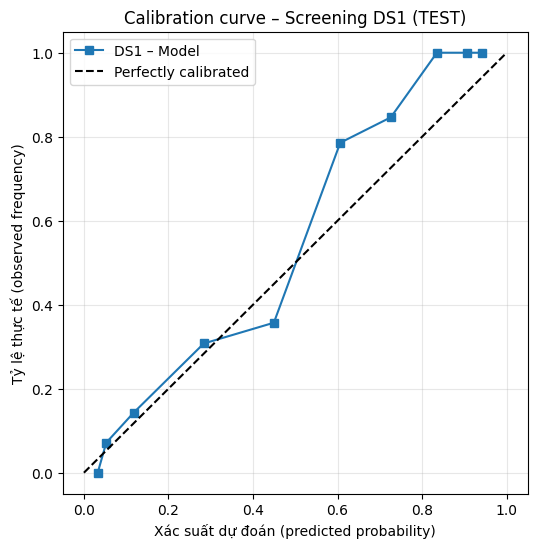

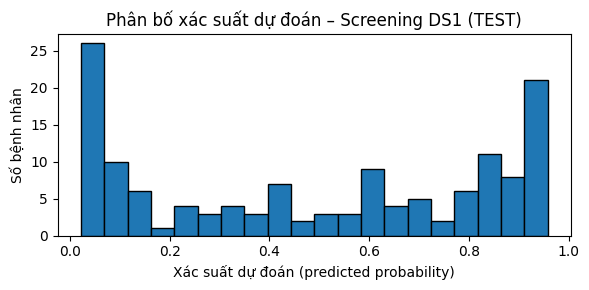

In [29]:
# ============================================================
# Step 6: Calibration cho mô hình Screening DS1
#   - Đánh giá calibration trên TEST: Brier + calibration curve + histogram
#   - (Tuỳ chọn) Calibration xác suất bằng Platt/Isotonic: fit trên VAL, evaluate trên TEST
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# ------------------------------------------------------------
# 0) Lấy xác suất dự đoán trên TEST từ best model DS1
# ------------------------------------------------------------
y1_proba_test = np.asarray(y1_test_proba).astype(float)
if np.any(np.isnan(y1_proba_test)):
    raise ValueError("[DS1] y1_test_proba có NaN.") # proba class=1 trên TEST (đã tính ở Step 5)

# ------------------------------------------------------------
# 1) Brier score (đánh giá độ tốt của xác suất)
# ------------------------------------------------------------
brier_ds1 = brier_score_loss(y1_test, y1_proba_test)
print(f"[DS1] Brier score (TEST) – càng thấp càng tốt: {brier_ds1:.4f}")

# ------------------------------------------------------------
# 2) Calibration curve data
# ------------------------------------------------------------
n_bins = 10
strategy = "quantile"  # quantile ổn định hơn khi lệch phân phối

prob_true, prob_pred = calibration_curve(
    y1_test, y1_proba_test, n_bins=n_bins, strategy=strategy
)

print(f"[DS1] Calibration curve: n_bins={n_bins}, strategy='{strategy}'")

# ------------------------------------------------------------
# 3) Plot calibration curve
# ------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, "s-", label="DS1 – Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Xác suất dự đoán (predicted probability)")
plt.ylabel("Tỷ lệ thực tế (observed frequency)")
plt.title("Calibration curve – Screening DS1 (TEST)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 4) Histogram phân bố xác suất
# ------------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.hist(y1_proba_test, bins=20, edgecolor="black")
plt.xlabel("Xác suất dự đoán (predicted probability)")
plt.ylabel("Số bệnh nhân")
plt.title("Phân bố xác suất dự đoán – Screening DS1 (TEST)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5) (Tuỳ chọn) Hiệu chỉnh xác suất (Calibration) bằng Platt/Isotonic
#     - Fit trên VAL, evaluate trên TEST
#     - Chỉ bật nếu bạn muốn dùng proba làm risk score và thấy curve lệch nhiều
# ------------------------------------------------------------

DO_CALIBRATE = False  # đổi thành True nếu muốn calibrate

if DO_CALIBRATE:
    # Fit base model trên TRAIN (đúng như bạn đang làm cho threshold)
    # best_pipe_ds1 đã fit trên TRAIN ở Step train; ở đây ta tạo bản calibrator trên VAL
    # method: 'sigmoid' (Platt) hoặc 'isotonic' (mềm hơn nhưng dễ overfit khi data nhỏ)

    method = "sigmoid"  # hoặc "isotonic"

    calib = CalibratedClassifierCV(
        estimator=best_pipe_ds1,
        method=method,
        cv="prefit"  # vì best_pipe_ds1 đã fit trên TRAIN
    )

    # Fit calibrator trên VALIDATION
    calib.fit(X1_val, y1_val)

    # Predict calibrated proba trên TEST
    y1_proba_test_cal = calib.predict_proba(X1_test)[:, 1]

    brier_cal = brier_score_loss(y1_test, y1_proba_test_cal)
    print(f"[DS1] Brier score (TEST) sau calibration='{method}': {brier_cal:.4f}")

    prob_true_cal, prob_pred_cal = calibration_curve(
        y1_test, y1_proba_test_cal, n_bins=n_bins, strategy=strategy
    )

    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, "s-", label="Before calibration")
    plt.plot(prob_pred_cal, prob_true_cal, "o-", label=f"After calibration ({method})")
    plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title("Calibration curve – DS1 (TEST)")
    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    plt.show()


### Step 7: Vẽ ROC, Confusion Matrix, Precision–Recall cho Dataset 1

In [30]:
# ============================================================
# Step 7: Vẽ ROC, Confusion Matrix, Precision–Recall cho DS1
#   - ROC/PR dùng proba (không phụ thuộc threshold)
#   - Confusion Matrix: so sánh threshold=0.5 vs tuned
#   - An toàn: confusion_matrix luôn 2x2 bằng labels=[0,1]
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    confusion_matrix,
    precision_recall_curve,
    auc,
    average_precision_score,
)

# --------------------------
# ROC curve
# --------------------------
def plot_roc(y_true, y_proba, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_score = auc(fpr, tpr)

    print(f"[ROC] AUC = {auc_score:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Random guess")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# --------------------------
# Confusion Matrix + Sens/Spec/BAcc
# --------------------------
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(4.5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred: 0", "Pred: 1"],
        yticklabels=["True: 0", "True: 1"],
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    balanced_acc = (specificity + sensitivity) / 2

    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"Sensitivity (Recall/TPR): {sensitivity:.4f}")
    print(f"Specificity (TNR)       : {specificity:.4f}")
    print(f"Balanced Accuracy       : {balanced_acc:.4f}")
    print("-" * 50)

# --------------------------
# Precision–Recall curve
# --------------------------
def plot_precision_recall(y_true, y_proba, title="Precision–Recall Curve"):
    precisions, recalls, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recalls, precisions)
    ap = average_precision_score(y_true, y_proba)

    print(f"[PR] PR-AUC = {pr_auc:.4f} | AP = {ap:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.3f}, AP = {ap:.3f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Apply for DS1
# ------------------------------------------------------------
y1_test_proba_best = best_pipe_ds1.predict_proba(X1_test)[:, 1]
model_label = best_model_label_ds1



[ROC] AUC = 0.9512


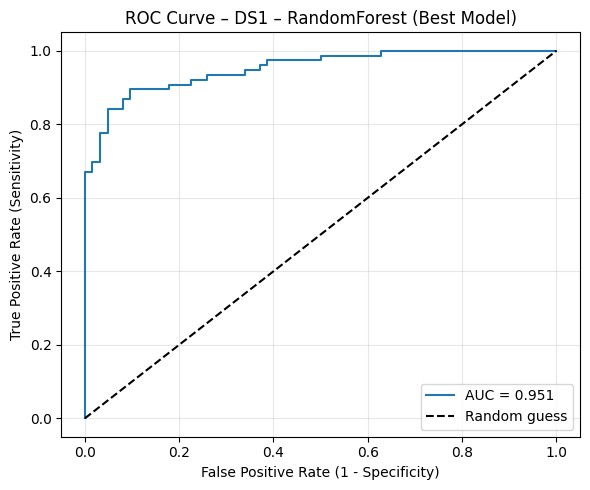

In [13]:
# 2) ROC curve – đánh giá khả năng phân biệt của mô hình
plot_roc(
    y1_test,
    y1_test_proba_best,
    title=f"ROC Curve – DS1 – {model_label} (Best Model)"
)

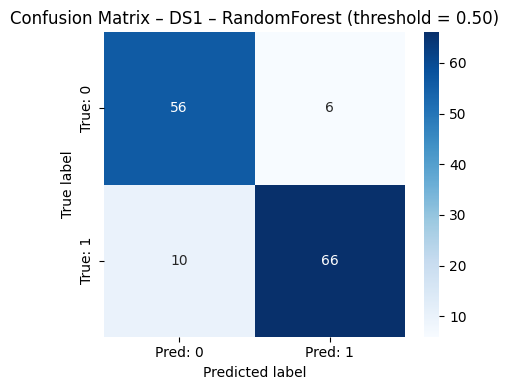

TN=56, FP=6, FN=10, TP=66
Sensitivity (Recall/TPR): 0.8684
Specificity (TNR)       : 0.9032
Balanced Accuracy       : 0.8858
--------------------------------------------------


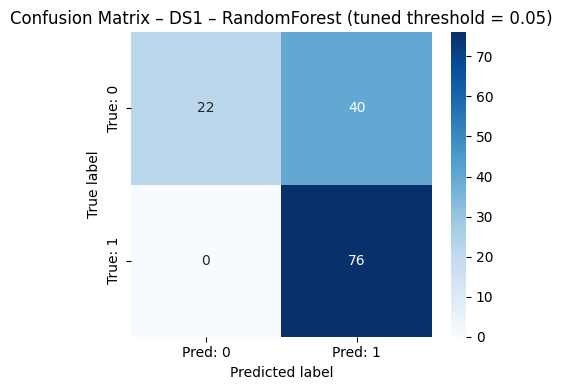

TN=22, FP=40, FN=0, TP=76
Sensitivity (Recall/TPR): 1.0000
Specificity (TNR)       : 0.3548
Balanced Accuracy       : 0.6774
--------------------------------------------------


In [14]:
# Confusion matrix: baseline 0.5
y1_test_pred_05 = (y1_test_proba_best >= 0.5).astype(int)
plot_confusion(
    y1_test,
    y1_test_pred_05,
    title=f"Confusion Matrix – DS1 – {model_label} (threshold = 0.50)"
)

# Confusion matrix: tuned threshold
y1_test_pred_tuned = (y1_test_proba_best >= best_th_ds1).astype(int)
plot_confusion(
    y1_test,
    y1_test_pred_tuned,
    title=f"Confusion Matrix – DS1 – {model_label} (tuned threshold = {best_th_ds1:.2f})"
)

[PR] PR-AUC = 0.9655 | AP = 0.9657


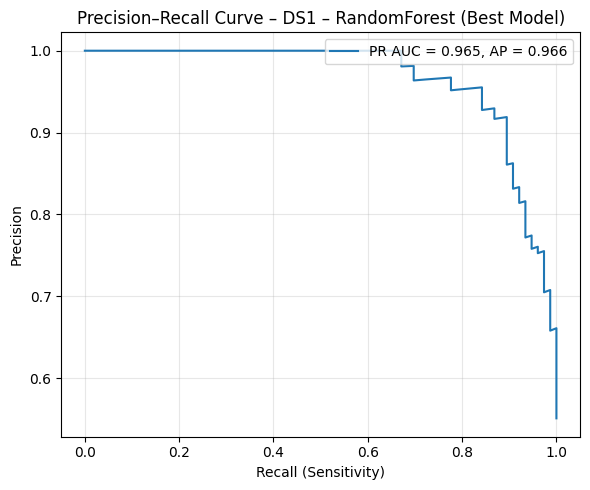

In [15]:
# PR curve
plot_precision_recall(
    y1_test,
    y1_test_proba_best,
    title=f"Precision–Recall Curve – DS1 – {model_label} (Best Model)"
)

### Step 8: Giải thích mô hình Screening: Feature Importance & SHAP (Dataset 1)

Tổng số feature DS1: 20

Top 10 features (Permutation Importance – ROC-AUC):


Cholesterol          0.025393
ChestPainType_ASY    0.018994
ST_Slope_Up          0.017424
Oldpeak              0.013890
ST_Slope_Flat        0.012044
Sex_F                0.007767
ExerciseAngina_Y     0.007757
Sex_M                0.007131
ExerciseAngina_N     0.006070
ChestPainType_ATA    0.005741
dtype: float64

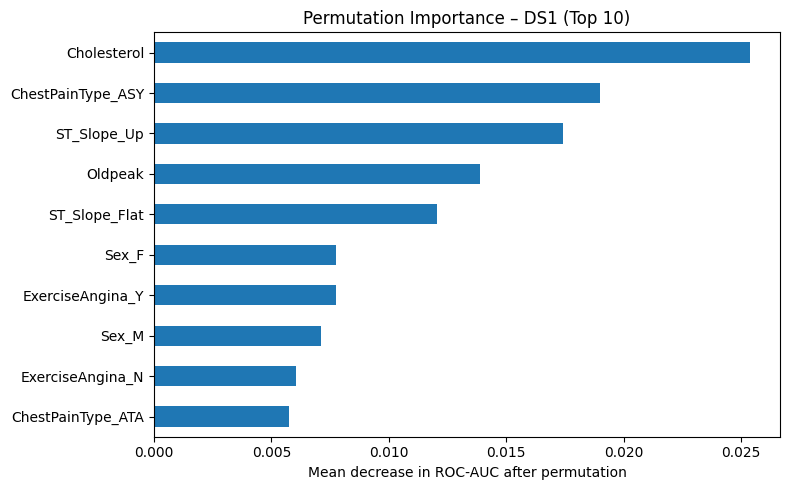

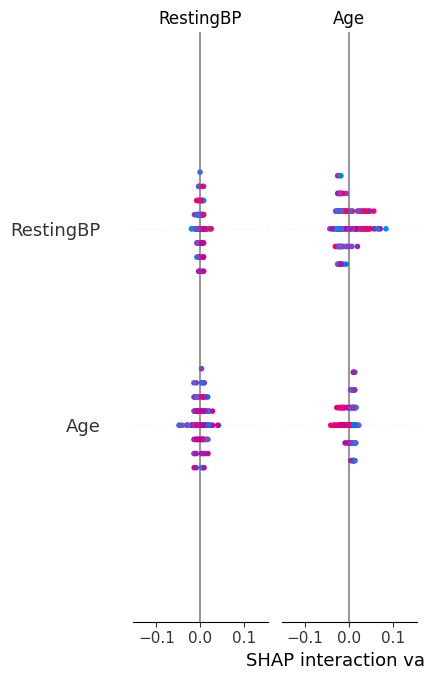

In [31]:
# ============================================================
# Step 8 (DS1): Giải thích mô hình – Permutation Importance & SHAP (ROBUST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy import sparse
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 0) Chọn model để giải thích
#   - Nếu bạn đã có final_pipe_ds1 (fit train+val) và muốn giải thích model triển khai:
#       pipe_explain = final_pipe_ds1
#   - Nếu không, dùng best_pipe_ds1 (model đã chọn và fit trên TRAIN)
# ------------------------------------------------------------
pipe_explain = best_pipe_ds1  # đổi thành final_pipe_ds1 nếu bạn muốn

pre1 = pipe_explain.named_steps["pre"]
clf1 = pipe_explain.named_steps["clf"]

# ------------------------------------------------------------
# 1) Lấy feature names sau preprocess theo đúng thứ tự
# ------------------------------------------------------------
feature_names1 = []
feature_names1.extend(list(numeric_cols1))

try:
    ohe1 = pre1.named_transformers_["cat"].named_steps["onehot"]
    ohe_feature_names1 = ohe1.get_feature_names_out(cat_cols1)
    feature_names1.extend(list(ohe_feature_names1))
except Exception:
    print("[WARNING] Không lấy được tên từ OneHotEncoder; dùng tên categorical gốc.")
    feature_names1.extend(list(cat_cols1))

print("Tổng số feature DS1:", len(feature_names1))

# ------------------------------------------------------------
# 2) Transform X_test sang space model train (giữ sparse nếu có)
# ------------------------------------------------------------
X1_test_trans = pre1.transform(X1_test)

assert X1_test_trans.shape[1] == len(feature_names1), (
    f"Số cột sau transform ({X1_test_trans.shape[1]}) "
    f"khác số feature_names ({len(feature_names1)})"
)

# ------------------------------------------------------------
# 3) Permutation Importance (theo ROC-AUC) trên space đã transform
# ------------------------------------------------------------
try:
    r1 = permutation_importance(
        estimator=clf1,
        X=X1_test_trans,
        y=y1_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1,
        scoring="roc_auc",
    )

    fi1 = pd.Series(r1.importances_mean, index=feature_names1).sort_values(ascending=False)

    print("\nTop 10 features (Permutation Importance – ROC-AUC):")
    display(fi1.head(10))

    plt.figure(figsize=(8, 5))
    fi1.head(10).sort_values().plot(kind="barh")
    plt.title("Permutation Importance – DS1 (Top 10)")
    plt.xlabel("Mean decrease in ROC-AUC after permutation")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Permutation importance failed DS1:", e)

# ------------------------------------------------------------
# 4) Chuẩn bị dữ liệu cho SHAP: sample trước khi densify (tránh nổ RAM)
# ------------------------------------------------------------
rng = np.random.RandomState(42)

max_shap_samples = 300
n_rows = X1_test_trans.shape[0]
idx = rng.choice(n_rows, min(max_shap_samples, n_rows), replace=False)
X_shap_trans = X1_test_trans[idx]

# densify sau khi sample
if sparse.issparse(X_shap_trans):
    X_shap = X_shap_trans.toarray()
else:
    X_shap = np.asarray(X_shap_trans)

# background nhỏ để tăng ổn định/tốc độ
bg_size = min(100, X_shap.shape[0])
bg_idx = rng.choice(X_shap.shape[0], bg_size, replace=False)
X_bg = X_shap[bg_idx]

# ------------------------------------------------------------
# 5) SHAP (ưu tiên): TreeExplainer cho tree-based
#    - Fix lỗi additivity: check_additivity=False
#    - Với LogisticRegression: dùng LinearExplainer
#    - Nếu fail: fallback PermutationExplainer
# ------------------------------------------------------------
def is_tree_model(estimator):
    return any(
        hasattr(estimator, attr) for attr in ["feature_importances_", "estimators_", "get_booster"]
    )

try:
    shap.initjs()

    if is_tree_model(clf1):
        # Tree-based (RF/CatBoost/XGB)
        explainer = shap.TreeExplainer(clf1, data=X_bg)

        shap_vals = explainer.shap_values(X_shap, check_additivity=False)

        # classifier thường trả list theo class
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]  # class=1

        shap.summary_plot(
            shap_vals,
            X_shap,
            feature_names=feature_names1,
            plot_type="dot",
            show=True
        )

    else:
        # Linear model (LogisticRegression, etc.)
        explainer = shap.LinearExplainer(clf1, X_bg)
        shap_vals = explainer.shap_values(X_shap)

        shap.summary_plot(
            shap_vals,
            X_shap,
            feature_names=feature_names1,
            plot_type="dot",
            show=True
        )

except Exception as e:
    print("[WARNING] SHAP Tree/Linear explainer failed, fallback to PermutationExplainer. Error:", e)

    try:
        # Model-agnostic fallback (chậm hơn)
        f = lambda X: clf1.predict_proba(X)[:, 1]
        explainer_perm = shap.PermutationExplainer(f, X_bg)
        shap_values_perm = explainer_perm(X_shap, max_evals=1000)

        shap.summary_plot(
            shap_values_perm,
            X_shap,
            feature_names=feature_names1,
            plot_type="dot",
            show=True
        )

    except Exception as e2:
        print("SHAP fallback PermutationExplainer failed:", e2)


### Step 9: Đánh giá Fairness

In [32]:
# ============================================================
# Step 9: ĐÁNH GIÁ FAIRNESS cho mô hình Screening DS1 (robust)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

# ------------------------------------------------------------
# 1) Xác định cột sex và age an toàn hơn
# ------------------------------------------------------------
sex_candidates = [c for c in df1.columns if "sex" in c.lower()]
if not sex_candidates:
    print("Không tìm thấy cột giới tính trong df1.")
    sex_col = None
else:
    sex_col = sex_candidates[0]

# Ưu tiên cột age đúng tên trước
preferred_age_cols = ["age", "Age", "age_years", "AgeYears", "age_year"]
age_col = None
for c in preferred_age_cols:
    if c in df1.columns:
        age_col = c
        break
if age_col is None:
    age_candidates = [c for c in df1.columns if c.lower() == "age"]
    if age_candidates:
        age_col = age_candidates[0]
    else:
        # fallback substring nhưng tránh "age_group"
        age_candidates = [c for c in df1.columns if ("age" in c.lower()) and ("group" not in c.lower())]
        age_col = age_candidates[0] if age_candidates else None

if age_col is None:
    print("Không tìm thấy cột tuổi trong df1.")
if sex_col is None or age_col is None:
    print("Thiếu sex/age -> không chạy fairness DS1.")
else:
    print(f"[*] Sex col: {sex_col}")
    print(f"[*] Age col: {age_col}")

    # ------------------------------------------------------------
    # 2) Proba + dự đoán ở 2 threshold
    # ------------------------------------------------------------
    y1_test_proba_best = best_pipe_ds1.predict_proba(X1_test)[:, 1]
    y1_test_pred_05 = (y1_test_proba_best >= 0.5).astype(int)
    y1_test_pred_tuned = (y1_test_proba_best >= best_th_ds1).astype(int)

    # ------------------------------------------------------------
    # 3) df_eval: gắn nhãn thật + sex + age + agegroup
    # ------------------------------------------------------------
    df1_eval = pd.DataFrame(index=X1_test.index)
    df1_eval["y_true"] = np.asarray(y1_test)
    df1_eval["y_pred_05"] = y1_test_pred_05
    df1_eval["y_pred_tuned"] = y1_test_pred_tuned

    # sex
    df1_eval["Sex"] = df1.loc[X1_test.index, sex_col].astype("object").fillna("Unknown")

    # age numeric
    df1_eval["Age"] = pd.to_numeric(df1.loc[X1_test.index, age_col], errors="coerce")

    # AgeGroup: xử lý NaN
    def make_age_group(a):
        if pd.isna(a):
            return "Unknown"
        if a < 40:
            return "<40"
        elif a <= 60:
            return "40-60"
        else:
            return ">60"

    df1_eval["AgeGroup"] = df1_eval["Age"].apply(make_age_group)

    # (tuỳ chọn) nhóm giao nhau Sex x AgeGroup
    df1_eval["Sex_x_AgeGroup"] = df1_eval["Sex"].astype(str) + " | " + df1_eval["AgeGroup"].astype(str)

    # ------------------------------------------------------------
    # 4) Hàm tính fairness metrics (robust: cm luôn 2x2)
    # ------------------------------------------------------------
    def compute_fairness(df_eval, group_col, pred_col, th_label):
        rows = []
        for group, data in df_eval.groupby(group_col, dropna=False):
            cm = confusion_matrix(data["y_true"], data[pred_col], labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
            balanced_acc = (sensitivity + specificity) / 2

            rows.append({
                "Group by": group_col,
                "Group": group,
                "Threshold": th_label,
                "N": int(len(data)),
                "Accuracy": float(accuracy_score(data["y_true"], data[pred_col])),
                "Positive Rate (Pred=1)": float(np.mean(data[pred_col])),
                "Recall (Sensitivity)": float(sensitivity),
                "Specificity": float(specificity),
                "FPR": float(fpr),
                "FNR": float(fnr),
                "Balanced Accuracy": float(balanced_acc),
            })
        return pd.DataFrame(rows)

    # ------------------------------------------------------------
    # 5) Fairness theo Sex (0.5 vs tuned)
    # ------------------------------------------------------------
    fair_sex_05 = compute_fairness(df1_eval, "Sex", "y_pred_05", "0.50 (baseline)")
    fair_sex_tuned = compute_fairness(df1_eval, "Sex", "y_pred_tuned", f"{best_th_ds1:.2f} (tuned)")
    fair_sex = pd.concat([fair_sex_05, fair_sex_tuned], ignore_index=True)

    print("\n=== FAIRNESS theo GIỚI TÍNH – DS1 ===")
    display(fair_sex.sort_values(["Group", "Threshold"]))

    # ------------------------------------------------------------
    # 6) Fairness theo AgeGroup (0.5 vs tuned)
    # ------------------------------------------------------------
    fair_age_05 = compute_fairness(df1_eval, "AgeGroup", "y_pred_05", "0.50 (baseline)")
    fair_age_tuned = compute_fairness(df1_eval, "AgeGroup", "y_pred_tuned", f"{best_th_ds1:.2f} (tuned)")
    fair_age = pd.concat([fair_age_05, fair_age_tuned], ignore_index=True)

    print("\n=== FAIRNESS theo NHÓM TUỔI – DS1 ===")
    display(fair_age.sort_values(["Group", "Threshold"]))

    # ------------------------------------------------------------
    # 7) (Tuỳ chọn) Fairness giao nhau Sex × AgeGroup
    # ------------------------------------------------------------
    fair_inter_05 = compute_fairness(df1_eval, "Sex_x_AgeGroup", "y_pred_05", "0.50 (baseline)")
    fair_inter_tuned = compute_fairness(df1_eval, "Sex_x_AgeGroup", "y_pred_tuned", f"{best_th_ds1:.2f} (tuned)")
    fair_inter = pd.concat([fair_inter_05, fair_inter_tuned], ignore_index=True)

    print("\n=== FAIRNESS giao nhau (Sex × AgeGroup) – DS1 (tuỳ chọn, để soi lệch nhóm nhỏ) ===")
    display(fair_inter.sort_values(["N", "Group"], ascending=[True, True]).head(20))


[*] Sex col: Sex
[*] Age col: Age

=== FAIRNESS theo GIỚI TÍNH – DS1 ===


,Group by,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
2,Sex,F,0.05 (tuned),33,0.363636,0.787879,1.000000,0.250000,0.750000,0.000000,0.625000
0,Sex,F,0.50 (baseline),33,0.909091,0.181818,0.800000,0.928571,0.071429,0.200000,0.864286
3,Sex,M,0.05 (tuned),105,0.819048,0.857143,1.000000,0.441176,0.558824,0.000000,0.720588
1,Sex,M,0.50 (baseline),105,0.876190,0.628571,0.873239,0.882353,0.117647,0.126761,0.877796



=== FAIRNESS theo NHÓM TUỔI – DS1 ===


,Group by,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
3,AgeGroup,40-60,0.05 (tuned),103,0.708738,0.834951,1.000000,0.361702,0.638298,0.000000,0.680851
0,AgeGroup,40-60,0.50 (baseline),103,0.864078,0.485437,0.821429,0.914894,0.085106,0.178571,0.868161
4,AgeGroup,<40,0.05 (tuned),11,0.727273,0.545455,1.000000,0.625000,0.375000,0.000000,0.812500
1,AgeGroup,<40,0.50 (baseline),11,1.000000,0.272727,1.000000,1.000000,0.000000,0.000000,1.000000
5,AgeGroup,>60,0.05 (tuned),24,0.708333,1.000000,1.000000,0.000000,1.000000,0.000000,0.500000
2,AgeGroup,>60,0.50 (baseline),24,0.916667,0.791667,1.000000,0.714286,0.285714,0.000000,0.857143



=== FAIRNESS giao nhau (Sex × AgeGroup) – DS1 (tuỳ chọn, để soi lệch nhóm nhỏ) ===


,Group by,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),Recall (Sensitivity),Specificity,FPR,FNR,Balanced Accuracy
1,Sex_x_AgeGroup,F | <40,0.50 (baseline),3,1.000000,0.333333,1.000000,1.000000,0.000000,0.000000,1.000000
7,Sex_x_AgeGroup,F | <40,0.05 (tuned),3,0.666667,0.666667,1.000000,0.500000,0.500000,0.000000,0.750000
2,Sex_x_AgeGroup,F | >60,0.50 (baseline),5,0.800000,0.200000,0.000000,0.800000,0.200000,0.000000,0.400000
8,Sex_x_AgeGroup,F | >60,0.05 (tuned),5,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
4,Sex_x_AgeGroup,M | <40,0.50 (baseline),8,1.000000,0.250000,1.000000,1.000000,0.000000,0.000000,1.000000
10,Sex_x_AgeGroup,M | <40,0.05 (tuned),8,0.750000,0.500000,1.000000,0.666667,0.333333,0.000000,0.833333
5,Sex_x_AgeGroup,M | >60,0.50 (baseline),19,0.947368,0.947368,1.000000,0.500000,0.500000,0.000000,0.750000
11,Sex_x_AgeGroup,M | >60,0.05 (tuned),19,0.894737,1.000000,1.000000,0.000000,1.000000,0.000000,0.500000
0,Sex_x_AgeGroup,F | 40-60,0.50 (baseline),25,0.920000,0.160000,0.750000,0.952381,0.047619,0.250000,0.851190
6,Sex_x_AgeGroup,F | 40-60,0.05 (tuned),25,0.400000,0.760000,1.000000,0.285714,0.714286,0.000000,0.642857


## Tối ưu hóa can thiệp

### Import + Feature cols + Import core tối ưu

In [86]:


# ====== Check inputs ======
required = ["df1", "best_pipe_ds1"]
missing = [x for x in required if x not in globals()]
if missing:
    raise NameError(f"Thiếu biến {missing}. Hãy chạy phần DS1 training trước.")

# ====== Infer feature cols if needed ======
def infer_feature_cols(df, pipe):
    if "feature_cols_ds1" in globals() and isinstance(globals()["feature_cols_ds1"], (list, tuple)) and len(globals()["feature_cols_ds1"]) > 0:
        return list(globals()["feature_cols_ds1"])
    if hasattr(pipe, "feature_names_in_"):
        cols = list(pipe.feature_names_in_)
        if cols:
            return cols
    # fallback numeric except common targets
    label_candidates = [c for c in ["HeartDisease", "DEATH_EVENT", "target", "label", "y"] if c in df.columns]
    cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols = [c for c in cols if c not in label_candidates]
    if not cols:
        raise ValueError("Không suy ra được feature columns. Hãy set feature_cols_ds1 thủ công.")
    print("[WARN] feature_cols_ds1 not found. Falling back to numeric columns.")
    return cols

feature_cols_ds1 = infer_feature_cols(df1, best_pipe_ds1)

print("feature_cols_ds1 (#cols):", len(feature_cols_ds1))
print("feature_cols_ds1 head:", feature_cols_ds1[:15])

# ====== Import optimized intervention core (ưu tiên v2 nếu bạn đặt trong Core/) ======
from Core.intervention_core_optimized import (
        optimize_intervention_multi,
        predict_heart_risk,
        INTERVENTION_VARS_DS1,
        DEFAULT_LAMBDA
)

print("DEFAULT_LAMBDA:", DEFAULT_LAMBDA)
print("Default intervention vars:", [v["name"] for v in INTERVENTION_VARS_DS1])


feature_cols_ds1 (#cols): 11
feature_cols_ds1 head: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
DEFAULT_LAMBDA: 0.02
Default intervention vars: ['RestingBP', 'Oldpeak']


### Tính p_before toàn bộ + chọn idx_test nguy cơ cao

In [87]:
df1 = df1.copy()
df1["p_before"] = best_pipe_ds1.predict_proba(df1[feature_cols_ds1])[:, 1]

idx_test = df1["p_before"].sort_values(ascending=False).index[0]
print("idx_test:", idx_test, "p_before:", float(df1.loc[idx_test, "p_before"]))


idx_test: 369 p_before: 0.9630558229366408


### Helper functions (get row, apply override without clamp BASE)

In [88]:
def get_row_dict(df, idx, cols):
    try:
        return df.loc[idx, cols].to_dict()
    except Exception:
        return df.iloc[int(idx)][cols].to_dict()

def clamp(x, lo=None, hi=None):
    if lo is not None and x < lo: x = lo
    if hi is not None and x > hi: x = hi
    return x

def apply_delta_overrides(patient_raw, var_specs, delta_overrides=None, apply_minmax=True):
    """
    - patient_raw: giữ nguyên raw
    - delta_overrides: dict {var: delta}
    - apply_minmax=True: chỉ clamp min/max cho scenario có can thiệp
    Lưu ý: BASE sẽ gọi apply_minmax=False để không bị clamp "ngầm"
    """
    p = dict(patient_raw)
    if not delta_overrides:
        return p

    for spec in var_specs:
        name = spec["name"]
        if name not in p or pd.isna(p.get(name)):
            continue

        dmin, dmax = spec["delta_bounds"]
        vmin, vmax = spec.get("min_value"), spec.get("max_value")

        d = float(delta_overrides.get(name, 0.0))
        d = clamp(d, float(dmin), float(dmax))

        v0 = float(p[name])
        v_new = v0 + d

        if apply_minmax:
            v_new = clamp(v_new, vmin, vmax)

        p[name] = v_new
    return p


### Test 1 bệnh nhân: tối ưu + in bảng + plot

===== SINGLE PATIENT OPTIMIZATION SUMMARY =====


,idx,method_used,success,no_effect,lambda,p_before,p_after,delta_p,objective(fun_opt),message
0,369,auto,True,False,0.02,0.963056,0.913917,0.049138,0.946837,Optimization terminated successfully


===== CHANGES =====


,name,before,after,delta
0,RestingBP,150.0,100.620959,-49.379041
1,Oldpeak,2.0,2.000000,0.000000


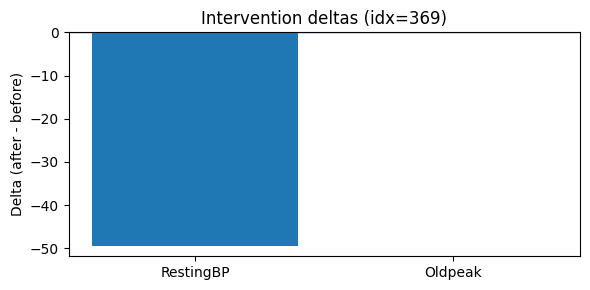

In [89]:
patient = get_row_dict(df1, idx_test, feature_cols_ds1)

res = optimize_intervention_multi(
    base_patient=patient,
    pipe=best_pipe_ds1,
    feature_cols=feature_cols_ds1,
    var_specs=INTERVENTION_VARS_DS1,  # RestingBP + Oldpeak
    lam=0.02,                         # bạn có thể thử 0.01/0.005
    method="auto",
    n_random=64,
    n_best_starts=4,
    random_state=42
)

df_changes = pd.DataFrame(res["changes"])
summary = pd.DataFrame([{
    "idx": idx_test,
    "method_used": res.get("method_used"),
    "success": res["success"],
    "no_effect": res["no_effect"],
    "lambda": res["lambda"],
    "p_before": res["p_before"],
    "p_after": res["p_after"],
    "delta_p": res["delta_p"],
    "objective(fun_opt)": res["fun_opt"],
    "message": res["message"],
}])

print("===== SINGLE PATIENT OPTIMIZATION SUMMARY =====")
display(summary)
print("===== CHANGES =====")
display(df_changes)

plt.figure(figsize=(6, 3))
plt.bar(df_changes["name"], df_changes["delta"])
plt.axhline(0, linewidth=1)
plt.title(f"Intervention deltas (idx={idx_test})")
plt.ylabel("Delta (after - before)")
plt.tight_layout()
plt.show()


### Sensitivity check (BASE raw đúng, không clamp ngầm)

===== SENSITIVITY CHECK (BOUNDARY WHAT-IF, BASE RAW) =====


,scenario,p,delta_p_vs_base,RestingBP_before,RestingBP_after,RestingBP_delta,Oldpeak_before,Oldpeak_after,Oldpeak_delta
1,RestingBP at dmin,0.915300,0.047756,150.0,90.0,-60.0,2.0,2.0,0.0
3,ALL at dmin (combo),0.926215,0.036841,150.0,90.0,-60.0,2.0,0.0,-2.0
2,Oldpeak at dmin,0.956284,0.006772,150.0,150.0,0.0,2.0,0.0,-2.0
0,BASE (raw),0.963056,0.000000,150.0,150.0,0.0,2.0,2.0,0.0


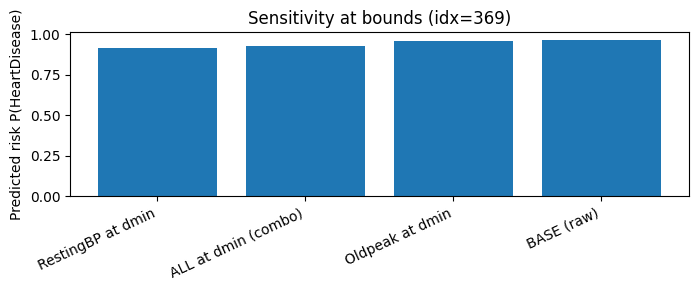

In [90]:
var_specs_sens = INTERVENTION_VARS_DS1  # chỉ RestingBP + Oldpeak

# BASE thật: predict trực tiếp từ patient raw
p_base = predict_heart_risk(patient, best_pipe_ds1, feature_cols_ds1)

scenarios = [("BASE (raw)", None)]
for s in var_specs_sens:
    scenarios.append((f"{s['name']} at dmin", {s["name"]: float(s["delta_bounds"][0])}))
all_dmin = {s["name"]: float(s["delta_bounds"][0]) for s in var_specs_sens}
scenarios.append(("ALL at dmin (combo)", all_dmin))

rows = []
for name, overrides in scenarios:
    if overrides is None:
        p2 = dict(patient)  # giữ raw
    else:
        p2 = apply_delta_overrides(patient, var_specs_sens, overrides, apply_minmax=True)

    p = predict_heart_risk(p2, best_pipe_ds1, feature_cols_ds1)

    rec = {"scenario": name, "p": float(p), "delta_p_vs_base": float(p_base - p)}
    for s in var_specs_sens:
        v = s["name"]
        rec[f"{v}_before"] = float(patient[v])
        rec[f"{v}_after"]  = float(p2[v])
        rec[f"{v}_delta"]  = float(p2[v]) - float(patient[v])
    rows.append(rec)

df_sens = pd.DataFrame(rows).sort_values("p", ascending=True)

print("===== SENSITIVITY CHECK (BOUNDARY WHAT-IF, BASE RAW) =====")
display(df_sens)

plt.figure(figsize=(7, 3))
plt.bar(df_sens["scenario"], df_sens["p"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Predicted risk P(HeartDisease)")
plt.title(f"Sensitivity at bounds (idx={idx_test})")
plt.tight_layout()
plt.show()


### Batch 200 + lambda sweep + thống kê + top-10 + plots

In [ ]:


# ---------- Helpers ----------
def get_row_dict(df, idx, cols):
    try:
        return df.loc[idx, cols].to_dict()
    except Exception:
        return df.iloc[int(idx)][cols].to_dict()

def batch_stats(df_opt: pd.DataFrame, var_specs, lam: float):
    if df_opt.empty:
        return pd.DataFrame([{
            "lambda": float(lam),
            "N_evaluated": 0,
            "pct_improved": 0.0,
            "median_delta_p": 0.0,
            "mean_delta_p": 0.0,
            "pct_success": 0.0,
            "pct_no_effect": 0.0,
        }])

    improved = df_opt["delta_p"] > 1e-9

    # feasibility: median abs deltas
    abs_cols = [c for c in df_opt.columns if c.endswith("_abs_delta")]
    abs_medians = {f"median_{c}": float(df_opt[c].median()) for c in abs_cols}

    # boundary hit
    hit_stats = {}
    for spec in var_specs:
        v = spec["name"]
        dmin, dmax = spec["delta_bounds"]
        col = f"{v}_delta"
        if col in df_opt.columns:
            hit_stats[f"pct_hit_{v}_dmin"] = float((df_opt[col] <= dmin + 1e-6).mean() * 100.0)
            hit_stats[f"pct_hit_{v}_dmax"] = float((df_opt[col] >= dmax - 1e-6).mean() * 100.0)

    return pd.DataFrame([{
        "lambda": float(lam),
        "N_evaluated": int(len(df_opt)),
        "pct_improved": float(improved.mean() * 100.0),
        "median_delta_p": float(df_opt["delta_p"].median()),
        "mean_delta_p": float(df_opt["delta_p"].mean()),
        "pct_success": float(df_opt["success"].mean() * 100.0),
        "pct_no_effect": float(df_opt["no_effect"].mean() * 100.0),
        **abs_medians,
        **hit_stats
    }])

def run_batch_opt_fast(
    df,
    pipe,
    feature_cols,
    var_specs,
    lam,
    N=120,                 # giảm từ 200 -> 120 (đủ cho báo cáo)
    pick="top",            # "top" hoặc "random"
    random_state=42,
    # FAST SCAN params
    scan_method="random",  # nhanh nhất
    # REFINE params
    refine_method="auto",  # robust
    refine_top_k=30,       # chỉ refine top 30 ca tốt nhất
    refine_n_random=16,    # giảm 64 -> 16
    refine_n_best=2,       # giảm 4 -> 2
    refine_maxiter=80      # nếu core hỗ trợ; nếu không thì bỏ
):
    df_tmp = df.copy()

    # baseline to select top risk
    df_tmp["_p_before"] = pipe.predict_proba(df_tmp[feature_cols])[:, 1]

    if pick == "random":
        idxs = df_tmp.sample(n=min(N, len(df_tmp)), random_state=random_state).index.tolist()
    else:
        idxs = df_tmp.sort_values("_p_before", ascending=False).head(min(N, len(df_tmp))).index.tolist()

    # ---------- Phase 1: FAST SCAN ----------
    scan_records = []
    for idx in idxs:
        patient = get_row_dict(df_tmp, idx, feature_cols)

        miss = [s["name"] for s in var_specs if (s["name"] not in patient) or pd.isna(patient.get(s["name"]))]
        if miss:
            continue

        # random-only scan is fast
        res = optimize_intervention_multi(
            base_patient=patient,
            pipe=pipe,
            feature_cols=feature_cols,
            var_specs=var_specs,
            lam=float(lam),
            method=scan_method,
            n_random=24,           # small random pool for scan
            n_best_starts=1,
            random_state=random_state
        )

        rec = {
            "idx": idx,
            "p_before": res["p_before"],
            "p_after": res["p_after"],
            "delta_p": res["delta_p"],
            "success": res["success"],
            "no_effect": res["no_effect"],
        }
        for ch in res["changes"]:
            v = ch["name"]
            rec[f"{v}_before"] = ch["before"]
            rec[f"{v}_after"]  = ch["after"]
            rec[f"{v}_delta"]  = ch["delta"]
            rec[f"{v}_abs_delta"] = abs(float(ch["delta"]))
        scan_records.append(rec)

    df_scan = pd.DataFrame(scan_records)
    stat_scan = batch_stats(df_scan, var_specs, lam)
    if df_scan.empty:
        return df_scan, df_scan, stat_scan

    # pick top-k by delta_p for refine (only meaningful candidates)
    df_scan_sorted = df_scan.sort_values("delta_p", ascending=False)
    topk = df_scan_sorted.head(min(refine_top_k, len(df_scan_sorted)))
    refine_idxs = topk["idx"].tolist()

    # ---------- Phase 2: REFINE ONLY TOP-K ----------
    refine_records = []
    for idx in refine_idxs:
        patient = get_row_dict(df_tmp, idx, feature_cols)

        # call robust auto optimizer with smaller params
        kwargs = dict(
            base_patient=patient,
            pipe=pipe,
            feature_cols=feature_cols,
            var_specs=var_specs,
            lam=float(lam),
            method=refine_method,
            n_random=int(refine_n_random),
            n_best_starts=int(refine_n_best),
            random_state=random_state
        )
        # maxiter supported only if your core has it in signature
        try:
            kwargs["maxiter"] = int(refine_maxiter)
            res = optimize_intervention_multi(**kwargs)
        except TypeError:
            kwargs.pop("maxiter", None)
            res = optimize_intervention_multi(**kwargs)

        rec = {
            "idx": idx,
            "p_before": res["p_before"],
            "p_after": res["p_after"],
            "delta_p": res["delta_p"],
            "success": res["success"],
            "no_effect": res["no_effect"],
        }
        for ch in res["changes"]:
            v = ch["name"]
            rec[f"{v}_before"] = ch["before"]
            rec[f"{v}_after"]  = ch["after"]
            rec[f"{v}_delta"]  = ch["delta"]
            rec[f"{v}_abs_delta"] = abs(float(ch["delta"]))
        refine_records.append(rec)

    df_refine = pd.DataFrame(refine_records)
    # stats after refine: apply to scan population for pct_improved etc? 
    # Best practice: use scan stats for population-level %, refine for top-case tables.
    # Still compute refine stats for reference:
    stat_refine = batch_stats(df_refine, var_specs, lam)
    stat_refine = stat_refine.add_prefix("refine_")

    stat_out = pd.concat([stat_scan, stat_refine], axis=1)
    return df_scan, df_refine, stat_out


# ---------- Lambda sweep (FAST) ----------
lam_list = [0.02, 0.01, 0.005]  # giảm 4 -> 3 (đủ)
all_stats = []
scan_by_lam = {}
refine_by_lam = {}

for lam in lam_list:
    df_scan, df_refine, df_stat = run_batch_opt_fast(
        df=df1,
        pipe=best_pipe_ds1,
        feature_cols=feature_cols_ds1,
        var_specs=INTERVENTION_VARS_DS1,   # RestingBP + Oldpeak
        lam=lam,
        N=120,               # bạn có thể dùng 100 nếu máy yếu
        pick="top",
        random_state=42,
        refine_top_k=30,     # refine top 30
        refine_n_random=16,
        refine_n_best=2,
        refine_maxiter=80
    )
    scan_by_lam[lam] = df_scan
    refine_by_lam[lam] = df_refine
    all_stats.append(df_stat)

df_stats = pd.concat(all_stats, ignore_index=True)
# sort by pct_improved (scan) then median_delta_p (scan)
df_stats_sorted = df_stats.sort_values(["pct_improved", "median_delta_p"], ascending=False)

print("===== FAST LAMBDA SWEEP STATS (SCAN + REFINE) =====")
display(df_stats_sorted)

best_lam = float(df_stats_sorted.iloc[0]["lambda"])
print("Best lambda (by scan pct_improved then median_delta_p):", best_lam)

# Use refine results for Top-10 cases (more accurate)
df_best_refine = refine_by_lam[best_lam].copy()
print("===== TOP-10 CASES (REFINED, largest delta_p) =====")
display(df_best_refine.sort_values("delta_p", ascending=False).head(10))

# ---------- Plots for refined set ----------
plt.figure(figsize=(6, 3))
plt.hist(df_best_refine["delta_p"], bins=20)
plt.xlabel("delta_p = p_before - p_after")
plt.ylabel("Count")
plt.title(f"Distribution of delta_p (REFINE, lambda={best_lam})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.scatter(df_best_refine["p_before"], df_best_refine["delta_p"], s=14)
plt.xlabel("p_before")
plt.ylabel("delta_p")
plt.title(f"delta_p vs baseline risk (REFINE, lambda={best_lam})")
plt.tight_layout()
plt.show()


### Xuất CSV

In [ ]:
df_stats.to_csv("opt_lambda_sweep_stats.csv", index=False)
df_opt_best.to_csv(f"opt_results_best_lambda_{best_lam}.csv", index=False)

print("Saved:")
print(" - opt_lambda_sweep_stats.csv")
print(f" - opt_results_best_lambda_{best_lam}.csv")

# Dataset 2

## Trainning

### Step 1: EDA và xử lý outliers

Tổng quan dữ liệu Dataset 2 (Heart Failure):


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


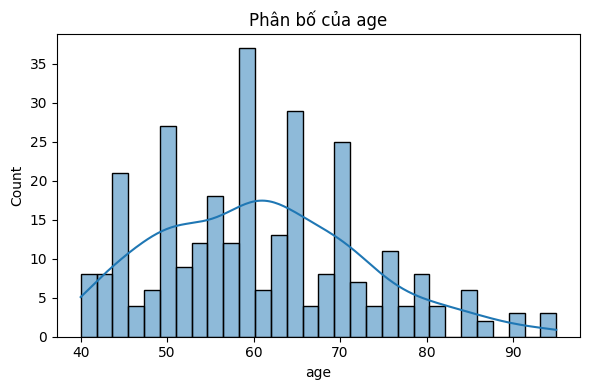

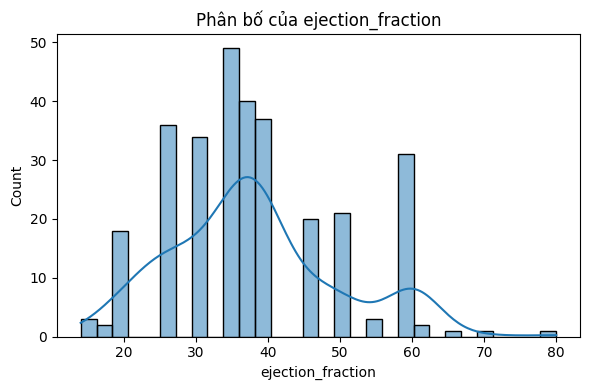

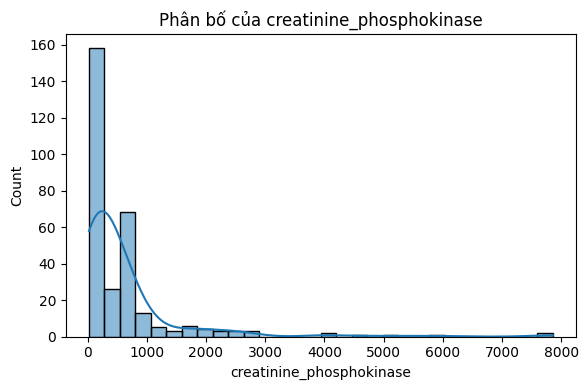

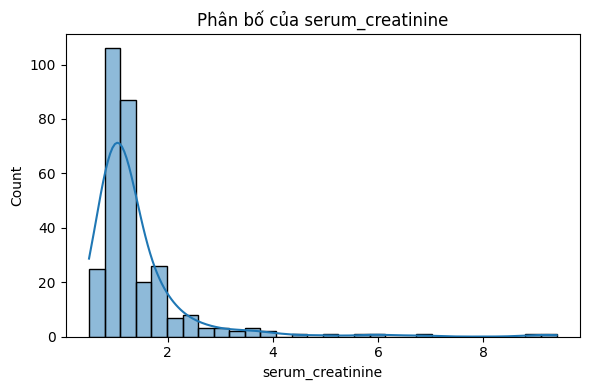

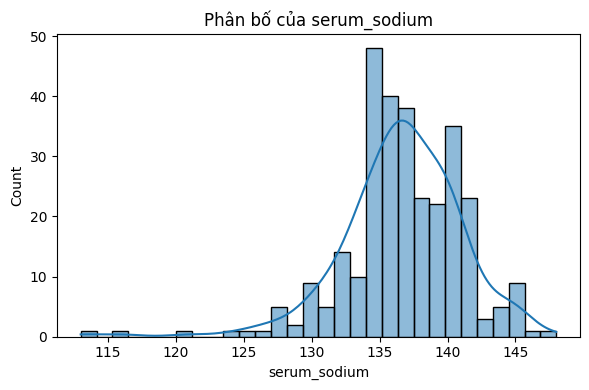

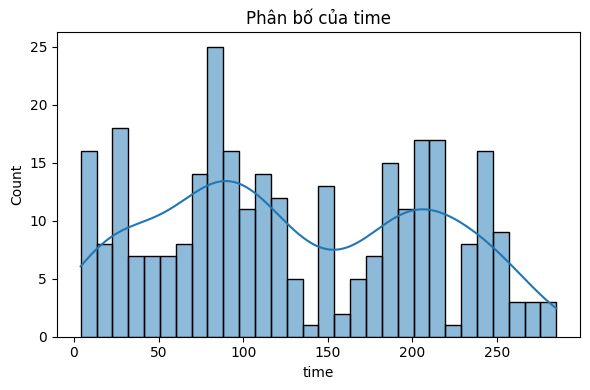

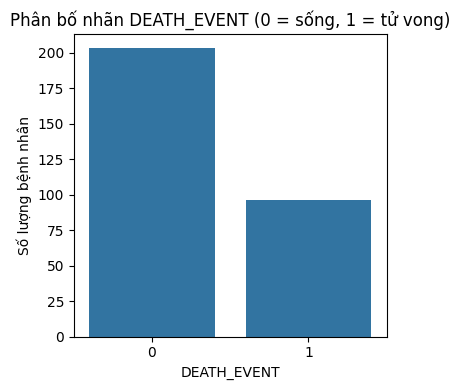

Số lượng từng lớp (DEATH_EVENT):
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Tỷ lệ phần trăm từng lớp:
DEATH_EVENT
0    67.89
1    32.11
Name: proportion, dtype: float64


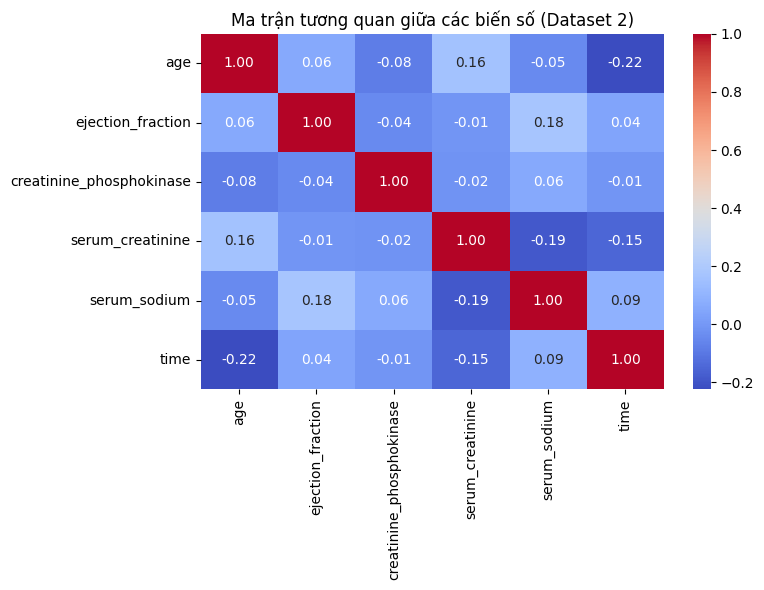

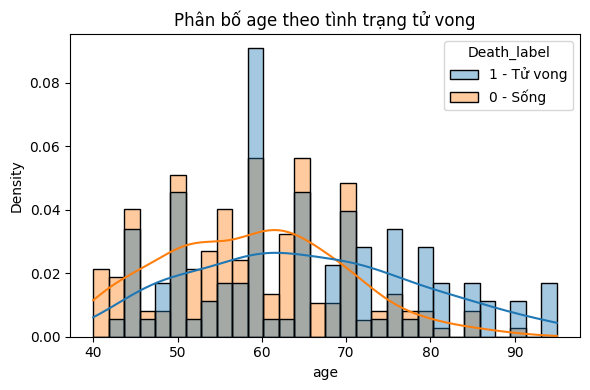

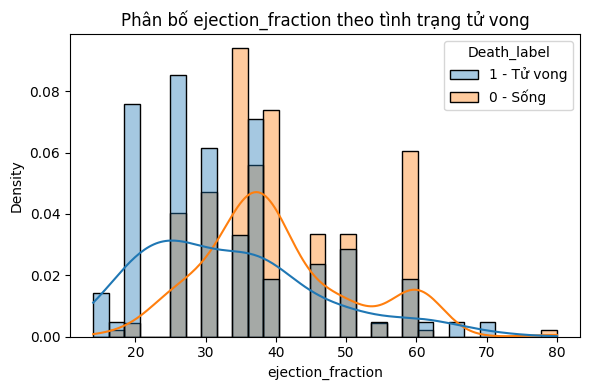

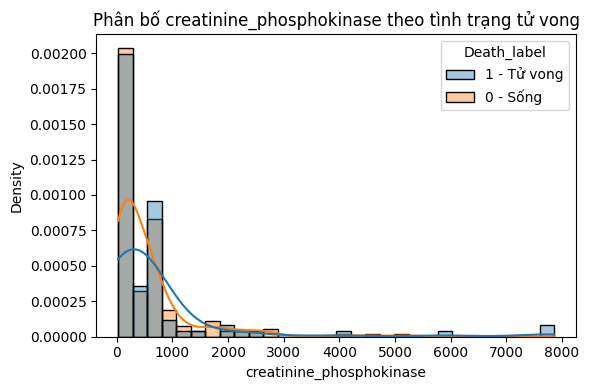

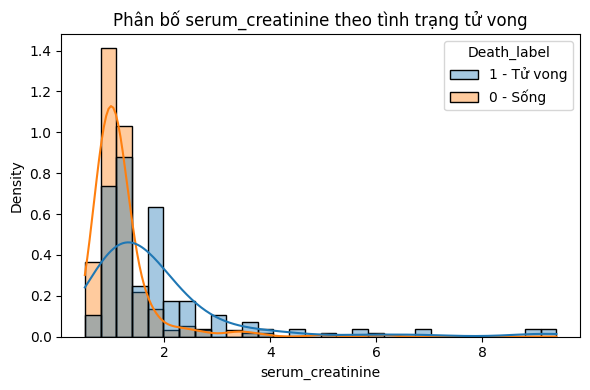

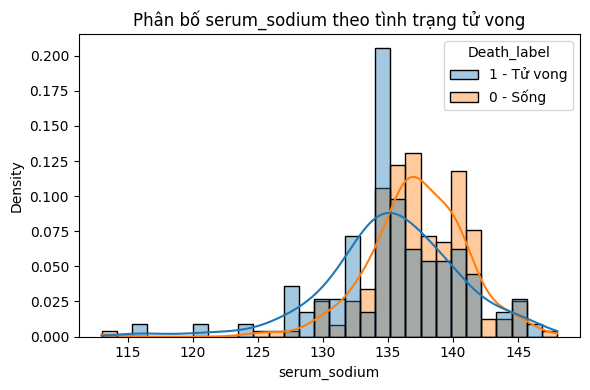

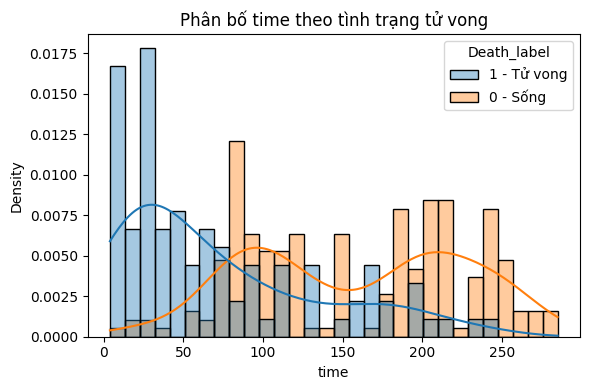

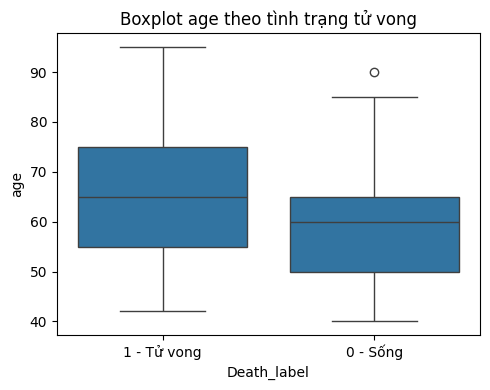

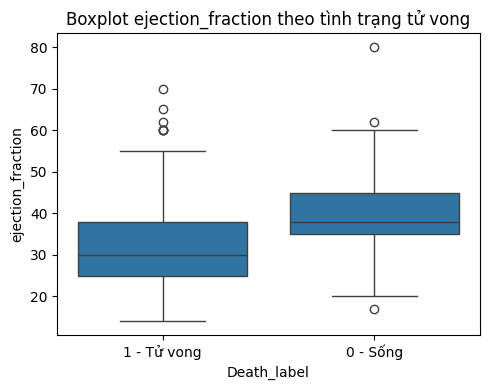

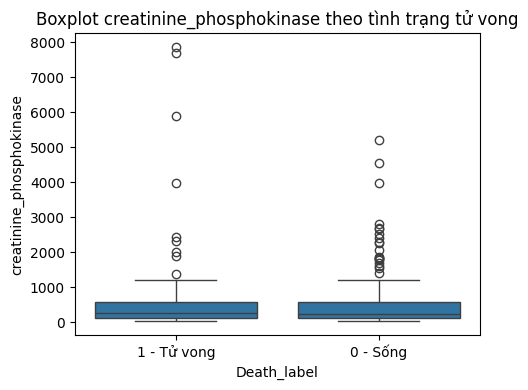

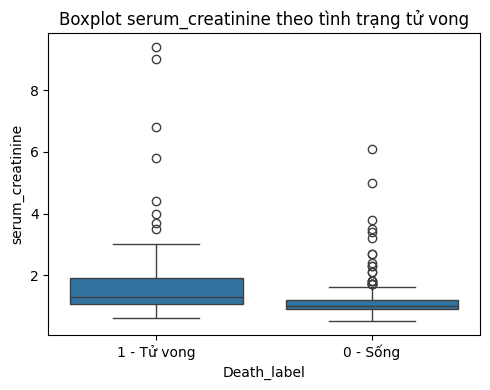

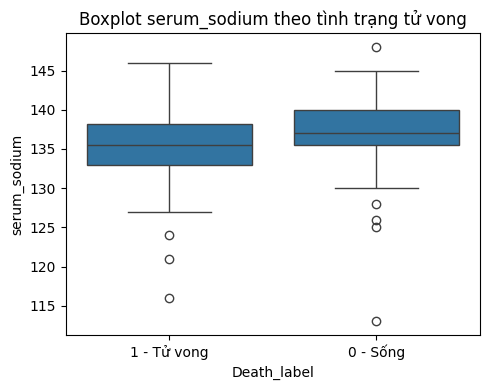

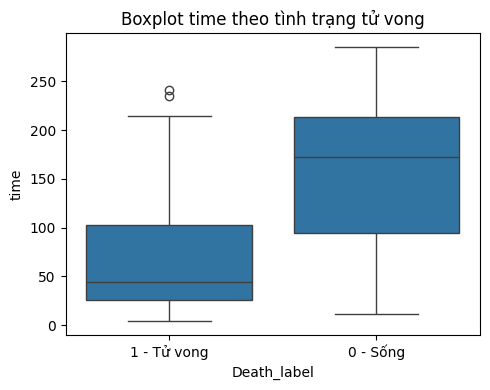

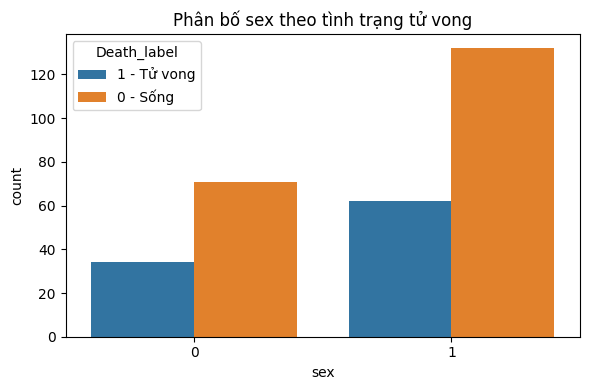

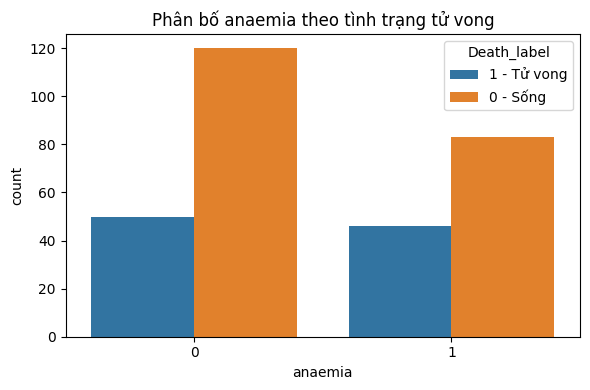

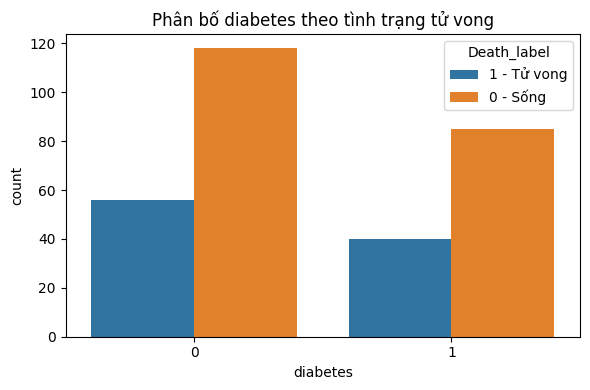

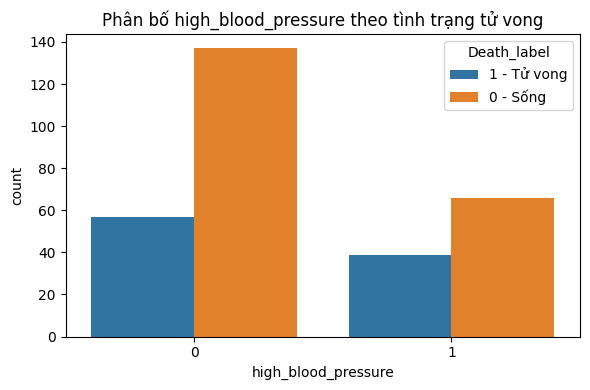

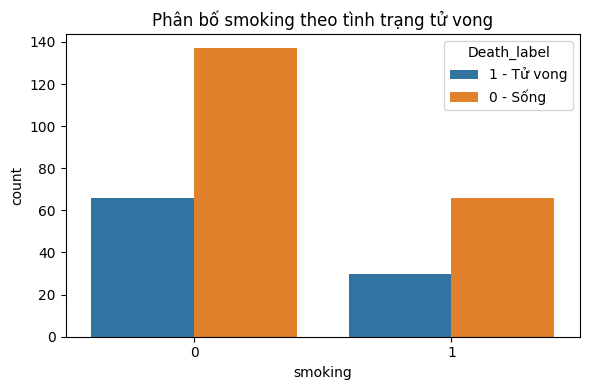


Tỉ lệ DEATH_EVENT theo sex:


,P(sống),P(tử vong)
sex,,
0,0.68,0.32
1,0.68,0.32



Tỉ lệ DEATH_EVENT theo anaemia:


,P(sống),P(tử vong)
anaemia,,
0,0.71,0.29
1,0.64,0.36



Tỉ lệ DEATH_EVENT theo diabetes:


,P(sống),P(tử vong)
diabetes,,
0,0.68,0.32
1,0.68,0.32



Tỉ lệ DEATH_EVENT theo high_blood_pressure:


,P(sống),P(tử vong)
high_blood_pressure,,
0,0.71,0.29
1,0.63,0.37



Tỉ lệ DEATH_EVENT theo smoking:


,P(sống),P(tử vong)
smoking,,
0,0.67,0.33
1,0.69,0.31



[OK] DS2 – STEP 1 EDA hoàn tất (không thay đổi df2).


In [55]:
# ============================================================
# DS2 – STEP 1: EDA 
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_hf_eda = df2.copy()

print("Tổng quan dữ liệu Dataset 2 (Heart Failure):")
display(df_hf_eda.head())
display(df_hf_eda.describe(include="all"))

# 1) Phân bố các biến số quan trọng (EDA có thể xem cả 'time')
num_features_hf = ["age", "ejection_fraction", "creatinine_phosphokinase",
                   "serum_creatinine", "serum_sodium", "time"]

for col in num_features_hf:
    if col in df_hf_eda.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df_hf_eda[col], kde=True, bins=30)
        plt.title(f"Phân bố của {col}")
        plt.tight_layout()
        plt.show()

# 2) Phân bố nhãn DEATH_EVENT
label2 = "DEATH_EVENT" if "DEATH_EVENT" in df_hf_eda.columns else df_hf_eda.columns[-1]

plt.figure(figsize=(4, 4))
sns.countplot(x=df_hf_eda[label2])
plt.title("Phân bố nhãn DEATH_EVENT (0 = sống, 1 = tử vong)")
plt.xlabel(label2)
plt.ylabel("Số lượng bệnh nhân")
plt.tight_layout()
plt.show()

print("Số lượng từng lớp (DEATH_EVENT):")
print(df_hf_eda[label2].value_counts())
print("\nTỷ lệ phần trăm từng lớp:")
print(df_hf_eda[label2].value_counts(normalize=True).mul(100).round(2))

# 3) Ma trận tương quan (EDA)
cols_for_corr = [c for c in num_features_hf if c in df_hf_eda.columns]
if len(cols_for_corr) >= 2:
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_hf_eda[cols_for_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Ma trận tương quan giữa các biến số (Dataset 2)")
    plt.tight_layout()
    plt.show()

# 4) EDA theo nhãn (numeric & categorical)
df_hf_lbl = df_hf_eda.copy()
df_hf_lbl["Death_label"] = df_hf_lbl[label2].map({0: "0 - Sống", 1: "1 - Tử vong"})

numeric_cols_hf = [c for c in ["age","ejection_fraction","creatinine_phosphokinase",
                              "serum_creatinine","serum_sodium","time"]
                   if c in df_hf_lbl.columns]

for col in numeric_cols_hf:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df_hf_lbl,
        x=col,
        hue="Death_label",
        kde=True,
        bins=30,
        stat="density",
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Phân bố {col} theo tình trạng tử vong")
    plt.tight_layout()
    plt.show()

for col in numeric_cols_hf:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df_hf_lbl, x="Death_label", y=col)
    plt.title(f"Boxplot {col} theo tình trạng tử vong")
    plt.tight_layout()
    plt.show()

categorical_cols_hf = [c for c in ["sex","anaemia","diabetes","high_blood_pressure","smoking"]
                       if c in df_hf_lbl.columns]

for col in categorical_cols_hf:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_hf_lbl, x=col, hue="Death_label")
    plt.title(f"Phân bố {col} theo tình trạng tử vong")
    plt.tight_layout()
    plt.show()

for col in categorical_cols_hf:
    print(f"\nTỉ lệ DEATH_EVENT theo {col}:")
    ct = pd.crosstab(df_hf_lbl[col], df_hf_lbl[label2], normalize="index").round(2)
    ct.columns = ["P(sống)", "P(tử vong)"]
    display(ct)

print("\n[OK] DS2 – STEP 1 EDA hoàn tất (không thay đổi df2).")


### Step 2: Tiền xử lý & chia train/val/test cho Dataset 2 (Prognosis)

In [56]:
# ============================================================
# DS2 – STEP 2: SPLIT train/val/test + PREPROCESS 
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# 0) Tạo X2, y2
label2 = "DEATH_EVENT" if "DEATH_EVENT" in df2.columns else df2.columns[-1]
X2 = df2.drop(columns=[label2]).copy()
y2 = df2[label2].astype(int)

assert set(y2.unique()).issubset({0, 1}), f"Label {label2} không phải nhị phân 0/1."

# 1) Drop 'time' để tránh leakage
if "time" in X2.columns:
    X2 = X2.drop(columns=["time"])
    print("[*] Dropped 'time' from DS2 features (avoid leakage).")

# 2) Split train / temp (70/30)
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2,
    test_size=0.30,
    stratify=y2,
    random_state=42
)

# 3) Split temp -> val/test (15/15)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp,
    test_size=0.50,
    stratify=y2_temp,
    random_state=42
)

def show_split_info(name, y):
    print(f"{name}: n = {len(y)}, tỷ lệ tử vong = {y.mean():.3f}")

print("\nPhân bố tử vong theo từng tập:")
show_split_info("TRAIN", y2_train)
show_split_info("VAL",   y2_val)
show_split_info("TEST",  y2_test)

# ------------------------------------------------------------
# (Tuỳ chọn) IQR clipping – FIT TRÊN TRAIN, APPLY VAL/TEST
# ------------------------------------------------------------
DO_IQR_CLIP = False  # đổi True nếu bạn muốn clipping

cols_outlier_hf = ["ejection_fraction", "creatinine_phosphokinase",
                   "serum_creatinine", "serum_sodium"]

def fit_iqr_caps(df_train, cols):
    caps = {}
    for c in cols:
        if c not in df_train.columns:
            continue
        s = pd.to_numeric(df_train[c], errors="coerce")
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        caps[c] = (float(lo), float(hi))
    return caps

def apply_iqr_caps(df, caps):
    df = df.copy()
    for c, (lo, hi) in caps.items():
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").clip(lo, hi)
    return df

if DO_IQR_CLIP:
    caps = fit_iqr_caps(X2_train, cols_outlier_hf)
    print("\n[*] IQR caps (fit on TRAIN):")
    for k, (lo, hi) in caps.items():
        print(f"  - {k}: [{lo:.2f}, {hi:.2f}]")

    X2_train = apply_iqr_caps(X2_train, caps)
    X2_val   = apply_iqr_caps(X2_val, caps)
    X2_test  = apply_iqr_caps(X2_test, caps)
    print("[*] Applied IQR clipping to TRAIN/VAL/TEST (no leakage).")

# 4) Tách numeric / categorical dựa trên TRAIN
numeric_cols2 = X2_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols2 = [c for c in X2_train.columns if c not in numeric_cols2]

print("\nSố feature numeric DS2 :", len(numeric_cols2))
print("Số feature categorical:", len(cat_cols2))

# 5) Preprocessor2 (yêu cầu numeric_transformer & categorical_transformer đã định nghĩa trước)
preprocessor2 = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols2),
    ("cat", categorical_transformer, cat_cols2),
])

print("\n[OK] DS2 – STEP 2 hoàn tất. Sẵn sàng qua STEP train mô hình.")


[*] Dropped 'time' from DS2 features (avoid leakage).

Phân bố tử vong theo từng tập:
TRAIN: n = 209, tỷ lệ tử vong = 0.321
VAL: n = 45, tỷ lệ tử vong = 0.333
TEST: n = 45, tỷ lệ tử vong = 0.311

Số feature numeric DS2 : 11
Số feature categorical: 0

[OK] DS2 – STEP 2 hoàn tất. Sẵn sàng qua STEP train mô hình.


### Step 3: Huấn luyện & đánh giá mô hình Prognosis

In [57]:
# ============================================================
# Step 3 (DS2): Train & compare models (LR, RF, CatBoost, XGBoost)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 0) Check leakage: time không được nằm trong feature và Chuẩn bị: gộp train + val để dùng sau (train+val) khi finalize model
# ------------------------------------------------------------
assert "time" not in X2_train.columns, (
    "Cột 'time' đang nằm trong X2_train. "
    "Hãy drop 'time' ngay khi tạo X2 (trước khi tạo preprocessor2) để tránh leakage."
)

X2_train_full = pd.concat([X2_train, X2_val], axis=0)
y2_train_full = pd.concat([y2_train, y2_val], axis=0)

cv_ds2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def best_mean_std_from_grid(grid: GridSearchCV):
    """Trích mean/std AUC của cấu hình tốt nhất từ cv_results_."""
    i = grid.best_index_
    mean = float(grid.cv_results_["mean_test_score"][i])
    std  = float(grid.cv_results_["std_test_score"][i])
    return mean, std

# ------------------------------------------------------------
# 1) LogisticRegression – CV AUC mean±std trên TRAIN
# ------------------------------------------------------------
pipe_lr2 = Pipeline([
    ("pre", preprocessor2),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_scores = cross_val_score(
    pipe_lr2, X2_train, y2_train,
    cv=cv_ds2, scoring="roc_auc", n_jobs=-1
)
lr_auc_mean, lr_auc_std = float(lr_scores.mean()), float(lr_scores.std())
print(f">>> LogisticRegression – DS2 – CV AUC (mean ± std): {lr_auc_mean:.4f} ± {lr_auc_std:.4f}")

# ------------------------------------------------------------
# 2) RandomForest – GridSearchCV trên TRAIN (AUC)
# ------------------------------------------------------------
pipe_rf2 = Pipeline([
    ("pre", preprocessor2),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_rf2 = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.8],
}

grid_rf2 = GridSearchCV(
    estimator=pipe_rf2,
    param_grid=param_grid_rf2,
    cv=cv_ds2,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1,
    error_score="raise"
)

print(">>> GridSearchCV RandomForest – DS2 (TRAIN)...")
grid_rf2.fit(X2_train, y2_train)

best_pipe_rf2 = grid_rf2.best_estimator_
rf_auc_mean, rf_auc_std = best_mean_std_from_grid(grid_rf2)

print(">>> Best params RF – DS2:", grid_rf2.best_params_)
print(f">>> RandomForest (best) – DS2 – CV AUC (mean ± std): {rf_auc_mean:.4f} ± {rf_auc_std:.4f}")

# ------------------------------------------------------------
# 3) CatBoost – GridSearchCV trên TRAIN (AUC)
# ------------------------------------------------------------
pos_ratio2 = float(y2_train.mean())
class_weights2 = [1.0, (1.0 - pos_ratio2) / pos_ratio2] if 0 < pos_ratio2 < 1 else [1.0, 1.0]

pipe_cat2 = Pipeline([
    ("pre", preprocessor2),
    ("clf", CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=class_weights2,
        random_seed=42,
        verbose=0
    ))
])

param_grid_cat2 = {
    "clf__depth": [4, 6],
    "clf__learning_rate": [0.03, 0.1],
    "clf__iterations": [300, 500],
}

grid_cat2 = GridSearchCV(
    estimator=pipe_cat2,
    param_grid=param_grid_cat2,
    cv=cv_ds2,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1,
    error_score="raise"
)

print(">>> GridSearchCV CatBoost – DS2 (TRAIN)...")
grid_cat2.fit(X2_train, y2_train)

best_pipe_cat2 = grid_cat2.best_estimator_
cat_auc_mean, cat_auc_std = best_mean_std_from_grid(grid_cat2)

print(">>> Best params CatBoost – DS2:", grid_cat2.best_params_)
print(f">>> CatBoost (best) – DS2 – CV AUC (mean ± std): {cat_auc_mean:.4f} ± {cat_auc_std:.4f}")

# ------------------------------------------------------------
# 4) XGBoost – GridSearchCV trên TRAIN (AUC)
# ------------------------------------------------------------
pos = float(y2_train.sum())
neg = float(len(y2_train) - pos)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f">>> DS2 imbalance: pos={int(pos)}, neg={int(neg)}, scale_pos_weight={scale_pos_weight:.3f}")

pipe_xgb2 = Pipeline([
    ("pre", preprocessor2),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        # use_label_encoder=False,  # bật nếu bạn dùng xgboost bản cũ
    ))
])

param_grid_xgb2 = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.03, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

grid_xgb2 = GridSearchCV(
    estimator=pipe_xgb2,
    param_grid=param_grid_xgb2,
    cv=cv_ds2,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=1,
    error_score="raise"
)

print(">>> GridSearchCV XGBoost – DS2 (TRAIN)...")
grid_xgb2.fit(X2_train, y2_train)

best_pipe_xgb2 = grid_xgb2.best_estimator_
xgb_auc_mean, xgb_auc_std = best_mean_std_from_grid(grid_xgb2)

print(">>> Best params XGBoost – DS2:", grid_xgb2.best_params_)
print(f">>> XGBoost (best) – DS2 – CV AUC (mean ± std): {xgb_auc_mean:.4f} ± {xgb_auc_std:.4f}")

# ------------------------------------------------------------
# 5) Tổng hợp so sánh + chọn best
# ------------------------------------------------------------
summary_ds2 = pd.DataFrame([
    {"Model": "RandomForest",       "CV_AUC_mean": rf_auc_mean,  "CV_AUC_std": rf_auc_std,  "BestParams": grid_rf2.best_params_},
    {"Model": "CatBoost",           "CV_AUC_mean": cat_auc_mean, "CV_AUC_std": cat_auc_std, "BestParams": grid_cat2.best_params_},
    {"Model": "XGBoost",            "CV_AUC_mean": xgb_auc_mean, "CV_AUC_std": xgb_auc_std, "BestParams": grid_xgb2.best_params_},
    {"Model": "LogisticRegression", "CV_AUC_mean": lr_auc_mean,  "CV_AUC_std": lr_auc_std,  "BestParams": "-"},
]).sort_values("CV_AUC_mean", ascending=False).reset_index(drop=True)

best_model_label_ds2 = summary_ds2.loc[0, "Model"]
summary_ds2["Selected"] = summary_ds2["Model"].eq(best_model_label_ds2)

print("\n>>> BẢNG TỔNG HỢP SO SÁNH (DS2 – CV AUC mean ± std):")
display(summary_ds2)

top_auc2 = float(summary_ds2.loc[0, "CV_AUC_mean"])
print(">>> CHÊNH LỆCH AUC so với mô hình tốt nhất:")
for i in range(1, len(summary_ds2)):
    m = summary_ds2.loc[i, "Model"]
    auc_i = float(summary_ds2.loc[i, "CV_AUC_mean"])
    print(f"- {best_model_label_ds2} minus {m}: {top_auc2 - auc_i:.4f}")

# Chọn pipeline tương ứng
if best_model_label_ds2 == "LogisticRegression":
    best_pipe_ds2 = pipe_lr2
elif best_model_label_ds2 == "RandomForest":
    best_pipe_ds2 = best_pipe_rf2
elif best_model_label_ds2 == "CatBoost":
    best_pipe_ds2 = best_pipe_cat2
else:
    best_pipe_ds2 = best_pipe_xgb2

print(f"\n>>> Mô hình được chọn cho DS2: {best_model_label_ds2}")

# ------------------------------------------------------------
# 6) Fit best model trên TRAIN để tune threshold ở step kế tiếp
# ------------------------------------------------------------
best_pipe_ds2.fit(X2_train, y2_train)
print(">>> Đã fit mô hình đã chọn cho DS2 trên TRAIN (chuẩn bị tune threshold).")




>>> LogisticRegression – DS2 – CV AUC (mean ± std): 0.7697 ± 0.0466
>>> GridSearchCV RandomForest – DS2 (TRAIN)...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
>>> Best params RF – DS2: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 100}
>>> RandomForest (best) – DS2 – CV AUC (mean ± std): 0.7816 ± 0.0496
>>> GridSearchCV CatBoost – DS2 (TRAIN)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
>>> Best params CatBoost – DS2: {'clf__depth': 6, 'clf__iterations': 500, 'clf__learning_rate': 0.03}
>>> CatBoost (best) – DS2 – CV AUC (mean ± std): 0.7366 ± 0.0454
>>> DS2 imbalance: pos=67, neg=142, scale_pos_weight=2.119
>>> GridSearchCV XGBoost – DS2 (TRAIN)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
>>> Best params XGBoost – DS2: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 

,Model,CV_AUC_mean,CV_AUC_std,BestParams,Selected
0,RandomForest,0.781625,0.049601,"{'clf__max_depth': None, 'clf__max_features': ...",True
1,LogisticRegression,0.769738,0.046590,-,False
2,XGBoost,0.738692,0.057980,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",False
3,CatBoost,0.736594,0.045377,"{'clf__depth': 6, 'clf__iterations': 500, 'clf...",False


>>> CHÊNH LỆCH AUC so với mô hình tốt nhất:
- RandomForest minus LogisticRegression: 0.0119
- RandomForest minus XGBoost: 0.0429
- RandomForest minus CatBoost: 0.0450

>>> Mô hình được chọn cho DS2: RandomForest
>>> Đã fit mô hình đã chọn cho DS2 trên TRAIN (chuẩn bị tune threshold).


### Step 4: Chọn threshold tối ưu trên validation + đánh giá test (DS2)

In [58]:
# ============================================================
# Step 4 (DS2): Tune threshold trên VALIDATION + đánh giá TEST + lưu model (TRAIN+VAL)
#   - Mục tiêu: tối ưu F1 (không ràng buộc)
#   - Đánh giá TEST ở 2 ngưỡng: 0.5 (baseline) và best_th (tuned)
#   - An toàn: confusion_matrix luôn 2x2
# ============================================================

# ------------------------------------------------------------
# DS2: tune threshold trên VAL (optimize F1)
# ------------------------------------------------------------
y2_val_proba = best_pipe_ds2.predict_proba(X2_val)[:, 1]

best_th_ds2, table_th_ds2 = tune_threshold_on_validation(
    y_true=y2_val,
    y_proba=y2_val_proba,
    metric="f1",
    min_recall=None,
    min_precision=None
)

print("Best threshold DS2:", best_th_ds2)

tuning_status_ds2 = "OK"
if table_th_ds2.empty:
    tuning_status_ds2 = "FALLBACK_EMPTY_TABLE"
    print("[WARNING] Không có threshold hợp lệ (table rỗng). best_th_ds2 đang là 0.5 mặc định.")
else:
    display(table_th_ds2.head(10))

# Tính lại precision/recall/f1 trên VAL tại best_th (log rõ ràng)
y2_val_pred_best = (y2_val_proba >= best_th_ds2).astype(int)
prec_best_ds2 = precision_score(y2_val, y2_val_pred_best, zero_division=0)
rec_best_ds2  = recall_score(y2_val, y2_val_pred_best, zero_division=0)
f1_best_ds2   = f1_score(y2_val, y2_val_pred_best, zero_division=0)

th_info_ds2 = {
    "optimized_metric": "f1",
    "min_recall_constraint": None,
    "min_precision_constraint": None,
    "best_threshold": float(best_th_ds2),
    "recall_at_best_th": float(rec_best_ds2),
    "precision_at_best_th": float(prec_best_ds2),
    "f1_at_best_th": float(f1_best_ds2),
    "tuning_status": tuning_status_ds2,
}

print("\n>>> Threshold tuning trên VALIDATION (DS2)")
print(f"- Optimized metric        : {th_info_ds2['optimized_metric']}")
print(f"- Min recall constraint   : {th_info_ds2['min_recall_constraint']}")
print(f"- Min precision constraint: {th_info_ds2['min_precision_constraint']}")
print(f"- Best threshold          : {th_info_ds2['best_threshold']:.3f}")
print(f"- Recall tại best_th      : {th_info_ds2['recall_at_best_th']:.4f}")
print(f"- Precision tại best_th   : {th_info_ds2['precision_at_best_th']:.4f}")
print(f"- F1 tại best_th          : {th_info_ds2['f1_at_best_th']:.4f}")
print(f"- Tuning status           : {th_info_ds2['tuning_status']}")
print("-" * 60)

# ------------------------------------------------------------
# DS2: đánh giá trên TEST với 2 ngưỡng (0.5 và tuned)
# ------------------------------------------------------------
y2_test_proba = best_pipe_ds2.predict_proba(X2_test)[:, 1]

metrics_05_ds2 = evaluate_at_threshold(
    y_true=y2_test,
    y_proba=y2_test_proba,
    threshold=0.5,
    name=f"{best_model_label_ds2}_DS2 @ threshold=0.5 (baseline test)"
)

metrics_th_ds2 = evaluate_at_threshold(
    y_true=y2_test,
    y_proba=y2_test_proba,
    threshold=best_th_ds2,
    name=f"{best_model_label_ds2}_DS2 @ tuned_threshold (final test)"
)

# Bảng so sánh baseline vs tuned (giống DS1)
compare_ds2 = pd.DataFrame([
    {"Setting": "baseline_0.5", **{k: v for k, v in metrics_05_ds2.items() if k not in ("tn","fp","fn","tp")}},
    {"Setting": "tuned",        **{k: v for k, v in metrics_th_ds2.items() if k not in ("tn","fp","fn","tp")}},
])
print("\n>>> SO SÁNH TEST (DS2): baseline vs tuned")
display(compare_ds2)

# ------------------------------------------------------------
# Final: fit lại mô hình tốt nhất trên TRAIN+VAL và lưu
# ------------------------------------------------------------
final_pipe_ds2 = clone(best_pipe_ds2)
final_pipe_ds2.fit(X2_train_full, y2_train_full)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path_ds2 = MODEL_DIR / ("best_ds2_" + best_model_label_ds2 + ".pkl")
joblib.dump(final_pipe_ds2, best_model_path_ds2)
print(f"Đã lưu mô hình tốt nhất DS2 (train+val) vào: {best_model_path_ds2}")

# ------------------------------------------------------------
# Lưu kèm threshold + metadata để deploy đồng nhất (khuyến nghị)
# ------------------------------------------------------------
th_path_ds2 = MODEL_DIR / ("best_ds2_" + best_model_label_ds2 + "_threshold.joblib")
joblib.dump(
    {
        "best_threshold": float(best_th_ds2),
        "th_info": th_info_ds2,
        "metrics_test_05": metrics_05_ds2,
        "metrics_test_tuned": metrics_th_ds2,
        "threshold_tuned_on": "VAL (model fit on TRAIN)",
    },
    th_path_ds2
)
print(f"Đã lưu threshold + metadata DS2 vào: {th_path_ds2}")


Best threshold DS2: 0.32999999999999996


,threshold,precision,recall,f1,score_used
0,0.05,0.333333,1.0,0.500000,0.500000
1,0.06,0.340909,1.0,0.508475,0.508475
2,0.07,0.340909,1.0,0.508475,0.508475
3,0.08,0.340909,1.0,0.508475,0.508475
4,0.09,0.340909,1.0,0.508475,0.508475
5,0.10,0.348837,1.0,0.517241,0.517241
6,0.11,0.348837,1.0,0.517241,0.517241
7,0.12,0.348837,1.0,0.517241,0.517241
8,0.13,0.357143,1.0,0.526316,0.526316
9,0.14,0.365854,1.0,0.535714,0.535714



>>> Threshold tuning trên VALIDATION (DS2)
- Optimized metric        : f1
- Min recall constraint   : None
- Min precision constraint: None
- Best threshold          : 0.330
- Recall tại best_th      : 1.0000
- Precision tại best_th   : 0.6250
- F1 tại best_th          : 0.7692
- Tuning status           : OK
------------------------------------------------------------
=== RandomForest_DS2 @ threshold=0.5 (baseline test) (threshold=0.500) ===
Accuracy            : 0.7333
Precision           : 0.5714
Recall (Sensitivity): 0.5714
Specificity         : 0.8065
Balanced Accuracy   : 0.6889
F1-score            : 0.5714
AUC-ROC (proba)     : 0.7488
------------------------------------------------------------
=== RandomForest_DS2 @ tuned_threshold (final test) (threshold=0.330) ===
Accuracy            : 0.6222
Precision           : 0.4444
Recall (Sensitivity): 0.8571
Specificity         : 0.5161
Balanced Accuracy   : 0.6866
F1-score            : 0.5854
AUC-ROC (proba)     : 0.7488
------------

,Setting,threshold,accuracy,precision,recall,specificity,balanced_accuracy,f1,auc_roc
0,baseline_0.5,0.50,0.733333,0.571429,0.571429,0.806452,0.688940,0.571429,0.748848
1,tuned,0.33,0.622222,0.444444,0.857143,0.516129,0.686636,0.585366,0.748848


Đã lưu mô hình tốt nhất DS2 (train+val) vào: data\models\best_ds2_RandomForest.pkl
Đã lưu threshold + metadata DS2 vào: data\models\best_ds2_RandomForest_threshold.joblib


### Step 5: Calibartion

[DS2] Brier score (TEST) – càng thấp càng tốt: 0.1946
[DS2] Calibration curve: n_bins=10, strategy='quantile'


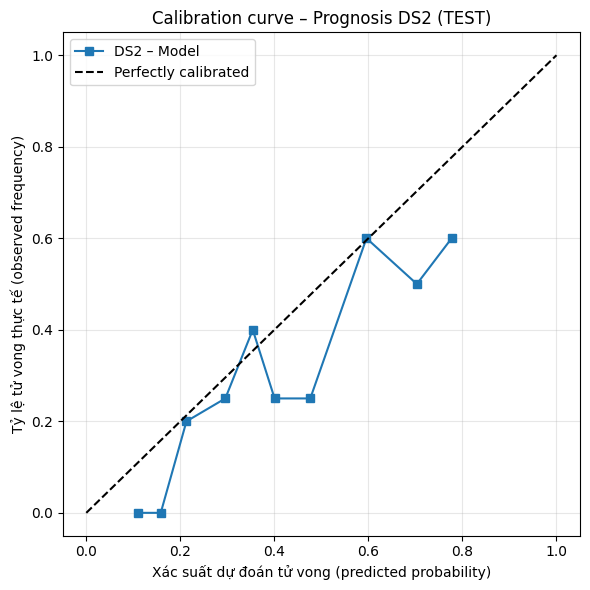

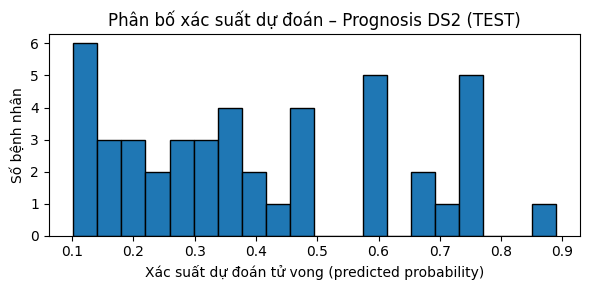

In [59]:
# ============================================================
# Step Y: Calibration cho mô hình Prognosis DS2
#   - Đánh giá calibration trên TEST: Brier + calibration curve + histogram
#   - (Tuỳ chọn) Calibration xác suất bằng Platt/Isotonic: fit trên VAL, evaluate trên TEST
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# ------------------------------------------------------------
# 0) Lấy xác suất dự đoán trên TEST từ best model DS2
# ------------------------------------------------------------
y2_proba_test = np.asarray(y2_test_proba).astype(float)  # proba class=1 trên TEST

if np.any(np.isnan(y2_proba_test)):
    raise ValueError("[DS2] y2_test_proba có NaN. Kiểm tra pipeline/model trước khi calibration.")

# ------------------------------------------------------------
# 1) Brier score (đánh giá độ tốt của xác suất)
# ------------------------------------------------------------
brier_ds2 = brier_score_loss(y2_test, y2_proba_test)
print(f"[DS2] Brier score (TEST) – càng thấp càng tốt: {brier_ds2:.4f}")

# ------------------------------------------------------------
# 2) Calibration curve data
# ------------------------------------------------------------
n_bins = 10
strategy = "quantile"

prob_true2, prob_pred2 = calibration_curve(
    y2_test, y2_proba_test, n_bins=n_bins, strategy=strategy
)

print(f"[DS2] Calibration curve: n_bins={n_bins}, strategy='{strategy}'")

# ------------------------------------------------------------
# 3) Plot calibration curve
# ------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.plot(prob_pred2, prob_true2, "s-", label="DS2 – Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Xác suất dự đoán tử vong (predicted probability)")
plt.ylabel("Tỷ lệ tử vong thực tế (observed frequency)")
plt.title("Calibration curve – Prognosis DS2 (TEST)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) Histogram phân bố xác suất
# ------------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.hist(y2_proba_test, bins=20, edgecolor="black")
plt.xlabel("Xác suất dự đoán tử vong (predicted probability)")
plt.ylabel("Số bệnh nhân")
plt.title("Phân bố xác suất dự đoán – Prognosis DS2 (TEST)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5) (Tuỳ chọn) Hiệu chỉnh xác suất (Calibration) bằng Platt/Isotonic
#     - Fit trên VAL, evaluate trên TEST
# ------------------------------------------------------------
DO_CALIBRATE = False  # đổi thành True nếu muốn calibrate

if DO_CALIBRATE:
    method = "sigmoid"  # hoặc "isotonic"

    calib2 = CalibratedClassifierCV(
        estimator=best_pipe_ds2,
        method=method,
        cv="prefit"  # best_pipe_ds2 đã fit trên TRAIN
    )

    # Fit calibrator trên VALIDATION
    calib2.fit(X2_val, y2_val)

    # Predict calibrated proba trên TEST
    y2_proba_test_cal = calib2.predict_proba(X2_test)[:, 1]

    brier_cal2 = brier_score_loss(y2_test, y2_proba_test_cal)
    print(f"[DS2] Brier score (TEST) sau calibration='{method}': {brier_cal2:.4f}")

    prob_true2_cal, prob_pred2_cal = calibration_curve(
        y2_test, y2_proba_test_cal, n_bins=n_bins, strategy=strategy
    )

    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred2, prob_true2, "s-", label="Before calibration")
    plt.plot(prob_pred2_cal, prob_true2_cal, "o-", label=f"After calibration ({method})")
    plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title("Calibration curve – DS2 (TEST)")
    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Step 6: Vẽ ROC / Confusion / Precision–Recall cho Dataset 2

In [60]:
# ============================================================
# Step 9 (DS2): Vẽ ROC, Confusion Matrix, Precision–Recall
#   - ROC/PR dùng proba (không phụ thuộc threshold)
#   - Confusion Matrix: so sánh threshold=0.5 vs tuned
#   - An toàn: confusion_matrix luôn 2x2 bằng labels=[0,1]
# ============================================================



# --------------------------
# ROC curve
# --------------------------
def plot_roc(y_true, y_proba, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_score = auc(fpr, tpr)

    print(f"[ROC] AUC = {auc_score:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], "k--", label="Random guess")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# --------------------------
# Confusion Matrix + Sens/Spec/BAcc
# --------------------------
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(4.5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred: 0", "Pred: 1"],
        yticklabels=["True: 0", "True: 1"],
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    balanced_acc = (specificity + sensitivity) / 2

    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"Sensitivity (Recall/TPR): {sensitivity:.4f}")
    print(f"Specificity (TNR)       : {specificity:.4f}")
    print(f"Balanced Accuracy       : {balanced_acc:.4f}")
    print("-" * 50)

# --------------------------
# Precision–Recall curve
# --------------------------
def plot_precision_recall(y_true, y_proba, title="Precision–Recall Curve"):
    precisions, recalls, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recalls, precisions)
    ap = average_precision_score(y_true, y_proba)

    print(f"[PR] PR-AUC = {pr_auc:.4f} | AP = {ap:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.3f}, AP = {ap:.3f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Apply for DS2
# ------------------------------------------------------------
y2_test_proba_best = best_pipe_ds2.predict_proba(X2_test)[:, 1]
model_label = best_model_label_ds2





[ROC] AUC = 0.7488


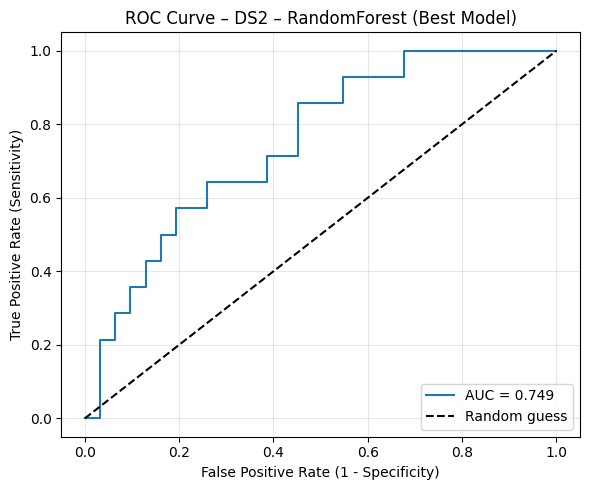

In [61]:
# ROC
plot_roc(
    y2_test,
    y2_test_proba_best,
    title=f"ROC Curve – DS2 – {model_label} (Best Model)"
)

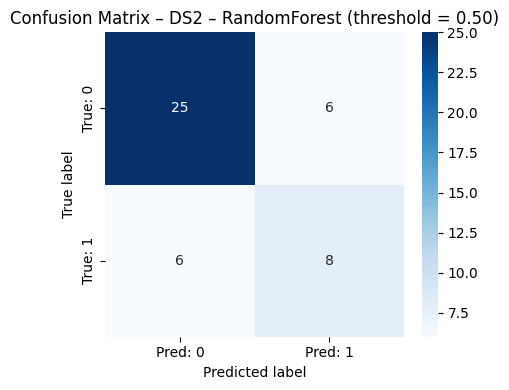

TN=25, FP=6, FN=6, TP=8
Sensitivity (Recall/TPR): 0.5714
Specificity (TNR)       : 0.8065
Balanced Accuracy       : 0.6889
--------------------------------------------------


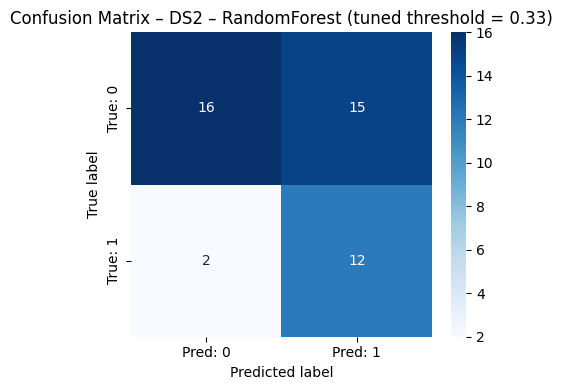

TN=16, FP=15, FN=2, TP=12
Sensitivity (Recall/TPR): 0.8571
Specificity (TNR)       : 0.5161
Balanced Accuracy       : 0.6866
--------------------------------------------------


In [62]:
# Confusion matrix: baseline 0.5
y2_test_pred_05 = (y2_test_proba_best >= 0.5).astype(int)
plot_confusion(
    y2_test,
    y2_test_pred_05,
    title=f"Confusion Matrix – DS2 – {model_label} (threshold = 0.50)"
)

# Confusion matrix: tuned threshold
y2_test_pred_tuned = (y2_test_proba_best >= best_th_ds2).astype(int)
plot_confusion(
    y2_test,
    y2_test_pred_tuned,
    title=f"Confusion Matrix – DS2 – {model_label} (tuned threshold = {best_th_ds2:.2f})"
)

[PR] PR-AUC = 0.5086 | AP = 0.5487


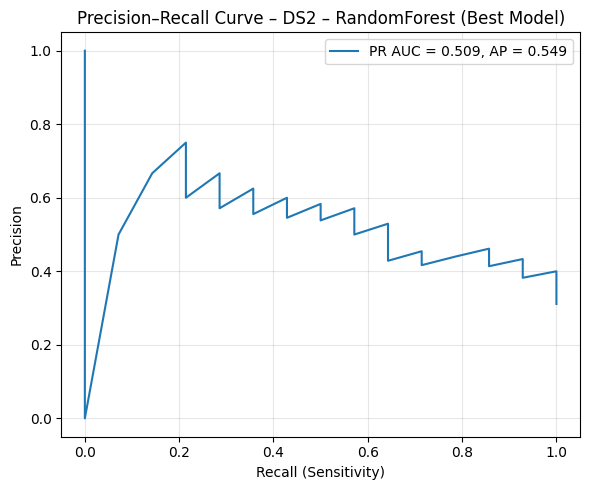

In [63]:
# PR
plot_precision_recall(
    y2_test,
    y2_test_proba_best,
    title=f"Precision–Recall Curve – DS2 – {model_label} (Best Model)"
)


### Step 7 : Giải thích mô hình Prognosis: Feature Importance & SHAP (Dataset 2)

[WARNING] Không lấy được tên từ OneHotEncoder; dùng tên categorical gốc.
Tổng số feature DS2: 11

Top 10 features (Permutation Importance – ROC-AUC):


ejection_fraction           0.088479
age                         0.062212
serum_sodium                0.021198
serum_creatinine            0.020507
smoking                     0.014747
sex                         0.013825
creatinine_phosphokinase    0.011982
high_blood_pressure         0.011290
platelets                   0.009793
diabetes                    0.003226
dtype: float64

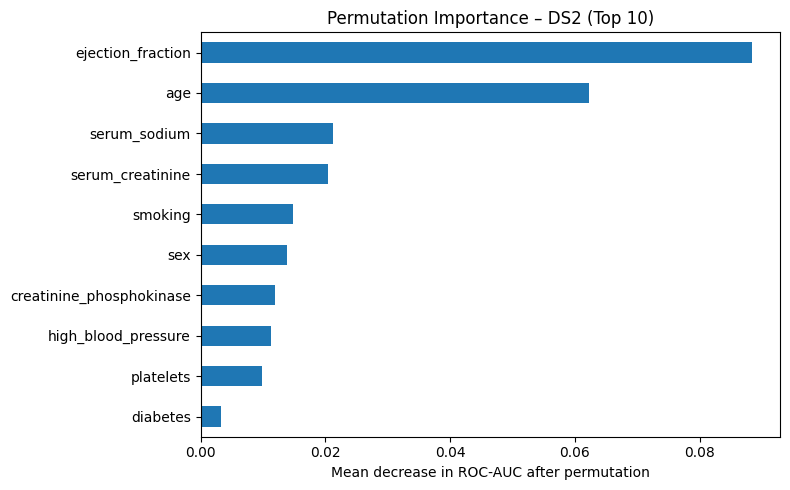

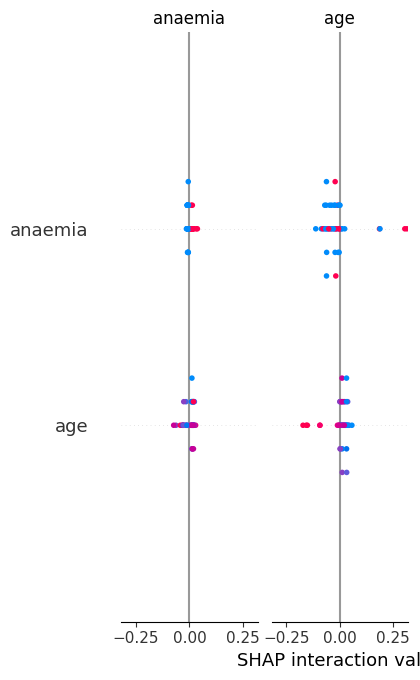

In [64]:
# ============================================================
# Step 8 (DS2): Giải thích mô hình – Permutation Importance & SHAP (ROBUST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy import sparse
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 0) Chọn model để giải thích

# ------------------------------------------------------------
pipe_explain = best_pipe_ds2  

pre2 = pipe_explain.named_steps["pre"]
clf2 = pipe_explain.named_steps["clf"]

# ------------------------------------------------------------
# 1) Lấy feature names sau preprocess theo đúng thứ tự
# ------------------------------------------------------------
feature_names2 = []
feature_names2.extend(list(numeric_cols2))

try:
    ohe2 = pre2.named_transformers_["cat"].named_steps["onehot"]
    ohe_feature_names2 = ohe2.get_feature_names_out(cat_cols2)
    feature_names2.extend(list(ohe_feature_names2))
except Exception:
    print("[WARNING] Không lấy được tên từ OneHotEncoder; dùng tên categorical gốc.")
    feature_names2.extend(list(cat_cols2))

print("Tổng số feature DS2:", len(feature_names2))

# ------------------------------------------------------------
# 2) Transform X_test sang space model train (giữ sparse nếu có)
# ------------------------------------------------------------
X2_test_trans = pre2.transform(X2_test)

assert X2_test_trans.shape[1] == len(feature_names2), (
    f"Số cột sau transform ({X2_test_trans.shape[1]}) "
    f"khác số feature_names ({len(feature_names2)})"
)

# ------------------------------------------------------------
# 3) Permutation Importance (theo ROC-AUC) trên space đã transform
# ------------------------------------------------------------
try:
    r2 = permutation_importance(
        estimator=clf2,
        X=X2_test_trans,
        y=y2_test,
        n_repeats=20,
        random_state=42,
        n_jobs=-1,
        scoring="roc_auc",
    )

    fi2 = pd.Series(r2.importances_mean, index=feature_names2).sort_values(ascending=False)

    print("\nTop 10 features (Permutation Importance – ROC-AUC):")
    display(fi2.head(10))

    plt.figure(figsize=(8, 5))
    fi2.head(10).sort_values().plot(kind="barh")
    plt.title("Permutation Importance – DS2 (Top 10)")
    plt.xlabel("Mean decrease in ROC-AUC after permutation")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Permutation importance failed DS2:", e)

# ------------------------------------------------------------
# 4) Chuẩn bị dữ liệu cho SHAP: sample trước khi densify (tránh nổ RAM)
# ------------------------------------------------------------
rng = np.random.RandomState(42)

max_shap_samples = 300
n_rows = X2_test_trans.shape[0]
idx = rng.choice(n_rows, min(max_shap_samples, n_rows), replace=False)
X_shap_trans = X2_test_trans[idx]

# densify sau khi sample
if sparse.issparse(X_shap_trans):
    X_shap = X_shap_trans.toarray()
else:
    X_shap = np.asarray(X_shap_trans)

# background nhỏ để tăng ổn định/tốc độ
bg_size = min(100, X_shap.shape[0])
bg_idx = rng.choice(X_shap.shape[0], bg_size, replace=False)
X_bg = X_shap[bg_idx]

# ------------------------------------------------------------
# 5) SHAP (ưu tiên): TreeExplainer cho tree-based
#    - Fix lỗi additivity: check_additivity=False
#    - Với LogisticRegression: dùng LinearExplainer
#    - Nếu fail: fallback PermutationExplainer
# ------------------------------------------------------------
def is_tree_model(estimator):
    return any(
        hasattr(estimator, attr) for attr in ["feature_importances_", "estimators_", "get_booster"]
    )

try:
    # shap.initjs()  # optional; có thể bật nếu notebook hỗ trợ JS

    if is_tree_model(clf2):
        # Tree-based (RF/CatBoost/XGB)
        explainer2 = shap.TreeExplainer(clf2, data=X_bg)
        shap_vals2 = explainer2.shap_values(X_shap, check_additivity=False)

        # classifier thường trả list theo class
        if isinstance(shap_vals2, list):
            shap_vals2 = shap_vals2[1]  # class=1

        shap.summary_plot(
            shap_vals2,
            X_shap,
            feature_names=feature_names2,
            plot_type="dot",
            show=True
        )

    else:
        # Linear model (LogisticRegression, etc.)
        explainer2 = shap.LinearExplainer(clf2, X_bg)
        shap_vals2 = explainer2.shap_values(X_shap)

        shap.summary_plot(
            shap_vals2,
            X_shap,
            feature_names=feature_names2,
            plot_type="dot",
            show=True
        )

except Exception as e:
    print("[WARNING] SHAP Tree/Linear explainer failed, fallback to PermutationExplainer. Error:", e)

    try:
        # Model-agnostic fallback (chậm hơn)
        def f(X):
            X = np.asarray(X)
            return clf2.predict_proba(X)[:, 1]

        explainer_perm2 = shap.PermutationExplainer(f, X_bg)
        shap_values_perm2 = explainer_perm2(X_shap, max_evals=1000)

        shap.summary_plot(
            shap_values_perm2,
            X_shap,
            feature_names=feature_names2,
            plot_type="dot",
            show=True
        )

    except Exception as e2:
        print("SHAP fallback PermutationExplainer failed DS2:", e2)


### Step 8: Đánh giá fairness

In [65]:
# ============================================================
# Step F (DS2): FAIRNESS EVALUATION (Sex + AgeGroup)
#   - 2 thresholds: 0.50 (baseline) và best_th_ds2 (tuned)
#   - Grouping: Sex và AgeGroup (tạo trên df_eval, KHÔNG sửa df2 gốc)
#   - Output: bảng metrics theo group + bảng disparity (max-min)
# ============================================================


# -----------------------------
# 1) Xác định cột Sex và Age
# -----------------------------
sex_candidates = [c for c in df2.columns if "sex" in c.lower()]
age_candidates = [c for c in df2.columns if c.lower() == "age" or "age" in c.lower()]

sex_col = sex_candidates[0] if sex_candidates else None
age_col = age_candidates[0] if age_candidates else None

if sex_col is None:
    print("[-] Không tìm thấy cột sex trong df2.")
if age_col is None:
    print("[-] Không tìm thấy cột age trong df2.")

if sex_col is None and age_col is None:
    print("\nKHÔNG có cột nào để đánh giá fairness cho DS2.")
else:
    fairness_cols = []
    group_label_map = {}

    if sex_col is not None:
        fairness_cols.append("Sex")
        group_label_map["Sex"] = "Sex"

    if age_col is not None:
        fairness_cols.append("AgeGroup")
        group_label_map["AgeGroup"] = "AgeGroup"

    print("[*] Sẽ đánh giá fairness theo:", fairness_cols)

    # -----------------------------
    # 2) Predict trên TEST ở 2 threshold
    # -----------------------------
    y2_test_proba = best_pipe_ds2.predict_proba(X2_test)[:, 1]
    y2_pred_05 = (y2_test_proba >= 0.5).astype(int)
    y2_pred_tuned = (y2_test_proba >= best_th_ds2).astype(int)

    # -----------------------------
    # 3) Tạo df_eval trên TEST (không sửa df2 gốc)
    # -----------------------------
    df2_eval = pd.DataFrame(index=X2_test.index)
    df2_eval["y_true"] = np.asarray(y2_test)
    df2_eval["y_pred_05"] = y2_pred_05
    df2_eval["y_pred_tuned"] = y2_pred_tuned

    # Gắn Sex
    if sex_col is not None:
        df2_eval["Sex"] = df2.loc[X2_test.index, sex_col].astype("object")
        df2_eval["Sex"] = df2_eval["Sex"].fillna("Unknown")

    # Tạo AgeGroup từ age (trên test set)
    if age_col is not None:
        df2_eval["Age"] = pd.to_numeric(df2.loc[X2_test.index, age_col], errors="coerce")
        # Fill missing age để không mất row khi cut
        df2_eval["Age"] = df2_eval["Age"].fillna(df2_eval["Age"].median())

        df2_eval["AgeGroup"] = pd.cut(
            df2_eval["Age"],
            bins=[0, 60, 75, 150],
            labels=["<60", "60–75", ">75"],
            right=True,
            include_lowest=True,
        ).astype("object").fillna("Unknown")

    # -----------------------------
    # 4) Hàm tính metrics theo group
    # -----------------------------
    def compute_group_metrics(df_eval, group_col, pred_col, th_label):
        rows = []
        for g, d in df_eval.groupby(group_col, dropna=False):
            cm = confusion_matrix(d["y_true"], d[pred_col], labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()

            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # Recall/Sensitivity
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # Specificity
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
            pos_rate = float(np.mean(d[pred_col]))

            rows.append({
                "Group by": group_label_map.get(group_col, group_col),
                "Group": g,
                "Threshold": th_label,
                "N": int(len(d)),
                "Accuracy": float(accuracy_score(d["y_true"], d[pred_col])),
                "Positive Rate (Pred=1)": pos_rate,
                "TPR (Recall/Sensitivity)": float(tpr),
                "TNR (Specificity)": float(tnr),
                "FPR": float(fpr),
                "FNR": float(fnr),
                "Balanced Accuracy": float((tpr + tnr) / 2),
                "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
            })
        return pd.DataFrame(rows)

    # -----------------------------
    # 5) Tính fairness tables cho Sex/AgeGroup ở 2 thresholds
    # -----------------------------
    all_tables = []

    for group_col in fairness_cols:
        tab_05 = compute_group_metrics(df2_eval, group_col, "y_pred_05", "0.50 (baseline)")
        tab_tuned = compute_group_metrics(df2_eval, group_col, "y_pred_tuned", f"{best_th_ds2:.2f} (tuned)")
        tab = pd.concat([tab_05, tab_tuned], ignore_index=True)

        print(f"\n=== FAIRNESS DS2 theo {group_col} ===")
        display(tab)

        all_tables.append(tab)

    fairness_all_ds2 = pd.concat(all_tables, ignore_index=True)
    print("\n=== TỔNG HỢP FAIRNESS DS2 (Sex + AgeGroup) ===")
    display(fairness_all_ds2)

    # -----------------------------
    # 6) Bảng disparity (max-min) theo từng group_col và threshold
    # -----------------------------
    def disparity_table(fair_df):
        metrics = ["Positive Rate (Pred=1)", "TPR (Recall/Sensitivity)", "FPR"]
        rows = []
        for (gb, th), d in fair_df.groupby(["Group by", "Threshold"]):
            row = {"Group by": gb, "Threshold": th}
            for m in metrics:
                row[f"{m} (max-min)"] = float(d[m].max() - d[m].min()) if len(d) > 1 else 0.0
            rows.append(row)
        return pd.DataFrame(rows)

    disp_ds2 = disparity_table(fairness_all_ds2)
    print("\n=== DISPARITY (max-min) – DS2 (càng nhỏ càng tốt) ===")
    display(disp_ds2)


[*] Sẽ đánh giá fairness theo: ['Sex', 'AgeGroup']

=== FAIRNESS DS2 theo Sex ===


,Group by,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),TPR (Recall/Sensitivity),TNR (Specificity),FPR,FNR,Balanced Accuracy,TN,FP,FN,TP
0,Sex,0,0.50 (baseline),16,0.750000,0.250000,0.500000,0.900000,0.100000,0.500000,0.700000,9,1,3,3
1,Sex,1,0.50 (baseline),29,0.724138,0.344828,0.625000,0.761905,0.238095,0.375000,0.693452,16,5,3,5
2,Sex,0,0.33 (tuned),16,0.750000,0.500000,0.833333,0.700000,0.300000,0.166667,0.766667,7,3,1,5
3,Sex,1,0.33 (tuned),29,0.551724,0.655172,0.875000,0.428571,0.571429,0.125000,0.651786,9,12,1,7



=== FAIRNESS DS2 theo AgeGroup ===


,Group by,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),TPR (Recall/Sensitivity),TNR (Specificity),FPR,FNR,Balanced Accuracy,TN,FP,FN,TP
0,AgeGroup,60–75,0.50 (baseline),11,0.818182,0.181818,0.500000,1.000000,0.000000,0.500000,0.750000,7,0,2,2
1,AgeGroup,<60,0.50 (baseline),29,0.793103,0.310345,0.714286,0.818182,0.181818,0.285714,0.766234,18,4,2,5
2,AgeGroup,>75,0.50 (baseline),5,0.200000,0.600000,0.333333,0.000000,1.000000,0.666667,0.166667,0,2,2,1
3,AgeGroup,60–75,0.33 (tuned),11,0.636364,0.545455,0.750000,0.571429,0.428571,0.250000,0.660714,4,3,1,3
4,AgeGroup,<60,0.33 (tuned),29,0.620690,0.551724,0.857143,0.545455,0.454545,0.142857,0.701299,12,10,1,6
5,AgeGroup,>75,0.33 (tuned),5,0.600000,1.000000,1.000000,0.000000,1.000000,0.000000,0.500000,0,2,0,3



=== TỔNG HỢP FAIRNESS DS2 (Sex + AgeGroup) ===


,Group by,Group,Threshold,N,Accuracy,Positive Rate (Pred=1),TPR (Recall/Sensitivity),TNR (Specificity),FPR,FNR,Balanced Accuracy,TN,FP,FN,TP
0,Sex,0,0.50 (baseline),16,0.750000,0.250000,0.500000,0.900000,0.100000,0.500000,0.700000,9,1,3,3
1,Sex,1,0.50 (baseline),29,0.724138,0.344828,0.625000,0.761905,0.238095,0.375000,0.693452,16,5,3,5
2,Sex,0,0.33 (tuned),16,0.750000,0.500000,0.833333,0.700000,0.300000,0.166667,0.766667,7,3,1,5
3,Sex,1,0.33 (tuned),29,0.551724,0.655172,0.875000,0.428571,0.571429,0.125000,0.651786,9,12,1,7
4,AgeGroup,60–75,0.50 (baseline),11,0.818182,0.181818,0.500000,1.000000,0.000000,0.500000,0.750000,7,0,2,2
5,AgeGroup,<60,0.50 (baseline),29,0.793103,0.310345,0.714286,0.818182,0.181818,0.285714,0.766234,18,4,2,5
6,AgeGroup,>75,0.50 (baseline),5,0.200000,0.600000,0.333333,0.000000,1.000000,0.666667,0.166667,0,2,2,1
7,AgeGroup,60–75,0.33 (tuned),11,0.636364,0.545455,0.750000,0.571429,0.428571,0.250000,0.660714,4,3,1,3
8,AgeGroup,<60,0.33 (tuned),29,0.620690,0.551724,0.857143,0.545455,0.454545,0.142857,0.701299,12,10,1,6
9,AgeGroup,>75,0.33 (tuned),5,0.600000,1.000000,1.000000,0.000000,1.000000,0.000000,0.500000,0,2,0,3



=== DISPARITY (max-min) – DS2 (càng nhỏ càng tốt) ===


,Group by,Threshold,Positive Rate (Pred=1) (max-min),TPR (Recall/Sensitivity) (max-min),FPR (max-min)
0,AgeGroup,0.33 (tuned),0.454545,0.250000,0.571429
1,AgeGroup,0.50 (baseline),0.418182,0.380952,1.000000
2,Sex,0.33 (tuned),0.155172,0.041667,0.271429
3,Sex,0.50 (baseline),0.094828,0.125000,0.138095


## Phân tầng nguy cơ tử vong

### Step 1: Tính xác suất tử vong dự đoán cho train / val / test

In [66]:


# 1.1. Tính xác suất tử vong (DEATH_EVENT = 1) cho từng split
y2_train_proba = best_pipe_ds2.predict_proba(X2_train)[:, 1]
y2_val_proba   = best_pipe_ds2.predict_proba(X2_val)[:, 1]
y2_test_proba  = best_pipe_ds2.predict_proba(X2_test)[:, 1]

# 1.2. Tạo DataFrame tiện phân tích
df_train_prognosis = pd.DataFrame({
    "proba_death": y2_train_proba,
    "DEATH_EVENT": y2_train.reset_index(drop=True)
})

df_val_prognosis = pd.DataFrame({
    "proba_death": y2_val_proba,
    "DEATH_EVENT": y2_val.reset_index(drop=True)
})

df_test_prognosis = pd.DataFrame({
    "proba_death": y2_test_proba,
    "DEATH_EVENT": y2_test.reset_index(drop=True)
})

df_train_prognosis.head()


,proba_death,DEATH_EVENT
0,0.521761,1
1,0.316553,0
2,0.400522,0
3,0.127347,0
4,0.263869,0


### Step 2: Xác định ngưỡng chia nhóm nguy cơ (Low / Medium / High)

In [67]:
# 2.1. Tính ngưỡng phân vị 1/3 và 2/3 trên TRAIN
q1, q2 = np.quantile(df_train_prognosis["proba_death"], [1/3, 2/3])

print("Ngưỡng phân tầng nguy cơ (theo TRAIN):")
print(f"  Low  / Medium:  q1 = {q1:.4f}")
print(f"  Medium / High: q2 = {q2:.4f}")


Ngưỡng phân tầng nguy cơ (theo TRAIN):
  Low  / Medium:  q1 = 0.2064
  Medium / High: q2 = 0.5191


### Step 3: Hàm gán nhóm nguy cơ dựa trên xác suất

In [68]:
# 3. Hàm gán nhóm nguy cơ
def assign_risk_group_from_proba(p, q1, q2):
    """
    p : xác suất tử vong dự đoán (0–1)
    q1, q2 : ngưỡng phân vị trên tập TRAIN
    """
    if p < q1:
        return "Low"
    elif p < q2:
        return "Medium"
    else:
        return "High"


### Step 4: Gán nhóm nguy cơ cho train / val / test

In [69]:
# 4.1. Gán nhóm nguy cơ cho từng DataFrame
df_train_prognosis["RiskGroup_Prognosis"] = df_train_prognosis["proba_death"].apply(
    lambda p: assign_risk_group_from_proba(p, q1, q2)
)
df_val_prognosis["RiskGroup_Prognosis"] = df_val_prognosis["proba_death"].apply(
    lambda p: assign_risk_group_from_proba(p, q1, q2)
)
df_test_prognosis["RiskGroup_Prognosis"] = df_test_prognosis["proba_death"].apply(
    lambda p: assign_risk_group_from_proba(p, q1, q2)
)

# 4.2. Đảm bảo thứ tự nhóm là Low < Medium < High khi sort / vẽ
order = ["Low", "Medium", "High"]
for df in [df_train_prognosis, df_val_prognosis, df_test_prognosis]:
    df["RiskGroup_Prognosis"] = pd.Categorical(
        df["RiskGroup_Prognosis"],
        categories=order,
        ordered=True
    )

df_train_prognosis.head()


,proba_death,DEATH_EVENT,RiskGroup_Prognosis
0,0.521761,1,High
1,0.316553,0,Medium
2,0.400522,0,Medium
3,0.127347,0,Low
4,0.263869,0,Medium


### Step 5: Hàm tóm tắt tỷ lệ tử vong theo nhóm nguy cơ

In [70]:
# 5. Hàm tóm tắt n, số tử vong, tỷ lệ tử vong theo nhóm
def summarize_prognosis_risk_groups(df, label_col="DEATH_EVENT", group_col="RiskGroup_Prognosis"):
    """
    Trả về bảng:
        n, deaths, death_rate cho từng nhóm nguy cơ
    """
    summary = (
        df.groupby(group_col)[label_col]
          .agg(["count", "sum"])
          .rename(columns={"count": "n", "sum": "deaths"})
          .reset_index()
    )
    summary["death_rate"] = summary["deaths"] / summary["n"]
    return summary


### Step 6: Bảng kết quả phân tầng nguy cơ trên train / val / test

In [71]:
print("=== Phân tầng nguy cơ tử vong – TRAIN ===")
summary_train = summarize_prognosis_risk_groups(df_train_prognosis)
display(summary_train)

print("=== Phân tầng nguy cơ tử vong – VAL ===")
summary_val = summarize_prognosis_risk_groups(df_val_prognosis)
display(summary_val)

print("=== Phân tầng nguy cơ tử vong – TEST ===")
summary_test = summarize_prognosis_risk_groups(df_test_prognosis)
display(summary_test)


=== Phân tầng nguy cơ tử vong – TRAIN ===


,RiskGroup_Prognosis,n,deaths,death_rate
0,Low,70,0,0.000000
1,Medium,69,8,0.115942
2,High,70,59,0.842857


=== Phân tầng nguy cơ tử vong – VAL ===


,RiskGroup_Prognosis,n,deaths,death_rate
0,Low,8,0,0.000000
1,Medium,21,4,0.190476
2,High,16,11,0.687500


=== Phân tầng nguy cơ tử vong – TEST ===


,RiskGroup_Prognosis,n,deaths,death_rate
0,Low,11,1,0.090909
1,Medium,20,5,0.250000
2,High,14,8,0.571429


### Step 7: Kiểm tra đơn điệu (monotonicity) đơn giản

In [72]:
def check_monotonic_death_rate(summary_df, group_col="RiskGroup_Prognosis"):
    tmp = summary_df.sort_values(group_col)
    rates = tmp["death_rate"].values
    is_monotone = np.all(np.diff(rates) >= -1e-8)  # cho phép sai số số học rất nhỏ
    return is_monotone, rates

print("=== Monotonic check – TRAIN ===")
mono_train, rates_train = check_monotonic_death_rate(summary_train)
print("Death rates Low/Medium/High:", rates_train)
print("Monotonic (Low ≤ Medium ≤ High):", mono_train)

print("\n=== Monotonic check – TEST ===")
mono_test, rates_test = check_monotonic_death_rate(summary_test)
print("Death rates Low/Medium/High:", rates_test)
print("Monotonic (Low ≤ Medium ≤ High):", mono_test)


=== Monotonic check – TRAIN ===
Death rates Low/Medium/High: [0.         0.11594203 0.84285714]
Monotonic (Low ≤ Medium ≤ High): True

=== Monotonic check – TEST ===
Death rates Low/Medium/High: [0.09090909 0.25       0.57142857]
Monotonic (Low ≤ Medium ≤ High): True


### Step 8: Vẽ biểu đồ cột tỷ lệ tử vong theo nhóm

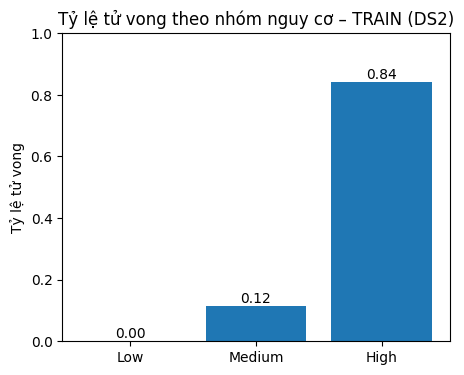

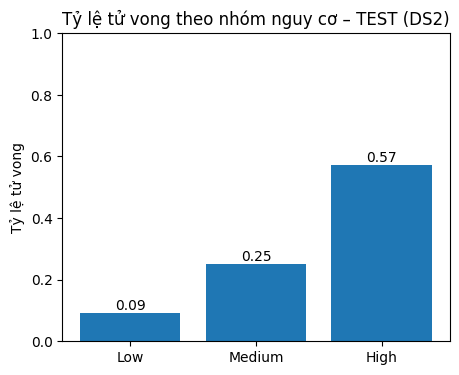

In [73]:
# 7. Vẽ biểu đồ tỷ lệ tử vong theo nhóm nguy cơ

def plot_death_rate_by_group(summary_df, title):
    groups = summary_df["RiskGroup_Prognosis"].astype(str)
    rates = summary_df["death_rate"]

    plt.figure(figsize=(5, 4))
    plt.bar(groups, rates)
    plt.ylabel("Tỷ lệ tử vong")
    plt.ylim(0, 1)
    plt.title(title)
    for i, v in enumerate(rates):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
    plt.show()

plot_death_rate_by_group(summary_train, "Tỷ lệ tử vong theo nhóm nguy cơ – TRAIN (DS2)")
plot_death_rate_by_group(summary_test,  "Tỷ lệ tử vong theo nhóm nguy cơ – TEST (DS2)")


# Risk Core

## Step 1: CONFIG

In [ ]:
LABEL_DS1 = "HeartDisease"
LABEL_DS2 = "DEATH_EVENT"

# Proxy rules on DS1 (must be documented in report)
HYPERTENSION_RBP_THRESHOLD = 140  # RestingBP >= 140 => Hypertension=1
# Diabetes proxy: FastingBS == 1 (often indicates elevated fasting glucose)

# Bridge risk variables (DS1 naming) mapped from DS2
RISK_VAR_MAP_DS1_to_DS2 = {
    "Age": "age",
    "Sex": "sex",
    "Hypertension": "high_blood_pressure",
    "Diabetes": "diabetes",
}

# output dir
try:
    MODEL_DIR  # noqa: F821
except NameError:
    MODEL_DIR = "models"

MODEL_DIR = Path(MODEL_DIR)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


## Step 2: HELPERS (index-safe, normalization, grouping, CI)

In [ ]:
def ensure_series_with_index(y, index, name="y"):
    """Ensure y is a pandas Series aligned to given index."""
    if isinstance(y, pd.Series):
        # enforce alignment & order
        y_aligned = y.loc[index]
        return y_aligned
    # create series with exact index
    return pd.Series(y, index=index, name=name)

def normalize_sex_to_match_ds1(ds1_sex: pd.Series, ds2_sex: pd.Series) -> pd.Series:
    """
    Normalize ds2_sex to match the "style" of ds1_sex.
    - If DS1 Sex is numeric -> DS2 output numeric 0/1
    - If DS1 Sex is string/categorical -> DS2 output as "M/F" or "Male/Female"
      Assumption for DS2 HF dataset (common): 1=Male, 0=Female when numeric.
    """
    s1 = ds1_sex.dropna()
    s2 = ds2_sex.copy()

    # DS1 numeric?
    ds1_is_numeric = pd.api.types.is_numeric_dtype(s1)
    if ds1_is_numeric:
        if pd.api.types.is_numeric_dtype(s2):
            return s2.astype(float).round().astype("Int64")
        # map strings
        m = s2.astype(str).str.lower().map({"m": 1, "male": 1, "f": 0, "female": 0})
        return m.astype("Int64")

    # DS1 is categorical/string
    ds1_vals = set(s1.astype(str).str.strip().str.lower().unique())
    use_male_female = any(v in ds1_vals for v in ["male", "female"])
    # default: M/F
    if pd.api.types.is_numeric_dtype(s2):
        if use_male_female:
            return s2.astype(int).map({1: "Male", 0: "Female"})
        return s2.astype(int).map({1: "M", 0: "F"})

    s2_l = s2.astype(str).str.strip().str.lower()
    if use_male_female:
        return s2_l.map({"m": "Male", "male": "Male", "f": "Female", "female": "Female"})
    return s2_l.map({"m": "M", "male": "M", "f": "F", "female": "F"})

def make_3group_cutpoints(scores: pd.Series) -> np.ndarray:
    """Return 4 cutpoints for 3 groups using terciles, with fallback if duplicates exist."""
    qs = scores.quantile([0, 1/3, 2/3, 1]).values
    qs = np.unique(qs)
    if len(qs) < 4:
        mn, mx = float(scores.min()), float(scores.max())
        qs = np.linspace(mn, mx, 4)
    return qs

def apply_risk_group(scores: pd.Series, cutpoints: np.ndarray) -> pd.Series:
    labels = ["Low", "Medium", "High"]
    return pd.cut(scores, bins=cutpoints, labels=labels[:len(cutpoints)-1], include_lowest=True)

def bootstrap_auc_ci(y_true, y_score, n_boot=1000, seed=42, alpha=0.95):
    """Bootstrap CI for AUC (optional but recommended)."""
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    n = len(y_true)

    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        # must contain both classes
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    if len(aucs) == 0:
        return None

    aucs = np.sort(aucs)
    lo = np.percentile(aucs, (1 - alpha) / 2 * 100)
    hi = np.percentile(aucs, (1 + alpha) / 2 * 100)
    return float(lo), float(hi)

## Step 3: BUILD DS1_FOR_RISK (create proxies on DS1)

In [ ]:
df1_for_risk = df1.copy()

# label presence
if LABEL_DS1 not in df1_for_risk.columns:
    raise ValueError(f"DS1 label '{LABEL_DS1}' not found in df1.")

# Hypertension proxy
if "Hypertension" not in df1_for_risk.columns:
    if "RestingBP" in df1_for_risk.columns:
        df1_for_risk["Hypertension"] = (df1_for_risk["RestingBP"] >= HYPERTENSION_RBP_THRESHOLD).astype(int)
    else:
        df1_for_risk["Hypertension"] = np.nan

# Diabetes proxy
if "Diabetes" not in df1_for_risk.columns:
    if "FastingBS" in df1_for_risk.columns:
        df1_for_risk["Diabetes"] = (df1_for_risk["FastingBS"].astype(float) == 1.0).astype(int)
    else:
        df1_for_risk["Diabetes"] = np.nan

# sanity: proxy rates
if "Hypertension" in df1_for_risk.columns and not df1_for_risk["Hypertension"].isna().all():
    print(f">>> [DS1] Hypertension proxy rate: {df1_for_risk['Hypertension'].mean():.3f}")
if "Diabetes" in df1_for_risk.columns and not df1_for_risk["Diabetes"].isna().all():
    print(f">>> [DS1] Diabetes proxy rate    : {df1_for_risk['Diabetes'].mean():.3f}")


>>> [DS1] Hypertension proxy rate: 0.356
>>> [DS1] Diabetes proxy rate    : 0.233


## Step 4:  BUILD DS2_FOR_RISK (map DS2 to DS1 naming + Sex harmonization)

In [ ]:
# ============================================================
# 3) BUILD DS2_FOR_RISK (map DS2 to DS1 naming + Sex harmonization)
# ============================================================
df2_for_risk = df2.copy()

# label presence (for evaluation)
if LABEL_DS2 not in df2_for_risk.columns:
    raise ValueError(f"DS2 label '{LABEL_DS2}' not found in df2.")

# copy/rename DS2 cols -> DS1 names
for ds1_name, ds2_name in RISK_VAR_MAP_DS1_to_DS2.items():
    if ds2_name in df2_for_risk.columns and ds1_name not in df2_for_risk.columns:
        df2_for_risk[ds1_name] = df2_for_risk[ds2_name]

# sex harmonization (if both exist)
if "Sex" in df1_for_risk.columns and "Sex" in df2_for_risk.columns:
    # quick schema check
    if "sex" in df2.columns:
        print(">>> [DS2] raw sex unique:", sorted(pd.Series(df2["sex"]).dropna().unique().tolist())[:10])
    df2_for_risk["Sex"] = normalize_sex_to_match_ds1(df1_for_risk["Sex"], df2_for_risk["Sex"])


>>> [DS2] raw sex unique: [0, 1]


## Step 5:  SELECT AVAILABLE RISK VARS (present & not all-NaN)

In [ ]:
# ============================================================
# 4) SELECT AVAILABLE RISK VARS (present & not all-NaN)
# ============================================================
available_risk_vars = []
missing_ds1 = []
missing_ds2 = []

for ds1_name, _ds2_name in RISK_VAR_MAP_DS1_to_DS2.items():
    if ds1_name in df1_for_risk.columns and ds1_name in df2_for_risk.columns:
        if df1_for_risk[ds1_name].isna().all():
            missing_ds1.append(ds1_name + " (all NaN/proxy not built)")
            continue
        if df2_for_risk[ds1_name].isna().all():
            missing_ds2.append(ds1_name + " (all NaN)")
            continue
        available_risk_vars.append(ds1_name)
    else:
        if ds1_name not in df1_for_risk.columns:
            missing_ds1.append(ds1_name)
        if ds1_name not in df2_for_risk.columns:
            missing_ds2.append(ds1_name)

print(">>> Risk vars used (DS1 & DS2):", available_risk_vars)
if missing_ds1:
    print(">>> Missing/unused in DS1:", missing_ds1)
if missing_ds2:
    print(">>> Missing/unused in DS2:", missing_ds2)

if len(available_risk_vars) == 0:
    raise ValueError("No shared risk variables available. Check mapping and column names.")

if len(available_risk_vars) < 3:
    print("[WARNING] <3 risk vars. Bridge may be weak / less meaningful.")

>>> Risk vars used (DS1 & DS2): ['Age', 'Sex', 'Hypertension', 'Diabetes']


## Step 6: BUILD DS1 RISK DATA USING SPLIT INDICES (robust)

In [ ]:
# ============================================================
# 5) BUILD DS1 RISK DATA USING SPLIT INDICES (robust)
# ============================================================
# Align y with X indices (critical)
y1_train = ensure_series_with_index(y1_train, X1_train.index, name="y1_train")
y1_val   = ensure_series_with_index(y1_val,   X1_val.index,   name="y1_val")
y1_test  = ensure_series_with_index(y1_test,  X1_test.index,  name="y1_test")

X1_train_risk = df1_for_risk.loc[X1_train.index, available_risk_vars].copy()
X1_val_risk   = df1_for_risk.loc[X1_val.index,   available_risk_vars].copy()
X1_test_risk  = df1_for_risk.loc[X1_test.index,  available_risk_vars].copy()

X1_train_full_risk = pd.concat([X1_train_risk, X1_val_risk], axis=0)
y1_train_full      = pd.concat([y1_train,      y1_val],     axis=0)

## Step 7:  BUILD PREPROCESSING FOR RISK MODEL (dynamic types)

In [ ]:
# ============================================================
# 6) BUILD PREPROCESSING FOR RISK MODEL (dynamic types)
#   - Age: numeric scaled
#   - Binary numeric (0/1): impute most_frequent
#   - Categorical: impute + one-hot
# ============================================================
risk_num = [c for c in available_risk_vars if c.lower() == "age"]

risk_bin = []
for c in available_risk_vars:
    if c in risk_num:
        continue
    if pd.api.types.is_numeric_dtype(X1_train_risk[c]):
        nunique = X1_train_risk[c].dropna().nunique()
        if nunique <= 2:
            risk_bin.append(c)

risk_cat = [c for c in available_risk_vars if (c not in risk_num and c not in risk_bin)]

print(">>> Risk numeric cols:", risk_num)
print(">>> Risk binary cols :", risk_bin)
print(">>> Risk cat cols    :", risk_cat)

num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

bin_tf = SimpleImputer(strategy="most_frequent")

cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

transformers = []
if risk_num:
    transformers.append(("num", num_tf, risk_num))
if risk_bin:
    transformers.append(("bin", bin_tf, risk_bin))
if risk_cat:
    transformers.append(("cat", cat_tf, risk_cat))

pre_risk = ColumnTransformer(transformers=transformers, remainder="drop")

risk_lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs",
)

risk_pipe = Pipeline([
    ("pre", pre_risk),
    ("clf", risk_lr),
])

>>> Risk numeric cols: ['Age']
>>> Risk binary cols : ['Hypertension', 'Diabetes']
>>> Risk cat cols    : ['Sex']


## Step 8: TRAIN RISK MODEL ON DS1 TRAIN + EVALUATE (CV mean±std + train/val/test)

In [ ]:
# ============================================================
# 7) TRAIN RISK MODEL ON DS1 TRAIN + EVALUATE (CV mean±std + train/val/test)
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(
    risk_pipe,
    X1_train_risk,
    y1_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
print(f">>> [RiskScore-DS1] CV AUC (mean ± std): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

risk_pipe.fit(X1_train_risk, y1_train)

def auc_eval(pipe, X, y, name):
    p = pipe.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, p)
    print(f">>> [RiskScore-DS1] AUC on {name}: {auc:.4f}")
    return float(auc), p

auc_train, _ = auc_eval(risk_pipe, X1_train_risk, y1_train, "TRAIN")
auc_val,   _ = auc_eval(risk_pipe, X1_val_risk,   y1_val,   "VAL")
auc_test,  _ = auc_eval(risk_pipe, X1_test_risk,  y1_test,  "TEST")


>>> [RiskScore-DS1] CV AUC (mean ± std): 0.7422 ± 0.0290
>>> [RiskScore-DS1] AUC on TRAIN: 0.7455
>>> [RiskScore-DS1] AUC on VAL: 0.7510
>>> [RiskScore-DS1] AUC on TEST: 0.8407


## Step 9: FIT FINAL RISK MODEL ON DS1 TRAIN+VAL

In [ ]:
# ============================================================
# 8) FIT FINAL RISK MODEL ON DS1 TRAIN+VAL
# ============================================================
risk_pipe_final = Pipeline([
    ("pre", pre_risk),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
    )),
])
risk_pipe_final.fit(X1_train_full_risk, y1_train_full)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Step 10: EXPORT COEFFICIENTS + ODDS RATIO (interpretability)

In [ ]:
# ============================================================
# 9) EXPORT COEFFICIENTS + ODDS RATIO (interpretability)
# ============================================================
pre_final = risk_pipe_final.named_steps["pre"]
clf_final = risk_pipe_final.named_steps["clf"]

feat_names = pre_final.get_feature_names_out()
coef = clf_final.coef_[0]

coef_df = pd.DataFrame({"feature": feat_names, "coef": coef})
coef_df["OR"] = np.exp(coef_df["coef"])
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("\n=== RiskScore Logistic Coef + OR (Top 20 by |coef|) ===")
display(coef_df[["feature", "coef", "OR"]].head(20))


=== RiskScore Logistic Coef + OR (Top 20 by |coef|) ===


,feature,coef,OR
0,bin__Diabetes,1.106879,3.024904
1,cat__Sex_M,0.684349,1.982481
2,cat__Sex_F,-0.679254,0.506995
3,num__Age,0.492607,1.636577
4,bin__Hypertension,0.237122,1.267596


## Step 11: COMPUTE RISK SCORE FOR ALL DS1 & DS2

In [ ]:
# ============================================================
# 10) COMPUTE RISK SCORE FOR ALL DS1 & DS2
# ============================================================
X1_all_risk = df1_for_risk[available_risk_vars].copy()
df1_for_risk["RiskScore_DS1"] = risk_pipe_final.predict_proba(X1_all_risk)[:, 1]

X2_all_risk = df2_for_risk[available_risk_vars].copy()
df2_for_risk["RiskScore_DS2"] = risk_pipe_final.predict_proba(X2_all_risk)[:, 1]

# write back to originals (optional)
df1["RiskScore_DS1"] = df1_for_risk["RiskScore_DS1"].values
df2["RiskScore_DS2"] = df2_for_risk["RiskScore_DS2"].values

print("\n>>> RiskScore_DS1 describe:")
display(df1["RiskScore_DS1"].describe())

print("\n>>> RiskScore_DS2 describe:")
display(df2["RiskScore_DS2"].describe())


>>> RiskScore_DS1 describe:


count    918.000000
mean       0.506262
std        0.209365
min        0.071186
25%        0.348834
50%        0.513409
75%        0.649863
max        0.919185
Name: RiskScore_DS1, dtype: float64


>>> RiskScore_DS2 describe:


count    299.000000
mean       0.585141
std        0.204664
min        0.109124
25%        0.441119
50%        0.576791
75%        0.768154
max        0.968360
Name: RiskScore_DS2, dtype: float64

## Step 12: EVALUATE BRIDGE ON DS2 (AUC on TEST recommended)

In [ ]:
# ============================================================
# 11) EVALUATE BRIDGE ON DS2 (AUC on TEST recommended)
# ============================================================
y2_full = df2_for_risk[LABEL_DS2].astype(int)
auc_ds2_full = roc_auc_score(y2_full, df2_for_risk["RiskScore_DS2"])
print(f">>> [Bridge-DS2] AUC on FULL DS2 (reference): {auc_ds2_full:.4f}")

auc_ds2_test = None
auc_ds2_test_ci = None

try:
    # index-safe
    y2_test = ensure_series_with_index(y2_test, X2_test.index, name="y2_test")
    scores_test = df2_for_risk.loc[X2_test.index, "RiskScore_DS2"].values
    auc_ds2_test = roc_auc_score(y2_test.values.astype(int), scores_test)
    print(f">>> [Bridge-DS2] AUC on DS2 TEST: {auc_ds2_test:.4f}")

    # optional CI
    ci = bootstrap_auc_ci(y2_test.values.astype(int), scores_test, n_boot=1000, seed=42, alpha=0.95)
    if ci is not None:
        auc_ds2_test_ci = ci
        print(f">>> [Bridge-DS2] AUC 95% CI (bootstrap): [{ci[0]:.4f}, {ci[1]:.4f}]")

except Exception as e:
    print("[WARNING] DS2 TEST AUC not computed (missing split or index mismatch). Error:", e)



>>> [Bridge-DS2] AUC on FULL DS2 (reference): 0.5916
>>> [Bridge-DS2] AUC on DS2 TEST: 0.5253
>>> [Bridge-DS2] AUC 95% CI (bootstrap): [0.2944, 0.7120]


## Step 13: RISK GROUPING ON DS2 (cutpoints derived from DS2 TRAIN ONLY)

In [ ]:
# ============================================================
# 12) RISK GROUPING ON DS2 (cutpoints derived from DS2 TRAIN ONLY)
# ============================================================
cutpoints = None
try:
    train_scores = df2_for_risk.loc[X2_train.index, "RiskScore_DS2"]
    cutpoints = make_3group_cutpoints(train_scores)
    df2_for_risk["RiskGroup_DS2"] = apply_risk_group(df2_for_risk["RiskScore_DS2"], cutpoints)
    df2["RiskGroup_DS2"] = df2_for_risk["RiskGroup_DS2"].values
    print(">>> RiskGroup cutpoints (from DS2 TRAIN):", cutpoints)
except Exception as e:
    print("[WARNING] Could not derive cutpoints from DS2 TRAIN; fallback FULL DS2. Error:", e)
    cutpoints = make_3group_cutpoints(df2_for_risk["RiskScore_DS2"])
    df2_for_risk["RiskGroup_DS2"] = apply_risk_group(df2_for_risk["RiskScore_DS2"], cutpoints)
    df2["RiskGroup_DS2"] = df2_for_risk["RiskGroup_DS2"].values
    print(">>> RiskGroup cutpoints (from FULL DS2):", cutpoints)

# Summary full DS2
summary_full = (
    df2_for_risk
    .groupby("RiskGroup_DS2", dropna=False)
    .agg(
        n=("RiskScore_DS2", "size"),
        mean_risk=("RiskScore_DS2", "mean"),
        death_rate=(LABEL_DS2, "mean"),
    )
    .reset_index()
)
summary_full["death_rate_pct"] = 100 * summary_full["death_rate"]

print("\n=== DS2 death rate by RiskGroup (FULL DS2) ===")
display(summary_full)

# Summary DS2 TEST (recommended)
try:
    test_df = df2_for_risk.loc[X2_test.index].copy()
    summary_test = (
        test_df
        .groupby("RiskGroup_DS2", dropna=False)
        .agg(
            n=("RiskScore_DS2", "size"),
            mean_risk=("RiskScore_DS2", "mean"),
            death_rate=(LABEL_DS2, "mean"),
        )
        .reset_index()
    )
    summary_test["death_rate_pct"] = 100 * summary_test["death_rate"]
    print("\n=== DS2 death rate by RiskGroup (DS2 TEST) ===")
    display(summary_test)
except Exception as e:
    print("[WARNING] Could not summarize DS2 TEST:", e)


>>> RiskGroup cutpoints (from DS2 TRAIN): [0.10912389 0.51133715 0.70925001 0.96836031]

=== DS2 death rate by RiskGroup (FULL DS2) ===


,RiskGroup_DS2,n,mean_risk,death_rate,death_rate_pct
0,Low,114,0.369278,0.254386,25.438596
1,Medium,90,0.613500,0.266667,26.666667
2,High,95,0.817310,0.452632,45.263158



=== DS2 death rate by RiskGroup (DS2 TEST) ===


,RiskGroup_DS2,n,mean_risk,death_rate,death_rate_pct
0,Low,23,0.367997,0.304348,30.434783
1,Medium,9,0.580544,0.222222,22.222222
2,High,13,0.826875,0.384615,38.461538


## Step 14: OPTIONAL: Logistic on DS2 with ONLY RiskScore (interpretability)

In [ ]:
# ============================================================
# 13) OPTIONAL: Logistic on DS2 with ONLY RiskScore (interpretability)
# ============================================================
try:
    lr_only = LogisticRegression(max_iter=2000)
    lr_only.fit(df2_for_risk[["RiskScore_DS2"]], y2_full)

    beta = float(lr_only.coef_[0][0])
    OR = float(np.exp(beta))
    print("\n=== DS2 Logistic using only RiskScore_DS2 ===")
    print(f"beta = {beta:.4f} | OR = {OR:.4f}")
except Exception as e:
    print("[WARNING] Risk-only logistic on DS2 failed:", e)



=== DS2 Logistic using only RiskScore_DS2 ===
beta = 1.1450 | OR = 3.1424


## Step 15:  SAVE ARTIFACTS

In [ ]:
# ============================================================
# 14) SAVE ARTIFACTS
# ============================================================
risk_model_path = MODEL_DIR / "risk_score_bridge_lr_ds1.pkl"
meta_path       = MODEL_DIR / "risk_score_bridge_metadata.pkl"
coef_path       = MODEL_DIR / "risk_score_bridge_coef_or.csv"

joblib.dump(risk_pipe_final, risk_model_path)
coef_df.to_csv(coef_path, index=False)

metadata = {
    "label_ds1": LABEL_DS1,
    "label_ds2": LABEL_DS2,
    "risk_vars_used": available_risk_vars,
    "mapping_ds1_to_ds2": RISK_VAR_MAP_DS1_to_DS2,
    "proxy_rules": {
        "Hypertension": f"RestingBP >= {HYPERTENSION_RBP_THRESHOLD} => 1 else 0 (DS1 proxy)",
        "Diabetes": "FastingBS == 1 => 1 else 0 (DS1 proxy)",
    },
    "ds1_risk_cv_auc_mean": float(cv_auc.mean()),
    "ds1_risk_cv_auc_std": float(cv_auc.std()),
    "ds1_auc_train": float(auc_train),
    "ds1_auc_val": float(auc_val),
    "ds1_auc_test": float(auc_test),
    "ds2_auc_full_reference": float(auc_ds2_full),
    "ds2_auc_test": None if auc_ds2_test is None else float(auc_ds2_test),
    "ds2_auc_test_ci95": None if auc_ds2_test_ci is None else [float(auc_ds2_test_ci[0]), float(auc_ds2_test_ci[1])],
    "ds2_riskgroup_cutpoints": None if cutpoints is None else cutpoints.tolist(),
}

joblib.dump(metadata, meta_path)

print("\n[SAVED]")
print(" -", risk_model_path)
print(" -", meta_path)
print(" -", coef_path)


[SAVED]
 - data\models\risk_score_bridge_lr_ds1.pkl
 - data\models\risk_score_bridge_metadata.pkl
 - data\models\risk_score_bridge_coef_or.csv


## Step 16: RISK GROUP vs DEATH RATE

[INFO] Evaluate on DS2 TEST only: n=45

=== Death rate by RiskGroup (with CI) ===


,RiskGroup,n,deaths,death_rate,ci_low,ci_high
0,Low,23,7,0.304348,0.156040,0.508658
1,Medium,9,2,0.222222,0.063225,0.547411
2,High,13,5,0.384615,0.177097,0.644771


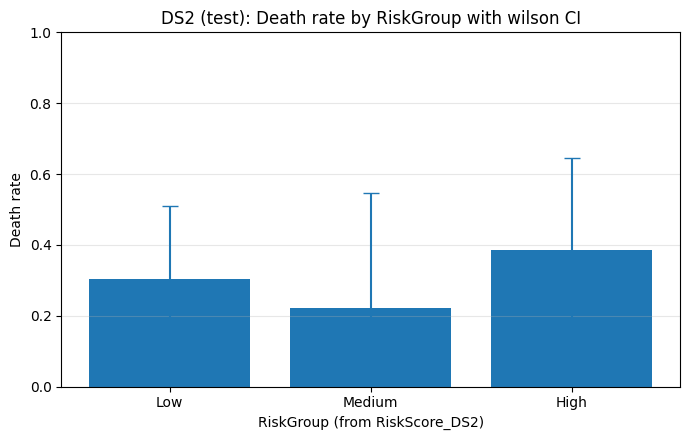


=== Monotonic check (simple) ===
death_rate Low/Medium/High: {'Low': 0.30434782608695654, 'Medium': 0.2222222222222222, 'High': 0.38461538461538464}
Monotonic (Low < Medium < High)? False

=== Cochran–Armitage trend test ===
Z = 0.41296153594760476  | p-value = 0.6796347949686674
Counts (group, n_i, deaths_i, score_i): [('Low', 23, 7, 1), ('Medium', 9, 2, 2), ('High', 13, 5, 3)]

=== Logistic trend (ordinal RiskGroup) ===
beta = 0.152166 | OR per 1-level increase = 1.1644
Wald z = 0.412 | p-value = 0.6800391476460361

=== Interpretation guide ===
- Barplot + CI: xem High có death rate cao hơn Low/Medium rõ ràng không, CI có chồng lấn nhiều không.
- Monotonic simple: Low < Medium < High (point estimates).
- Cochran–Armitage: p-value nhỏ (vd <0.05) => có xu hướng tăng theo bậc nhóm.
- Logistic ordinal: OR > 1 và p-value nhỏ => tăng 1 bậc nhóm làm odds tử vong tăng có ý nghĩa.


In [ ]:
# ============================================================
# RISK GROUP vs DEATH RATE (DS2)
#   - Barplot death rate by RiskGroup with CI (Wilson or Bootstrap)
#   - Monotonic trend checks:
#       (1) simple: Low < Medium < High
#       (2) Cochran–Armitage trend test (implemented here; no extra libs)
#       (3) Logistic regression with ordinal RiskGroup -> p-value trend
# ============================================================


# -----------------------------
# 0) INPUT ASSUMPTIONS
# -----------------------------

LABEL_DS2 = "DEATH_EVENT"
RISK_GROUP_COL = "RiskGroup_DS2"

# Choose evaluation subset: "test" 
EVAL_ON = "test"  

if EVAL_ON == "test":
    try:
        df_eval = df2.loc[X2_test.index].copy()
        print(f"[INFO] Evaluate on DS2 TEST only: n={len(df_eval)}")
    except Exception as e:
        print("[WARNING] Cannot slice by X2_test.index, fallback to FULL DS2. Error:", e)
        df_eval = df2.copy()
else:
    df_eval = df2.copy()
    print(f"[INFO] Evaluate on FULL DS2: n={len(df_eval)}")

# Ensure label is int 0/1
df_eval = df_eval.dropna(subset=[LABEL_DS2, RISK_GROUP_COL]).copy()
df_eval[LABEL_DS2] = df_eval[LABEL_DS2].astype(int)

# Ensure RiskGroup order: Low < Medium < High
group_order = ["Low", "Medium", "High"]
df_eval[RISK_GROUP_COL] = pd.Categorical(df_eval[RISK_GROUP_COL], categories=group_order, ordered=True)

# -----------------------------
# 1) CI helpers
# -----------------------------
def wilson_ci(k, n, alpha=0.05):
    """
    Wilson score interval for a proportion.
    Returns (p_hat, lower, upper).
    Uses normal approx z=1.96 (good default).
    """
    if n == 0:
        return (np.nan, np.nan, np.nan)

    # z for 95% CI
    # For alpha=0.05 => z=1.959963984540054
    z = 1.959963984540054
    p = k / n

    denom = 1 + (z**2) / n
    center = (p + (z**2) / (2*n)) / denom
    half = (z * np.sqrt((p*(1-p) + (z**2)/(4*n)) / n)) / denom
    return (p, max(0.0, center - half), min(1.0, center + half))

def bootstrap_ci_rate(y, n_boot=3000, alpha=0.05, rng_seed=42):
    """
    Bootstrap CI for mean(y) where y is 0/1.
    Returns (p_hat, lower, upper).
    """
    y = np.asarray(y, dtype=int)
    n = len(y)
    if n == 0:
        return (np.nan, np.nan, np.nan)

    rng = np.random.RandomState(rng_seed)
    p_hat = y.mean()

    boots = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.randint(0, n, size=n)
        boots[b] = y[idx].mean()

    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1 - alpha/2)
    return (p_hat, float(lo), float(hi))

# -----------------------------
# 2) Build summary table: death rate + CI by group
# -----------------------------
def make_group_summary(df, label_col, group_col, ci_method="wilson"):
    rows = []
    for g in group_order:
        sub = df[df[group_col] == g]
        n = len(sub)
        k = int(sub[label_col].sum())
        if ci_method == "wilson":
            p, lo, hi = wilson_ci(k, n)
        elif ci_method == "bootstrap":
            p, lo, hi = bootstrap_ci_rate(sub[label_col].values)
        else:
            raise ValueError("ci_method must be 'wilson' or 'bootstrap'")

        rows.append({
            "RiskGroup": g,
            "n": n,
            "deaths": k,
            "death_rate": p,
            "ci_low": lo,
            "ci_high": hi
        })
    out = pd.DataFrame(rows)
    return out

CI_METHOD = "wilson"  # "wilson" or "bootstrap"
summary = make_group_summary(df_eval, LABEL_DS2, RISK_GROUP_COL, ci_method=CI_METHOD)

print("\n=== Death rate by RiskGroup (with CI) ===")
display(summary)

# -----------------------------
# 3) Plot barplot with error bars (CI)
# -----------------------------
def plot_death_rate_ci(summary_df, title=None):
    x = np.arange(len(summary_df))
    y = summary_df["death_rate"].values
    yerr_low = y - summary_df["ci_low"].values
    yerr_high = summary_df["ci_high"].values - y
    yerr = np.vstack([yerr_low, yerr_high])

    plt.figure(figsize=(7, 4.5))
    plt.bar(x, y)
    plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=6)
    plt.xticks(x, summary_df["RiskGroup"].values)
    plt.ylim(0, 1)
    plt.ylabel("Death rate")
    plt.xlabel("RiskGroup (from RiskScore_DS2)")
    plt.title(title or f"DS2: Death rate by RiskGroup (CI={CI_METHOD})")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_death_rate_ci(summary, title=f"DS2 ({EVAL_ON}): Death rate by RiskGroup with {CI_METHOD} CI")

# -----------------------------
# 4) Monotonic trend checks
# -----------------------------

# 4.1 Simple check: Low < Medium < High (by point estimates)
rates = summary.set_index("RiskGroup")["death_rate"].to_dict()
mono_simple = (rates.get("Low", np.nan) < rates.get("Medium", np.nan) < rates.get("High", np.nan))
print("\n=== Monotonic check (simple) ===")
print("death_rate Low/Medium/High:", rates)
print("Monotonic (Low < Medium < High)?", mono_simple)

# 4.2 Cochran–Armitage trend test (for ordered groups)
def cochran_armitage_trend_test(df, group_col, label_col, scores=None):
    """
    Cochran–Armitage trend test for proportions across ordered groups.
    Returns dict with Z and two-sided p-value (normal approx).
    Requires ordered groups.
    """
    # group order -> scores (default 1,2,3)
    if scores is None:
        scores = {g: i+1 for i, g in enumerate(group_order)}

    # Build counts
    rows = []
    for g in group_order:
        sub = df[df[group_col] == g]
        n_i = len(sub)
        x_i = int(sub[label_col].sum())
        s_i = scores[g]
        rows.append((g, n_i, x_i, s_i))

    n = sum(r[1] for r in rows)
    x = sum(r[2] for r in rows)
    if n == 0:
        return {"Z": np.nan, "p_value": np.nan, "detail": rows}

    p_hat = x / n
    # Numerator: sum s_i * (x_i - n_i*p_hat)
    num = sum(s_i * (x_i - n_i * p_hat) for (_, n_i, x_i, s_i) in rows)

    # Denominator: sqrt( p_hat(1-p_hat) * sum n_i (s_i - sbar)^2 )
    sbar = sum(n_i * s_i for (_, n_i, x_i, s_i) in rows) / n
    den_inner = sum(n_i * (s_i - sbar)**2 for (_, n_i, x_i, s_i) in rows)
    den = np.sqrt(p_hat * (1 - p_hat) * den_inner)

    if den == 0:
        return {"Z": np.nan, "p_value": np.nan, "detail": rows}

    Z = num / den

    # two-sided p-value via normal approx (no scipy needed)
    # p = 2*(1 - Phi(|Z|))
    from math import erf, sqrt
    def norm_cdf(z):
        return 0.5 * (1.0 + erf(z / sqrt(2.0)))

    p_value = 2 * (1 - norm_cdf(abs(Z)))
    return {"Z": float(Z), "p_value": float(p_value), "detail": rows}

ca = cochran_armitage_trend_test(df_eval, RISK_GROUP_COL, LABEL_DS2)
print("\n=== Cochran–Armitage trend test ===")
print("Z =", ca["Z"], " | p-value =", ca["p_value"])
print("Counts (group, n_i, deaths_i, score_i):", ca["detail"])

# 4.3 Logistic regression with ordinal RiskGroup (1/2/3) -> p-value trend
# NOTE: sklearn doesn't output p-values; we use a Wald approx by estimating SE from Hessian.
def logistic_trend_wald_pvalue(df, group_col, label_col):
    """
    Fit logistic regression: y ~ ordinal(group)
    Return beta, OR, Wald z, p-value (normal approx).
    """
    # ordinal scores
    mapping = {"Low": 1, "Medium": 2, "High": 3}
    x = df[group_col].astype(str).map(mapping).astype(float).values.reshape(-1, 1)
    y = df[label_col].astype(int).values

    # Fit logistic regression (no regularization to approximate classical MLE)
    lr = LogisticRegression(penalty=None, solver="lbfgs", max_iter=2000)
    lr.fit(x, y)

    beta = float(lr.coef_[0][0])
    intercept = float(lr.intercept_[0])

    # Wald SE via observed information: X' W X
    # p_i = sigmoid(intercept + beta*x_i)
    eta = intercept + beta * x[:, 0]
    p = 1 / (1 + np.exp(-eta))
    w = p * (1 - p)

    # Design matrix includes intercept + slope
    X = np.column_stack([np.ones_like(x[:, 0]), x[:, 0]])
    # Fisher information approx
    # I = X' W X
    W = np.diag(w)
    I = X.T @ W @ X

    # Invert to get covariance
    try:
        cov = np.linalg.inv(I)
        se_beta = float(np.sqrt(cov[1, 1]))
    except np.linalg.LinAlgError:
        se_beta = np.nan

    if se_beta == 0 or np.isnan(se_beta):
        return {"beta": beta, "OR": float(np.exp(beta)), "z": np.nan, "p_value": np.nan}

    z = beta / se_beta

    # Normal p-value (two-sided)
    from math import erf, sqrt
    def norm_cdf(zv):
        return 0.5 * (1.0 + erf(zv / sqrt(2.0)))
    p_value = 2 * (1 - norm_cdf(abs(z)))

    return {"beta": float(beta), "OR": float(np.exp(beta)), "z": float(z), "p_value": float(p_value)}

wald = logistic_trend_wald_pvalue(df_eval, RISK_GROUP_COL, LABEL_DS2)
print("\n=== Logistic trend (ordinal RiskGroup) ===")
print(f"beta = {wald['beta']:.6f} | OR per 1-level increase = {wald['OR']:.4f}")
print(f"Wald z = {wald['z']:.3f} | p-value = {wald['p_value']}")

# -----------------------------
# 5) Optional: print a short interpretation helper
# -----------------------------
print("\n=== Interpretation guide ===")
print("- Barplot + CI: xem High có death rate cao hơn Low/Medium rõ ràng không, CI có chồng lấn nhiều không.")
print("- Monotonic simple: Low < Medium < High (point estimates).")
print("- Cochran–Armitage: p-value nhỏ (vd <0.05) => có xu hướng tăng theo bậc nhóm.")
print("- Logistic ordinal: OR > 1 và p-value nhỏ => tăng 1 bậc nhóm làm odds tử vong tăng có ý nghĩa.")
